# 30 — Model Cards, Compute, and Scalability

**Origin:** New Notebook; incorporates existing model-audit documentation\
**Refactor status:** Finished\
**Validation status:** Finished\
**Completion gate passed:** Yes\
**Output root:** `outputs/30_model_cards_compute_and_scalability/`\
**Depends on:** Notebooks 09–29 and model-audit sources

## Purpose

Create auditable method cards for every evaluated restoration method and analyze their observed compute, storage, failure, and scalability evidence without running restoration or metric inference.

The notebook documents:

- exact method and implementation identity;
- original purpose, licence, and available training-data information;
- input, mask, resolution, prompt, and compositing constraints;
- intended and unsupported uses;
- painting-domain gap, limitations, and bias risks;
- deterministic or stochastic behaviour;
- evaluated evidence coverage;
- observed runtime, throughput, memory, storage, failures, and retries;
- transparent 300-painting runtime and storage projections;
- scoped quality evidence from Notebook 21;
- reproducibility and human-decision-support boundaries.

## Evaluated model scope

The notebook creates four method cards:

| Model | Evaluation status | Executed scope |
|---|---|---|
| OpenCV Telea | Fully evaluated | 410 candidates across 50 paintings |
| LaMa | Fully evaluated | 410 candidates across 50 paintings |
| Stable Diffusion Inpainting | Fully evaluated | 1,330 candidates across 50 paintings |
| SDXL Inpainting | Partial evaluation | 10 candidates across 5 paintings |

SDXL remains a bounded partial evaluation. It is not promoted to the complete 410-case comparison.

## Quality-evidence contract

Quality evidence comes from Notebook 21’s eleven validated anchors.

Two populations remain separate:

- `core_three_model`: Telea, LaMa, and Stable Diffusion across 410 cases;
- `sdxl_four_model_subset`: all four methods across the bounded 10-case subset.

Anchor wins are descriptive counts across validated evidence views. They are not combined quality scores, conservation rankings, or universal model rankings.

Runtime is never included in the quality vote.

## Compute and projection contract

The notebook retains all 27 observed runtime-summary rows from Notebooks 09–12.

It adds eight projection rows covering two scenarios and four models:

1. `projected_300_canonical_primary`
   - 1,500 candidate outputs per method;
   - 1,200 model-inference candidates;
   - 300 identity zero controls.

2. `projected_300_current_design_mix`
   - 2,460 Telea candidates;
   - 2,460 LaMa candidates;
   - 7,980 Stable Diffusion candidates;
   - SDXL marked not applicable because no complete-design SDXL basis exists.

Median, mean, and p95 observed runtimes provide projection sensitivity values. They are not confidence intervals.

No 300-painting experiment was executed.

## Model-card contract

Each standalone Markdown card follows the approved thirteen-section structure:

1. at a glance;
2. identity and provenance;
3. intended and unsupported use;
4. training data and painting-domain gap;
5. project implementation;
6. evaluated evidence coverage;
7. compute and storage;
8. quality evidence;
9. determinism, robustness, and uncertainty;
10. scalability;
11. strengths and weaknesses;
12. human decision-support interpretation;
13. reproducibility and provenance.

The cards are text-native and portable. They contain no external image dependencies or base64 image payloads.

Notebook 31 owns the image-heavy model reports.

## Interpretation limits

- Observed runtime and memory describe the recorded workstation and software environment.
- Projections are transparent linear sensitivity estimates, not executed experiments.
- Projected storage excludes model caches, environments, Git history, and downstream metric outputs.
- No energy or carbon measurements were performed.
- Stable Diffusion uncertainty is empirical repeated-seed variability, not calibrated confidence.
- Telea and LaMa are deterministic and receive no artificial uncertainty values.
- SDXL has one seed per case and therefore receives no seed-based uncertainty estimate.
- No method card establishes historical authenticity, conservation suitability, or approval for physical treatment.

## Canonical outputs

- `data/model_cards.csv`
- `metrics/compute_scalability.csv`
- `reports/model_cards/opencv_telea.md`
- `reports/model_cards/lama.md`
- `reports/model_cards/stable_diffusion_inpainting.md`
- `reports/model_cards/sdxl_inpainting.md`
- `figures/quality_vs_compute.png`
- `figures/scaling_projection.png`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

## Batch 1 — Contract and preflight

This batch:

- locates the repository without assuming the notebook working directory;
- loads the approved Notebook 30 configuration and helper;
- declares all exact input and output paths;
- creates only Notebook 30-owned output directories;
- verifies the refreshed inventory and its zero-error state;
- verifies the roadmap, implementation guidelines, evidence audit, evidence coverage contract, literature log, and current model-audit notes;
- verifies completion manifests for Notebooks 09–29;
- verifies the exact candidate and runtime-table row counts;
- locks the four-model evaluation-status contract;
- locks the 27-observed-row and eight-projection-row arithmetic;
- locks the eleven quality anchors and the two separate evaluation populations;
- verifies that the four Markdown cards retain the approved thirteen-section structure;
- prohibits combined quality scores, fabricated SDXL coverage, executed-300 claims, universal runtime claims, calibrated-confidence claims, and conservation claims.

This batch does not build model-card rows, calculate projections, generate figures, write canonical outputs, or render the final Markdown cards.

In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display


def locate_project_root(start: Path) -> Path:
    """Locate the repository from either its root or notebooks directory."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "restoration_eval").is_dir()
            and (candidate / "config").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the painting-restoration-eval repository root."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from restoration_eval.model_cards_compute import (
    COMPUTE_COLUMNS,
    COMPUTE_SCHEMA_VERSION,
    CONFIG_SCHEMA_VERSION,
    MODEL_CARD_COLUMNS,
    MODEL_CARD_SCHEMA_VERSION,
    MODULE_NAME,
    MODULE_VERSION,
    atomic_write_csv,
    atomic_write_text,
    build_model_cards,
    build_scaling_projections,
    coerce_compute_scalability,
    collect_observed_compute,
    load_model_cards_compute_config,
    prepare_quality_evidence,
    render_model_card_markdown,
    resolve_model_cards_compute_inputs,
    summarize_output_storage,
    validate_compute_scalability,
    validate_model_card_markdown,
    validate_model_cards,
    validate_upstream_completion,
)
from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    environment_summary,
    git_state,
    package_versions,
    sha256_file,
    utc_now_iso,
    write_artifact_manifest,
    write_run_manifest,
)
from restoration_eval.validation import ValidationCollector

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 180)

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.22,
    }
)

RUN_STARTED_AT_UTC = utc_now_iso()
VALIDATION = ValidationCollector()


def reset_validation_stage(
    collector: ValidationCollector,
    stage: str,
) -> ValidationCollector:
    """Remove one validation stage so its cells can be rerun safely."""
    preserved = [
        check
        for check in collector.checks
        if check.validation_stage != stage
    ]
    refreshed = ValidationCollector()
    refreshed.extend(preserved)
    return refreshed


def add_check(
    *,
    stage: str,
    check_id: str,
    description: str,
    expected,
    observed,
    passed: bool,
    severity: str = "blocking",
    details="",
) -> None:
    """Register one JSON-safe validation check."""
    VALIDATION.add(
        validation_stage=stage,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


print("Notebook 30 environment initialized.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {platform.python_version()}")
print(f"Analysis helper: {MODULE_NAME} {MODULE_VERSION}")

Notebook 30 environment initialized.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Python: 3.12.6
Analysis helper: restoration_eval.model_cards_compute 1.0.0


In [2]:
BATCH_1_STAGE = "batch_1_preflight"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_1_STAGE,
)

CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "model_cards_compute.yaml"
)

ANALYSIS_CONFIG = load_model_cards_compute_config(
    CONFIG_PATH
)
SETTINGS = ANALYSIS_CONFIG["model_cards_compute"]

INPUT_PATHS = resolve_model_cards_compute_inputs(
    ANALYSIS_CONFIG,
    PROJECT_ROOT,
    must_exist=True,
)

OUTPUT_SPEC = SETTINGS["output"]
OUTPUT_ROOT = (
    PROJECT_ROOT
    / OUTPUT_SPEC["root"]
).resolve()

REPORT_ROOT = (
    OUTPUT_ROOT
    / OUTPUT_SPEC["model_card_reports_dir"]
)

MODEL_CARD_REPORT_PATHS = {
    model_id: REPORT_ROOT / f"{model_id}.md"
    for model_id in (
        "opencv_telea",
        "lama",
        "stable_diffusion_inpainting",
        "sdxl_inpainting",
    )
}

OUTPUT_PATHS = {
    "model_cards": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["model_cards_path"]
    ),
    "compute_scalability": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["compute_scalability_path"]
    ),
    "quality_vs_compute_figure": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["quality_vs_compute_figure_path"]
    ),
    "scaling_projection_figure": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["scaling_projection_figure_path"]
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["run_manifest_path"]
    ),
    "artifacts": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["artifacts_path"]
    ),
    "validation": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["validation_path"]
    ),
}

SMOKE_DIR = (
    OUTPUT_ROOT
    / OUTPUT_SPEC["smoke_dir"]
)

CANONICAL_FILE_PATHS = (
    OUTPUT_PATHS["model_cards"],
    OUTPUT_PATHS["compute_scalability"],
    *MODEL_CARD_REPORT_PATHS.values(),
    OUTPUT_PATHS["quality_vs_compute_figure"],
    OUTPUT_PATHS["scaling_projection_figure"],
    OUTPUT_PATHS["run_manifest"],
    OUTPUT_PATHS["artifacts"],
    OUTPUT_PATHS["validation"],
)

preexisting_output_files = (
    sorted(
        path
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    )
    if OUTPUT_ROOT.exists()
    else []
)

for output_path in CANONICAL_FILE_PATHS:
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

SMOKE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

paths_inside_output_root = all(
    path.resolve().is_relative_to(OUTPUT_ROOT)
    for path in CANONICAL_FILE_PATHS
)

configured_schema_versions = {
    "configuration": ANALYSIS_CONFIG[
        "config_schema_version"
    ],
    "model_cards": SETTINGS[
        "model_card_schema_version"
    ],
    "compute": SETTINGS[
        "compute_schema_version"
    ],
}

expected_schema_versions = {
    "configuration": CONFIG_SCHEMA_VERSION,
    "model_cards": MODEL_CARD_SCHEMA_VERSION,
    "compute": COMPUTE_SCHEMA_VERSION,
}

add_check(
    stage=BATCH_1_STAGE,
    check_id="supported_python_version",
    description="Python uses an approved major and minor version.",
    expected=["3.11", "3.12"],
    observed=(
        f"{sys.version_info.major}."
        f"{sys.version_info.minor}"
    ),
    passed=(
        sys.version_info.major,
        sys.version_info.minor,
    ) in {(3, 11), (3, 12)},
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="configuration_and_schema_versions",
    description=(
        "Configuration and canonical schemas match "
        "the Notebook 30 helper."
    ),
    expected=expected_schema_versions,
    observed=configured_schema_versions,
    passed=(
        configured_schema_versions
        == expected_schema_versions
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="all_declared_inputs_exist",
    description=(
        "Every explicitly declared Notebook 30 input exists."
    ),
    expected=len(SETTINGS["inputs"]),
    observed=sum(
        path.exists()
        for path in INPUT_PATHS.values()
    ),
    passed=all(
        path.exists()
        for path in INPUT_PATHS.values()
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="output_root_is_notebook_owned",
    description=(
        "Every canonical output belongs to the exact "
        "Notebook 30 output root."
    ),
    expected=True,
    observed=paths_inside_output_root,
    passed=paths_inside_output_root,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="canonical_physical_file_count",
    description=(
        "The contract contains exactly eleven physical "
        "canonical output files."
    ),
    expected=11,
    observed=len(CANONICAL_FILE_PATHS),
    passed=(
        len(CANONICAL_FILE_PATHS)
        == SETTINGS["expected_counts"][
            "canonical_file_count"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="fresh_output_root",
    description=(
        "Notebook 30 starts without pre-existing output files."
    ),
    expected=0,
    observed=len(preexisting_output_files),
    passed=not preexisting_output_files,
)

output_contract = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "relative_path": (
                output_path
                .relative_to(PROJECT_ROOT)
                .as_posix()
            ),
            "exists_after_setup": output_path.exists(),
        }
        for artifact_name, output_path in (
            list(OUTPUT_PATHS.items())
            + [
                (
                    f"model_card_{model_id}",
                    report_path,
                )
                for model_id, report_path
                in MODEL_CARD_REPORT_PATHS.items()
            ]
        )
    ]
)

display(output_contract)

print("Configuration and output contract validated.")
print(f"Declared inputs: {len(INPUT_PATHS):,}")
print(
    "Canonical physical files: "
    f"{len(CANONICAL_FILE_PATHS):,}"
)
print(f"Output root: {OUTPUT_ROOT}")

,artifact,relative_path,exists_after_setup
0,model_cards,outputs/30_model_cards_compute_and_scalability/data/model_cards.csv,False
1,compute_scalability,outputs/30_model_cards_compute_and_scalability/metrics/compute_scalability.csv,False
2,quality_vs_compute_figure,outputs/30_model_cards_compute_and_scalability/figures/quality_vs_compute.png,False
3,scaling_projection_figure,outputs/30_model_cards_compute_and_scalability/figures/scaling_projection.png,False
4,run_manifest,outputs/30_model_cards_compute_and_scalability/manifests/run_manifest.json,False
5,artifacts,outputs/30_model_cards_compute_and_scalability/manifests/artifacts.csv,False
6,validation,outputs/30_model_cards_compute_and_scalability/validation/checks.csv,False
7,model_card_opencv_telea,outputs/30_model_cards_compute_and_scalability/reports/model_cards/opencv_telea.md,False
8,model_card_lama,outputs/30_model_cards_compute_and_scalability/reports/model_cards/lama.md,False
9,model_card_stable_diffusion_inpainting,outputs/30_model_cards_compute_and_scalability/reports/model_cards/stable_diffusion_inpainting.md,False


Configuration and output contract validated.
Declared inputs: 45
Canonical physical files: 11
Output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\30_model_cards_compute_and_scalability


In [3]:
with INPUT_PATHS["inventory_run_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    INVENTORY_RUN = json.load(handle)

INVENTORY = pd.read_csv(
    INPUT_PATHS["inventory_path"],
    low_memory=False,
)

with INPUT_PATHS["project_paths_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    PROJECT_PATHS_REGISTRY = json.load(handle)

with INPUT_PATHS["evidence_coverage_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    EVIDENCE_COVERAGE = yaml.safe_load(handle)

ROADMAP_TEXT = INPUT_PATHS[
    "notebook_roadmap_path"
].read_text(encoding="utf-8-sig")

IMPLEMENTATION_GUIDELINES_TEXT = INPUT_PATHS[
    "implementation_guidelines_path"
].read_text(encoding="utf-8-sig")

EVIDENCE_AUDIT_TEXT = INPUT_PATHS[
    "evidence_dependency_audit_path"
].read_text(encoding="utf-8-sig")

MODEL_AUDIT_TEXT = INPUT_PATHS[
    "model_audit_notes_path"
].read_text(encoding="utf-8-sig")

LITERATURE_LOG_TEXT = (
    PROJECT_ROOT
    / "docs"
    / "literature_reference_log.md"
).read_text(encoding="utf-8-sig")

inventory_relative_paths = set(
    INVENTORY["relative_path"]
    .fillna("")
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

required_preparation_paths = {
    "config/evaluation/model_cards_compute.yaml",
    "src/restoration_eval/model_cards_compute.py",
    "tests/test_model_cards_compute.py",
    "notebooks/30_model_cards_compute_and_scalability.ipynb",
    "docs/final_notebook_roadmap.md",
    "docs/refactoring_implementation_guidelines.md",
    "docs/evidence_dependency_audit.md",
    "docs/model_audit_notes.md",
    "docs/literature_reference_log.md",
    "config/evaluation/evidence_coverage.yaml",
}

coverage_root = EVIDENCE_COVERAGE.get(
    "evidence_coverage",
    EVIDENCE_COVERAGE,
)

planned_notebooks = {
    str(record["notebook_id"]): record
    for record in coverage_root.get(
        "planned_notebooks",
        [],
    )
}

N30_COVERAGE = planned_notebooks.get(
    "30",
    {},
)

MANIFESTS = {}

for notebook_number in range(9, 30):
    notebook_id = f"{notebook_number:02d}"
    manifest_key = (
        f"manifest_{notebook_id}_path"
    )

    with INPUT_PATHS[manifest_key].open(
        "r",
        encoding="utf-8-sig",
    ) as handle:
        MANIFESTS[notebook_id] = json.load(handle)

UPSTREAM_COMPLETION = validate_upstream_completion(
    MANIFESTS
)

STORAGE_SUMMARY = summarize_output_storage(
    INVENTORY,
    config=ANALYSIS_CONFIG,
)

inventory_status_ok = (
    INVENTORY_RUN.get("status") == "completed"
    and int(
        INVENTORY_RUN.get(
            "summary",
            {},
        ).get(
            "read_error_count",
            -1,
        )
    )
    == 0
)

missing_preparation_paths = sorted(
    required_preparation_paths
    - inventory_relative_paths
)

manual_notebook_policy_present = (
    "The assistant must not create, replace, patch, "
    "or otherwise edit an `.ipynb`"
    in IMPLEMENTATION_GUIDELINES_TEXT
)

roadmap_contract_present = (
    "## 30 — Model Cards, Compute, and Scalability"
    in ROADMAP_TEXT
    and "data/model_cards.csv" in ROADMAP_TEXT
    and "metrics/compute_scalability.csv" in ROADMAP_TEXT
    and "reports/model_cards/<model_id>.md"
    in ROADMAP_TEXT
)

evidence_gate_present = (
    "| 30 Model cards/compute |"
    in EVIDENCE_AUDIT_TEXT
    and (
        "projections, not executed results"
        in EVIDENCE_AUDIT_TEXT
    )
)

normalized_model_audit_text = " ".join(
    MODEL_AUDIT_TEXT.casefold().split()
)

current_model_audit_present = all(
    required_text
    in normalized_model_audit_text
    for required_text in (
        "1,330 persisted candidates",
        "retain sdxl as `partial_evaluation`",
        "no 300-painting experiment was executed",
    )
)

literature_contract_present = (
    "## 30. Model Cards, Compute, and Scalability"
    in LITERATURE_LOG_TEXT
    and (
        "35 rows in `metrics/compute_scalability.csv`"
        in LITERATURE_LOG_TEXT
    )
)

coverage_contract_present = (
    N30_COVERAGE.get("stem")
    == "30_model_cards_compute_and_scalability"
    and N30_COVERAGE.get(
        "expected_counts",
        {},
    ).get("model_cards")
    == 4
    and N30_COVERAGE.get(
        "expected_counts",
        {},
    ).get("compute_rows")
    == 35
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="inventory_run_completed",
    description=(
        "The refreshed inventory completed without read errors."
    ),
    expected={
        "status": "completed",
        "read_error_count": 0,
    },
    observed={
        "status": INVENTORY_RUN.get("status"),
        "read_error_count": (
            INVENTORY_RUN.get(
                "summary",
                {},
            ).get("read_error_count")
        ),
        "inventory_run_id": (
            INVENTORY_RUN.get("inventory_run_id")
        ),
    },
    passed=inventory_status_ok,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="preparation_files_in_inventory",
    description=(
        "The refreshed inventory contains the complete "
        "Notebook 30 preparation layer."
    ),
    expected=sorted(required_preparation_paths),
    observed=sorted(
        required_preparation_paths
        & inventory_relative_paths
    ),
    passed=not missing_preparation_paths,
    details={
        "missing": missing_preparation_paths,
    },
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="governing_documents_reference_n30",
    description=(
        "The governing documents retain the approved "
        "Notebook 30 responsibility and manual-editing policy."
    ),
    expected=True,
    observed={
        "manual_notebook_policy": (
            manual_notebook_policy_present
        ),
        "roadmap_contract": roadmap_contract_present,
        "evidence_gate": evidence_gate_present,
        "model_audit_current": (
            current_model_audit_present
        ),
        "literature_contract": (
            literature_contract_present
        ),
        "machine_readable_coverage": (
            coverage_contract_present
        ),
    },
    passed=all(
        (
            manual_notebook_policy_present,
            roadmap_contract_present,
            evidence_gate_present,
            current_model_audit_present,
            literature_contract_present,
            coverage_contract_present,
        )
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="project_paths_registry_schema",
    description=(
        "The project-path registry uses the approved schema."
    ),
    expected="project_paths.v1",
    observed=PROJECT_PATHS_REGISTRY.get(
        "registry_schema_version"
    ),
    passed=(
        PROJECT_PATHS_REGISTRY.get(
            "registry_schema_version"
        )
        == "project_paths.v1"
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="upstream_notebooks_complete",
    description=(
        "Every required Notebook 09–29 manifest "
        "is complete and has passed its completion gate."
    ),
    expected=21,
    observed=int(
        UPSTREAM_COMPLETION["passed"].sum()
    ),
    passed=(
        len(UPSTREAM_COMPLETION) == 21
        and UPSTREAM_COMPLETION["passed"].all()
    ),
    details={
        "failed_notebooks": (
            UPSTREAM_COMPLETION.loc[
                ~UPSTREAM_COMPLETION["passed"],
                "notebook_id",
            ].tolist()
        )
    },
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="model_output_storage_available",
    description=(
        "Inventory contains positive model-owned storage "
        "with no read errors for all four model producers."
    ),
    expected={
        "models": 4,
        "positive_storage": True,
        "read_errors": 0,
    },
    observed={
        "models": len(STORAGE_SUMMARY),
        "positive_storage": bool(
            STORAGE_SUMMARY[
                "output_storage_bytes"
            ].gt(0).all()
        ),
        "read_errors": int(
            STORAGE_SUMMARY[
                "read_error_count"
            ].sum()
        ),
    },
    passed=(
        len(STORAGE_SUMMARY) == 4
        and STORAGE_SUMMARY[
            "output_storage_bytes"
        ].gt(0).all()
        and STORAGE_SUMMARY[
            "read_error_count"
        ].eq(0).all()
    ),
)

display(UPSTREAM_COMPLETION)
display(STORAGE_SUMMARY)

print("Inventory and governing documents validated.")
print(
    "Completed upstream manifests: "
    f"{int(UPSTREAM_COMPLETION['passed'].sum()):,}/"
    f"{len(UPSTREAM_COMPLETION):,}"
)
print(
    "Inventory read errors: "
    f"{INVENTORY_RUN['summary']['read_error_count']:,}"
)

,notebook_id,manifest_present,run_status,completion_gate_passed,passed,details
0,09,True,completed,True,True,run=completed; gate=True
1,10,True,completed,True,True,run=completed; gate=True
2,11,True,completed,True,True,run=completed; gate=True
3,12,True,completed,True,True,run=completed; gate=True
4,13,True,completed,True,True,run=completed; gate=True
5,14,True,completed,True,True,run=completed; gate=True
6,15,True,completed,True,True,run=completed; gate=True
7,16,True,completed,True,True,run=completed; gate=True
8,17,True,completed,True,True,run=completed; gate=True
9,18,True,completed,True,True,run=completed; gate=True


,model_id,output_root,output_file_count,output_storage_bytes,restored_image_file_count,restored_image_storage_bytes,fixed_file_count,fixed_storage_bytes,read_error_count
0,opencv_telea,outputs/09_opencv_telea_restoration,416,301454384,410,294606024,6,6848360,0
1,lama,outputs/10_lama_restoration,416,298514114,410,291403474,6,7110640,0
2,stable_diffusion_inpainting,outputs/11_stable_diffusion_restoration,1340,970930007,1330,952159010,10,18770997,0
3,sdxl_inpainting,outputs/12_sdxl_feasibility_or_restoration,16,7195725,10,7091251,6,104474,0


Inventory and governing documents validated.
Completed upstream manifests: 21/21
Inventory read errors: 0


In [4]:
def csv_row_count(path: Path) -> int:
    """Count CSV rows without retaining the complete table."""
    return int(
        sum(
            len(chunk)
            for chunk in pd.read_csv(
                path,
                usecols=[0],
                chunksize=50_000,
            )
        )
    )


EXPECTED = SETTINGS["expected_counts"]
QUALITY_POLICY = SETTINGS["quality"]
PROJECTION_POLICY = SETTINGS["projections"]
REPORT_POLICY = SETTINGS["report"]
EVIDENCE_POLICY = SETTINGS["evidence_policy"]

input_count_contract = pd.DataFrame(
    [
        {
            "input": "Telea candidates",
            "observed_rows": csv_row_count(
                INPUT_PATHS["telea_candidates_path"]
            ),
            "expected_rows": EXPECTED[
                "telea_candidate_rows"
            ],
        },
        {
            "input": "LaMa candidates",
            "observed_rows": csv_row_count(
                INPUT_PATHS["lama_candidates_path"]
            ),
            "expected_rows": EXPECTED[
                "lama_candidate_rows"
            ],
        },
        {
            "input": "Stable Diffusion candidates",
            "observed_rows": csv_row_count(
                INPUT_PATHS[
                    "stable_diffusion_candidates_path"
                ]
            ),
            "expected_rows": EXPECTED[
                "stable_diffusion_candidate_rows"
            ],
        },
        {
            "input": "SDXL candidates",
            "observed_rows": csv_row_count(
                INPUT_PATHS["sdxl_candidates_path"]
            ),
            "expected_rows": EXPECTED[
                "sdxl_candidate_rows"
            ],
        },
        {
            "input": "Telea runtime summaries",
            "observed_rows": csv_row_count(
                INPUT_PATHS["telea_runtime_path"]
            ),
            "expected_rows": EXPECTED[
                "telea_runtime_rows"
            ],
        },
        {
            "input": "LaMa runtime summaries",
            "observed_rows": csv_row_count(
                INPUT_PATHS["lama_runtime_path"]
            ),
            "expected_rows": EXPECTED[
                "lama_runtime_rows"
            ],
        },
        {
            "input": "Stable Diffusion runtime summaries",
            "observed_rows": csv_row_count(
                INPUT_PATHS[
                    "stable_diffusion_runtime_path"
                ]
            ),
            "expected_rows": EXPECTED[
                "stable_diffusion_runtime_rows"
            ],
        },
        {
            "input": "SDXL runtime summaries",
            "observed_rows": csv_row_count(
                INPUT_PATHS["sdxl_runtime_path"]
            ),
            "expected_rows": EXPECTED[
                "sdxl_runtime_rows"
            ],
        },
    ]
)

input_count_contract["passed"] = (
    input_count_contract["observed_rows"]
    == input_count_contract["expected_rows"]
)

MODEL_SPECS = {
    model["model_id"]: model
    for model in SETTINGS["models"]
}

expected_model_statuses = {
    "opencv_telea": "fully_evaluated",
    "lama": "fully_evaluated",
    "stable_diffusion_inpainting": (
        "fully_evaluated"
    ),
    "sdxl_inpainting": "partial_evaluation",
}

observed_model_statuses = {
    model_id: model["evaluation_status"]
    for model_id, model in MODEL_SPECS.items()
}

SCENARIOS = {
    scenario["scenario_id"]: scenario
    for scenario in PROJECTION_POLICY["scenarios"]
}

canonical_projection = SCENARIOS[
    "projected_300_canonical_primary"
]

current_design_projection = SCENARIOS[
    "projected_300_current_design_mix"
]

canonical_projection_arithmetic_ok = all(
    canonical_projection[
        "target_candidates"
    ][model_id]
    == 1500
    and canonical_projection[
        "target_inference_candidates"
    ][model_id]
    + canonical_projection[
        "target_zero_controls"
    ][model_id]
    == 1500
    for model_id in MODEL_SPECS
)

current_design_targets = (
    current_design_projection[
        "target_candidates"
    ]
)

current_design_arithmetic_ok = (
    current_design_targets["opencv_telea"]
    == 2460
    and current_design_targets["lama"]
    == 2460
    and current_design_targets[
        "stable_diffusion_inpainting"
    ]
    == 7980
    and current_design_targets[
        "sdxl_inpainting"
    ]
    is None
)

quality_population_contract = {
    population_id: {
        "models": population["model_ids"],
        "cases": population["case_count"],
        "paintings": population[
            "painting_count"
        ],
    }
    for population_id, population
    in QUALITY_POLICY["populations"].items()
}

prohibited_true = {
    key: bool(value)
    for key, value
    in EVIDENCE_POLICY.items()
    if bool(value)
}

source_urls = [
    source["url"]
    for source
    in SETTINGS["sources"]["records"]
]

add_check(
    stage=BATCH_1_STAGE,
    check_id="candidate_and_runtime_row_counts",
    description=(
        "Every candidate and runtime input matches "
        "the exact approved population count."
    ),
    expected=True,
    observed=input_count_contract[
        [
            "input",
            "observed_rows",
            "expected_rows",
            "passed",
        ]
    ].to_dict("records"),
    passed=input_count_contract["passed"].all(),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="model_status_contract",
    description=(
        "Three methods remain fully evaluated and "
        "SDXL remains a bounded partial evaluation."
    ),
    expected=expected_model_statuses,
    observed=observed_model_statuses,
    passed=(
        observed_model_statuses
        == expected_model_statuses
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="compute_row_arithmetic",
    description=(
        "Twenty-seven observed rows and eight "
        "projection rows produce thirty-five rows."
    ),
    expected={
        "observed": 27,
        "projected": 8,
        "total": 35,
    },
    observed={
        "observed": EXPECTED[
            "observed_compute_rows"
        ],
        "projected": EXPECTED[
            "projection_rows"
        ],
        "total": EXPECTED[
            "compute_rows"
        ],
    },
    passed=(
        EXPECTED["observed_compute_rows"] == 27
        and EXPECTED["projection_rows"] == 8
        and EXPECTED["compute_rows"] == 35
        and EXPECTED["compute_rows"]
        == (
            EXPECTED["observed_compute_rows"]
            + EXPECTED["projection_rows"]
        )
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="canonical_projection_arithmetic",
    description=(
        "Every canonical 300-painting scenario has "
        "1,200 inference cases and 300 zero controls."
    ),
    expected={
        "candidate_outputs_per_model": 1500,
        "inference_candidates_per_model": 1200,
        "zero_controls_per_model": 300,
    },
    observed={
        "targets": canonical_projection[
            "target_candidates"
        ],
        "inference": canonical_projection[
            "target_inference_candidates"
        ],
        "zero_controls": canonical_projection[
            "target_zero_controls"
        ],
    },
    passed=canonical_projection_arithmetic_ok,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="current_design_projection_arithmetic",
    description=(
        "The complete current design is scaled by six "
        "without fabricating a full SDXL design."
    ),
    expected={
        "opencv_telea": 2460,
        "lama": 2460,
        "stable_diffusion_inpainting": 7980,
        "sdxl_inpainting": None,
    },
    observed=current_design_targets,
    passed=current_design_arithmetic_ok,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="quality_anchor_and_population_contract",
    description=(
        "Eleven validated anchors remain separated "
        "across the core and bounded populations."
    ),
    expected={
        "anchors": 11,
        "populations": 2,
        "quality_anchor_rows": 22,
    },
    observed={
        "anchors": len(
            QUALITY_POLICY["anchors"]
        ),
        "populations": len(
            QUALITY_POLICY["populations"]
        ),
        "quality_anchor_rows": EXPECTED[
            "quality_anchor_rows"
        ],
        "population_contract": (
            quality_population_contract
        ),
    },
    passed=(
        len(QUALITY_POLICY["anchors"]) == 11
        and len(
            QUALITY_POLICY["populations"]
        )
        == 2
        and EXPECTED[
            "quality_anchor_rows"
        ]
        == 22
        and not QUALITY_POLICY[
            "combined_quality_score_retained"
        ]
        and not QUALITY_POLICY[
            "runtime_in_quality_vote"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="model_card_report_contract",
    description=(
        "Four portable Markdown cards retain the "
        "approved thirteen-section structure."
    ),
    expected={
        "reports": 4,
        "sections": 13,
        "external_images": 0,
    },
    observed={
        "reports": len(
            MODEL_CARD_REPORT_PATHS
        ),
        "sections": len(
            REPORT_POLICY[
                "required_section_ids"
            ]
        ),
        "external_images": (
            REPORT_POLICY[
                "required_external_image_dependencies"
            ]
        ),
        "text_native": (
            REPORT_POLICY[
                "self_contained_text"
            ]
        ),
        "mock_structure_locked": (
            REPORT_POLICY[
                "approved_mock_structure_locked"
            ]
        ),
    },
    passed=(
        len(MODEL_CARD_REPORT_PATHS) == 4
        and len(
            REPORT_POLICY[
                "required_section_ids"
            ]
        )
        == 13
        and REPORT_POLICY[
            "required_external_image_dependencies"
        ]
        == 0
        and REPORT_POLICY[
            "self_contained_text"
        ]
        and REPORT_POLICY[
            "approved_mock_structure_locked"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="primary_source_contract",
    description=(
        "All declared provenance sources use "
        "explicit web URLs."
    ),
    expected=True,
    observed=source_urls,
    passed=(
        len(source_urls) >= 9
        and all(
            url.startswith("https://")
            for url in source_urls
        )
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="interpretation_protections",
    description=(
        "Every prohibited Notebook 30 "
        "interpretation remains disabled."
    ),
    expected={},
    observed=prohibited_true,
    passed=not prohibited_true,
)

display(input_count_contract)

projection_contract = pd.DataFrame(
    [
        {
            "scenario_id": scenario_id,
            "model_id": model_id,
            "target_candidates": scenario[
                "target_candidates"
            ][model_id],
            "target_inference_candidates": scenario[
                "target_inference_candidates"
            ][model_id],
            "target_zero_controls": scenario[
                "target_zero_controls"
            ][model_id],
            "executed": False,
        }
        for scenario_id, scenario
        in SCENARIOS.items()
        for model_id in MODEL_SPECS
    ]
)

display(projection_contract)

BATCH_1_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_1_ROWS = (
    BATCH_1_VALIDATION.loc[
        BATCH_1_VALIDATION[
            "validation_stage"
        ].eq(BATCH_1_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_1_ROWS)

blocking_failures = int(
    (
        BATCH_1_ROWS["severity"].eq("blocking")
        & ~BATCH_1_ROWS["passed"]
    ).sum()
)

print("Batch 1 contract and preflight complete.")
print(
    "Validation checks: "
    f"{len(BATCH_1_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Candidate rows verified: "
    f"{input_count_contract.loc[:3, 'observed_rows'].sum():,}"
)
print(
    "Observed plus projected compute rows: "
    f"{EXPECTED['compute_rows']:,}"
)
print(
    "Standalone model cards planned: "
    f"{len(MODEL_CARD_REPORT_PATHS):,}"
)

VALIDATION.raise_for_blocking()

,input,observed_rows,expected_rows,passed
0,Telea candidates,410,410,True
1,LaMa candidates,410,410,True
2,Stable Diffusion candidates,1330,1330,True
3,SDXL candidates,10,10,True
4,Telea runtime summaries,5,5,True
5,LaMa runtime summaries,5,5,True
6,Stable Diffusion runtime summaries,14,14,True
7,SDXL runtime summaries,3,3,True


,scenario_id,model_id,target_candidates,target_inference_candidates,target_zero_controls,executed
0,projected_300_canonical_primary,opencv_telea,1500.0,1200.0,300.0,False
1,projected_300_canonical_primary,lama,1500.0,1200.0,300.0,False
2,projected_300_canonical_primary,stable_diffusion_inpainting,1500.0,1200.0,300.0,False
3,projected_300_canonical_primary,sdxl_inpainting,1500.0,1200.0,300.0,False
4,projected_300_current_design_mix,opencv_telea,2460.0,2160.0,300.0,False
5,projected_300_current_design_mix,lama,2460.0,2160.0,300.0,False
6,projected_300_current_design_mix,stable_diffusion_inpainting,7980.0,7680.0,300.0,False
7,projected_300_current_design_mix,sdxl_inpainting,NaN,NaN,NaN,False


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,supported_python_version,Python uses an approved major and minor version.,blocking,"[""3.11"", ""3.12""]",3.12,True,
1,batch_1_preflight,configuration_and_schema_versions,Configuration and canonical schemas match the Notebook 30 helper.,blocking,"{""compute"": ""compute_scalability.v1"", ""configuration"": ""model_cards_compute_config.v1"", ""model_cards"": ""model_cards.v1""}","{""compute"": ""compute_scalability.v1"", ""configuration"": ""model_cards_compute_config.v1"", ""model_cards"": ""model_cards.v1""}",True,
2,batch_1_preflight,all_declared_inputs_exist,Every explicitly declared Notebook 30 input exists.,blocking,45,45,True,
3,batch_1_preflight,output_root_is_notebook_owned,Every canonical output belongs to the exact Notebook 30 output root.,blocking,True,True,True,
4,batch_1_preflight,canonical_physical_file_count,The contract contains exactly eleven physical canonical output files.,blocking,11,11,True,
5,batch_1_preflight,fresh_output_root,Notebook 30 starts without pre-existing output files.,blocking,0,0,True,
6,batch_1_preflight,inventory_run_completed,The refreshed inventory completed without read errors.,blocking,"{""read_error_count"": 0, ""status"": ""completed""}","{""inventory_run_id"": ""inventory_20260902T120343Z_a44d7fe6"", ""read_error_count"": 0, ""status"": ""completed""}",True,
7,batch_1_preflight,preparation_files_in_inventory,The refreshed inventory contains the complete Notebook 30 preparation layer.,blocking,"[""config/evaluation/evidence_coverage.yaml"", ""config/evaluation/model_cards_compute.yaml"", ""docs/evidence_dependency_audit.md"", ""docs/final_notebook_roadmap.md"", ""docs/literatu...","[""config/evaluation/evidence_coverage.yaml"", ""config/evaluation/model_cards_compute.yaml"", ""docs/evidence_dependency_audit.md"", ""docs/final_notebook_roadmap.md"", ""docs/literatu...",True,"{""missing"": []}"
8,batch_1_preflight,governing_documents_reference_n30,The governing documents retain the approved Notebook 30 responsibility and manual-editing policy.,blocking,True,"{""evidence_gate"": true, ""literature_contract"": true, ""machine_readable_coverage"": true, ""manual_notebook_policy"": true, ""model_audit_current"": true, ""roadmap_contract"": true}",True,
9,batch_1_preflight,project_paths_registry_schema,The project-path registry uses the approved schema.,blocking,project_paths.v1,project_paths.v1,True,


Batch 1 contract and preflight complete.
Validation checks: 21
Blocking failures: 0
Candidate rows verified: 2,160
Observed plus projected compute rows: 35
Standalone model cards planned: 4


## Batch 2 — Input loading and evidence normalization

This batch:

- loads the complete Telea, LaMa, Stable Diffusion, and SDXL candidate tables;
- loads all 27 upstream runtime-summary rows;
- normalizes the 2,160 executed candidates into one in-memory registry;
- derives painting identity consistently for legacy and current candidate schemas;
- preserves each model’s complete source table for later model-card construction;
- loads Notebook 21 model-comparison and metric-disagreement evidence;
- selects the eleven validated quality anchors for both approved populations;
- constructs descriptive anchor-win summaries without creating a combined score;
- verifies candidate identity, completion status, painting coverage, runtime coverage, and finite runtime values;
- verifies complete input, mask, hardware, source, and evaluation-status disclosures for all four cards.

This batch does not build the final model-card table, calculate scalability projections, generate figures, write canonical outputs, or render Markdown reports.

In [5]:
BATCH_2_STAGE = "batch_2_input_loading"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_2_STAGE,
)

CANDIDATE_TABLES = {
    "opencv_telea": pd.read_csv(
        INPUT_PATHS["telea_candidates_path"],
        low_memory=False,
    ),
    "lama": pd.read_csv(
        INPUT_PATHS["lama_candidates_path"],
        low_memory=False,
    ),
    "stable_diffusion_inpainting": pd.read_csv(
        INPUT_PATHS[
            "stable_diffusion_candidates_path"
        ],
        low_memory=False,
    ),
    "sdxl_inpainting": pd.read_csv(
        INPUT_PATHS["sdxl_candidates_path"],
        low_memory=False,
    ),
}

RUNTIME_TABLES = {
    "opencv_telea": pd.read_csv(
        INPUT_PATHS["telea_runtime_path"]
    ),
    "lama": pd.read_csv(
        INPUT_PATHS["lama_runtime_path"]
    ),
    "stable_diffusion_inpainting": pd.read_csv(
        INPUT_PATHS[
            "stable_diffusion_runtime_path"
        ]
    ),
    "sdxl_inpainting": pd.read_csv(
        INPUT_PATHS["sdxl_runtime_path"]
    ),
}

candidate_registry_parts = []

for model_id, source_table in CANDIDATE_TABLES.items():
    required_columns = {
        "candidate_id",
        "case_id",
        "status",
        "runtime_seconds",
    }

    missing_columns = sorted(
        required_columns
        - set(source_table.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{model_id} candidate input is missing "
            f"columns: {missing_columns}"
        )

    normalized = source_table[
        [
            "candidate_id",
            "case_id",
            "status",
            "runtime_seconds",
        ]
    ].copy()

    normalized.insert(
        0,
        "model_id",
        model_id,
    )

    normalized["source_row_index"] = (
        np.arange(
            len(normalized),
            dtype=np.int64,
        )
    )

    normalized["painting_id"] = (
        normalized["case_id"]
        .fillna("")
        .astype(str)
        .str.extract(
            r"(p\d{3})",
            expand=False,
        )
    )

    normalized["runtime_seconds"] = (
        pd.to_numeric(
            normalized["runtime_seconds"],
            errors="coerce",
        )
    )

    candidate_registry_parts.append(
        normalized
    )

CANDIDATE_REGISTRY = pd.concat(
    candidate_registry_parts,
    ignore_index=True,
)

runtime_registry_parts = []

for model_id, source_table in RUNTIME_TABLES.items():
    required_columns = {
        "summary_scope",
        "experiment_id",
        "case_count",
        "completed_count",
        "failed_count",
        "total_runtime_seconds",
        "mean_runtime_seconds",
        "median_runtime_seconds",
        "p95_runtime_seconds",
        "max_runtime_seconds",
        "throughput_cases_per_second",
        "status",
    }

    missing_columns = sorted(
        required_columns
        - set(source_table.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{model_id} runtime input is missing "
            f"columns: {missing_columns}"
        )

    normalized = source_table.copy()
    normalized.insert(
        0,
        "model_id",
        model_id,
    )

    runtime_registry_parts.append(
        normalized
    )

RUNTIME_REGISTRY = pd.concat(
    runtime_registry_parts,
    ignore_index=True,
)

print("Candidate and runtime inputs loaded.")
print(
    "Normalized candidate rows: "
    f"{len(CANDIDATE_REGISTRY):,}"
)
print(
    "Normalized runtime rows: "
    f"{len(RUNTIME_REGISTRY):,}"
)
print(
    "Models represented: "
    f"{CANDIDATE_REGISTRY['model_id'].nunique():,}"
)

Candidate and runtime inputs loaded.
Normalized candidate rows: 2,160
Normalized runtime rows: 27
Models represented: 4


In [6]:
MODEL_COMPARISON_SOURCE = pd.read_csv(
    INPUT_PATHS["model_comparison_path"],
    low_memory=False,
)

METRIC_DISAGREEMENT_SOURCE = pd.read_csv(
    INPUT_PATHS["metric_disagreement_path"],
    low_memory=False,
)

QUALITY_VALUES, QUALITY_WIN_SUMMARY = (
    prepare_quality_evidence(
        MODEL_COMPARISON_SOURCE,
        METRIC_DISAGREEMENT_SOURCE,
        config=ANALYSIS_CONFIG,
    )
)

expected_quality_value_rows = int(
    sum(
        len(population["model_ids"])
        * QUALITY_POLICY["anchor_count"]
        for population
        in QUALITY_POLICY[
            "populations"
        ].values()
    )
)

expected_quality_win_rows = int(
    sum(
        len(population["model_ids"])
        for population
        in QUALITY_POLICY[
            "populations"
        ].values()
    )
)

quality_population_summary = (
    QUALITY_VALUES.groupby(
        [
            "population_id",
            "model_id",
        ],
        dropna=False,
    )
    .agg(
        anchor_rows=(
            "anchor_id",
            "size",
        ),
        unique_anchors=(
            "anchor_id",
            "nunique",
        ),
        applicable_cases=(
            "paired_case_count",
            "max",
        ),
        applicable_paintings=(
            "paired_painting_count",
            "max",
        ),
    )
    .reset_index()
)

anchor_win_totals = (
    QUALITY_WIN_SUMMARY.groupby(
        "population_id",
        dropna=False,
    )["anchor_win_count"]
    .sum()
    .astype(int)
    .to_dict()
)

display(quality_population_summary)
display(QUALITY_WIN_SUMMARY)

print("Notebook 21 quality evidence normalized.")
print(
    "Model-anchor evidence rows: "
    f"{len(QUALITY_VALUES):,}"
)
print(
    "Population/model summary rows: "
    f"{len(QUALITY_WIN_SUMMARY):,}"
)
print(
    "Anchor wins represented per population: "
    f"{anchor_win_totals}"
)
print(
    "Combined quality score retained: "
    f"{QUALITY_POLICY['combined_quality_score_retained']}"
)

,population_id,model_id,anchor_rows,unique_anchors,applicable_cases,applicable_paintings
0,core_three_model,lama,11,11,410,50
1,core_three_model,opencv_telea,11,11,410,50
2,core_three_model,stable_diffusion_inpainting,11,11,410,50
3,sdxl_four_model_subset,lama,11,11,10,5
4,sdxl_four_model_subset,opencv_telea,11,11,10,5
5,sdxl_four_model_subset,sdxl_inpainting,11,11,10,5
6,sdxl_four_model_subset,stable_diffusion_inpainting,11,11,10,5


,population_id,model_id,anchor_win_count,anchor_count,case_count,painting_count,interpretation
0,core_three_model,opencv_telea,1,11,410,50,descriptive_validated_anchor_count_not_combined_quality_score
1,core_three_model,lama,10,11,410,50,descriptive_validated_anchor_count_not_combined_quality_score
2,core_three_model,stable_diffusion_inpainting,0,11,410,50,descriptive_validated_anchor_count_not_combined_quality_score
3,sdxl_four_model_subset,opencv_telea,1,11,10,5,descriptive_validated_anchor_count_not_combined_quality_score
4,sdxl_four_model_subset,lama,8,11,10,5,descriptive_validated_anchor_count_not_combined_quality_score
5,sdxl_four_model_subset,stable_diffusion_inpainting,2,11,10,5,descriptive_validated_anchor_count_not_combined_quality_score
6,sdxl_four_model_subset,sdxl_inpainting,0,11,10,5,descriptive_validated_anchor_count_not_combined_quality_score


Notebook 21 quality evidence normalized.
Model-anchor evidence rows: 77
Population/model summary rows: 7
Anchor wins represented per population: {'core_three_model': 11, 'sdxl_four_model_subset': 11}
Combined quality score retained: False


In [7]:
candidate_source_summary_rows = []

for model_id, source_table in CANDIDATE_TABLES.items():
    configured_model = MODEL_SPECS[model_id]

    painting_ids = (
        source_table["case_id"]
        .fillna("")
        .astype(str)
        .str.extract(
            r"(p\d{3})",
            expand=False,
        )
    )

    completed_count = int(
        source_table["status"]
        .fillna("")
        .astype(str)
        .str.casefold()
        .eq("completed")
        .sum()
    )

    candidate_source_summary_rows.append(
        {
            "model_id": model_id,
            "evaluation_status": (
                configured_model[
                    "evaluation_status"
                ]
            ),
            "candidate_rows": len(
                source_table
            ),
            "unique_candidate_ids": (
                source_table[
                    "candidate_id"
                ].nunique()
            ),
            "unique_case_ids": (
                source_table[
                    "case_id"
                ].nunique()
            ),
            "unique_painting_ids": (
                painting_ids.nunique()
            ),
            "completed_rows": completed_count,
            "failed_rows": (
                len(source_table)
                - completed_count
            ),
            "configured_candidate_rows": (
                configured_model[
                    "evaluated_candidate_count"
                ]
            ),
            "configured_case_count": (
                configured_model[
                    "evaluated_case_count"
                ]
            ),
            "configured_painting_count": (
                configured_model[
                    "evaluated_painting_count"
                ]
            ),
            "inference_resolution": (
                f"{configured_model['inference_width']}"
                f"×"
                f"{configured_model['inference_height']}"
            ),
            "output_resolution": (
                f"{configured_model['output_width']}"
                f"×"
                f"{configured_model['output_height']}"
            ),
        }
    )

CANDIDATE_SOURCE_SUMMARY = pd.DataFrame(
    candidate_source_summary_rows
)

runtime_source_summary = (
    RUNTIME_REGISTRY.groupby(
        "model_id",
        dropna=False,
    )
    .agg(
        runtime_rows=(
            "summary_scope",
            "size",
        ),
        overall_rows=(
            "summary_scope",
            lambda values: int(
                values.astype(str)
                .eq("overall")
                .sum()
            ),
        ),
        completed_rows_reported=(
            "completed_count",
            "max",
        ),
        failed_rows_reported=(
            "failed_count",
            "max",
        ),
    )
    .reset_index()
)

configured_runtime_rows = {
    "opencv_telea": EXPECTED[
        "telea_runtime_rows"
    ],
    "lama": EXPECTED[
        "lama_runtime_rows"
    ],
    "stable_diffusion_inpainting": EXPECTED[
        "stable_diffusion_runtime_rows"
    ],
    "sdxl_inpainting": EXPECTED[
        "sdxl_runtime_rows"
    ],
}

runtime_source_summary[
    "configured_runtime_rows"
] = runtime_source_summary[
    "model_id"
].map(configured_runtime_rows)

candidate_counts_match = (
    CANDIDATE_SOURCE_SUMMARY[
        "candidate_rows"
    ].eq(
        CANDIDATE_SOURCE_SUMMARY[
            "configured_candidate_rows"
        ]
    )
    & CANDIDATE_SOURCE_SUMMARY[
        "unique_candidate_ids"
    ].eq(
        CANDIDATE_SOURCE_SUMMARY[
            "configured_candidate_rows"
        ]
    )
    & CANDIDATE_SOURCE_SUMMARY[
        "unique_case_ids"
    ].eq(
        CANDIDATE_SOURCE_SUMMARY[
            "configured_case_count"
        ]
    )
    & CANDIDATE_SOURCE_SUMMARY[
        "unique_painting_ids"
    ].eq(
        CANDIDATE_SOURCE_SUMMARY[
            "configured_painting_count"
        ]
    )
).all()

candidate_completion_match = (
    CANDIDATE_SOURCE_SUMMARY[
        "completed_rows"
    ].eq(
        CANDIDATE_SOURCE_SUMMARY[
            "candidate_rows"
        ]
    )
    & CANDIDATE_SOURCE_SUMMARY[
        "failed_rows"
    ].eq(0)
).all()

candidate_ids_complete = (
    CANDIDATE_REGISTRY[
        "candidate_id"
    ].notna().all()
    and CANDIDATE_REGISTRY[
        "candidate_id"
    ].astype(str).str.strip().ne("").all()
    and not CANDIDATE_REGISTRY[
        "candidate_id"
    ].duplicated().any()
)

painting_ids_complete = (
    CANDIDATE_REGISTRY[
        "painting_id"
    ].notna().all()
    and CANDIDATE_REGISTRY[
        "painting_id"
    ].str.fullmatch(
        r"p\d{3}"
    ).all()
)

runtime_counts_match = (
    runtime_source_summary[
        "runtime_rows"
    ].eq(
        runtime_source_summary[
            "configured_runtime_rows"
        ]
    ).all()
    and runtime_source_summary[
        "overall_rows"
    ].eq(1).all()
    and len(RUNTIME_REGISTRY)
    == EXPECTED["observed_compute_rows"]
)

runtime_numeric_columns = [
    "total_runtime_seconds",
    "mean_runtime_seconds",
    "median_runtime_seconds",
    "p95_runtime_seconds",
    "max_runtime_seconds",
    "throughput_cases_per_second",
]

runtime_numeric_values = (
    RUNTIME_REGISTRY[
        runtime_numeric_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
)

runtime_values_valid = (
    runtime_numeric_values.notna().all().all()
    and np.isfinite(
        runtime_numeric_values.to_numpy(
            dtype=float
        )
    ).all()
    and runtime_numeric_values.ge(0).all().all()
)

quality_counts_match = (
    len(QUALITY_VALUES)
    == expected_quality_value_rows
    and len(QUALITY_WIN_SUMMARY)
    == expected_quality_win_rows
    and set(anchor_win_totals)
    == set(
        QUALITY_POLICY[
            "populations"
        ]
    )
    and all(
        total
        == QUALITY_POLICY["anchor_count"]
        for total in anchor_win_totals.values()
    )
)

model_disclosures_complete = all(
    bool(
        str(model[field]).strip()
    )
    for model in MODEL_SPECS.values()
    for field in (
        "input_constraints",
        "mask_constraints",
        "hardware_requirements",
        "training_data_description",
        "domain_gap",
        "bias_notes",
    )
)

model_sources_complete = all(
    len(model["source_ids"]) >= 1
    for model in MODEL_SPECS.values()
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_population_normalized",
    description=(
        "All 2,160 executed candidates are normalized "
        "without duplication or population loss."
    ),
    expected=2160,
    observed=len(CANDIDATE_REGISTRY),
    passed=(
        len(CANDIDATE_REGISTRY) == 2160
        and candidate_counts_match
        and candidate_ids_complete
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_completion_status",
    description=(
        "Every candidate row is completed and no "
        "failed candidate is silently retained."
    ),
    expected={
        "completed": 2160,
        "failed": 0,
    },
    observed={
        "completed": int(
            CANDIDATE_SOURCE_SUMMARY[
                "completed_rows"
            ].sum()
        ),
        "failed": int(
            CANDIDATE_SOURCE_SUMMARY[
                "failed_rows"
            ].sum()
        ),
    },
    passed=candidate_completion_match,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_painting_identity",
    description=(
        "Every legacy and current candidate resolves "
        "to a normalized painting identifier."
    ),
    expected=True,
    observed={
        "resolved_rows": int(
            CANDIDATE_REGISTRY[
                "painting_id"
            ].notna().sum()
        ),
        "candidate_rows": len(
            CANDIDATE_REGISTRY
        ),
    },
    passed=painting_ids_complete,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="runtime_population_normalized",
    description=(
        "All 27 runtime-summary rows are present with "
        "one overall row per model."
    ),
    expected={
        "runtime_rows": 27,
        "overall_rows_per_model": 1,
    },
    observed={
        "runtime_rows": len(
            RUNTIME_REGISTRY
        ),
        "overall_rows": (
            runtime_source_summary
            .set_index("model_id")[
                "overall_rows"
            ]
            .astype(int)
            .to_dict()
        ),
    },
    passed=runtime_counts_match,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="runtime_values_finite",
    description=(
        "Observed runtime and throughput values are "
        "finite and non-negative."
    ),
    expected=True,
    observed=runtime_values_valid,
    passed=runtime_values_valid,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="quality_evidence_population",
    description=(
        "Notebook 21 supplies all eleven anchors for "
        "both approved model populations."
    ),
    expected={
        "model_anchor_rows": (
            expected_quality_value_rows
        ),
        "population_model_rows": (
            expected_quality_win_rows
        ),
        "wins_per_population": 11,
    },
    observed={
        "model_anchor_rows": len(
            QUALITY_VALUES
        ),
        "population_model_rows": len(
            QUALITY_WIN_SUMMARY
        ),
        "wins_per_population": (
            anchor_win_totals
        ),
    },
    passed=quality_counts_match,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="model_disclosure_inputs",
    description=(
        "Every model has explicit input, mask, "
        "hardware, training, domain-gap, and bias fields."
    ),
    expected=True,
    observed={
        "models": len(MODEL_SPECS),
        "disclosures_complete": (
            model_disclosures_complete
        ),
        "sources_complete": (
            model_sources_complete
        ),
    },
    passed=(
        len(MODEL_SPECS) == 4
        and model_disclosures_complete
        and model_sources_complete
    ),
)

display(CANDIDATE_SOURCE_SUMMARY)
display(runtime_source_summary)

BATCH_2_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_2_ROWS = (
    BATCH_2_VALIDATION.loc[
        BATCH_2_VALIDATION[
            "validation_stage"
        ].eq(BATCH_2_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_2_ROWS)

blocking_failures = int(
    (
        BATCH_2_ROWS["severity"].eq("blocking")
        & ~BATCH_2_ROWS["passed"]
    ).sum()
)

print("Batch 2 input normalization complete.")
print(
    "Validation checks: "
    f"{len(BATCH_2_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Candidates normalized: "
    f"{len(CANDIDATE_REGISTRY):,}"
)
print(
    "Runtime summaries normalized: "
    f"{len(RUNTIME_REGISTRY):,}"
)
print(
    "Quality evidence rows retained: "
    f"{len(QUALITY_VALUES):,}"
)

VALIDATION.raise_for_blocking()

,model_id,evaluation_status,candidate_rows,unique_candidate_ids,unique_case_ids,unique_painting_ids,completed_rows,failed_rows,configured_candidate_rows,configured_case_count,configured_painting_count,inference_resolution,output_resolution
0,opencv_telea,fully_evaluated,410,410,410,50,410,0,410,410,50,768×768,768×768
1,lama,fully_evaluated,410,410,410,50,410,0,410,410,50,768×768,768×768
2,stable_diffusion_inpainting,fully_evaluated,1330,1330,410,50,1330,0,1330,410,50,512×512,768×768
3,sdxl_inpainting,partial_evaluation,10,10,10,5,10,0,10,10,5,768×768,768×768


,model_id,runtime_rows,overall_rows,completed_rows_reported,failed_rows_reported,configured_runtime_rows
0,lama,5,1,410,0,5
1,opencv_telea,5,1,410,0,5
2,sdxl_inpainting,3,1,10,0,3
3,stable_diffusion_inpainting,14,1,1330,0,14


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_2_input_loading,candidate_population_normalized,"All 2,160 executed candidates are normalized without duplication or population loss.",blocking,2160,2160,True,
1,batch_2_input_loading,candidate_completion_status,Every candidate row is completed and no failed candidate is silently retained.,blocking,"{""completed"": 2160, ""failed"": 0}","{""completed"": 2160, ""failed"": 0}",True,
2,batch_2_input_loading,candidate_painting_identity,Every legacy and current candidate resolves to a normalized painting identifier.,blocking,True,"{""candidate_rows"": 2160, ""resolved_rows"": 2160}",True,
3,batch_2_input_loading,runtime_population_normalized,All 27 runtime-summary rows are present with one overall row per model.,blocking,"{""overall_rows_per_model"": 1, ""runtime_rows"": 27}","{""overall_rows"": {""lama"": 1, ""opencv_telea"": 1, ""sdxl_inpainting"": 1, ""stable_diffusion_inpainting"": 1}, ""runtime_rows"": 27}",True,
4,batch_2_input_loading,runtime_values_finite,Observed runtime and throughput values are finite and non-negative.,blocking,True,True,True,
5,batch_2_input_loading,quality_evidence_population,Notebook 21 supplies all eleven anchors for both approved model populations.,blocking,"{""model_anchor_rows"": 77, ""population_model_rows"": 7, ""wins_per_population"": 11}","{""model_anchor_rows"": 77, ""population_model_rows"": 7, ""wins_per_population"": {""core_three_model"": 11, ""sdxl_four_model_subset"": 11}}",True,
6,batch_2_input_loading,model_disclosure_inputs,"Every model has explicit input, mask, hardware, training, domain-gap, and bias fields.",blocking,True,"{""disclosures_complete"": true, ""models"": 4, ""sources_complete"": true}",True,


Batch 2 input normalization complete.
Validation checks: 7
Blocking failures: 0
Candidates normalized: 2,160
Runtime summaries normalized: 27
Quality evidence rows retained: 77


## Batch 3 — Model-card construction and disclosure smoke test

This batch:

- builds the four-row canonical model-card table in memory;
- combines configured provenance with observed candidate, runtime, manifest, hardware, and storage evidence;
- preserves the separate full and partial evaluation statuses;
- records exact implementation and model revisions where available;
- records input, mask, resolution, prompt, device, backend, precision, and compositing constraints;
- records intended uses, excluded uses, training-data transparency, domain gap, bias risks, strengths, weaknesses, and known limitations;
- verifies completed, failed, retry, runtime, memory, and storage fields;
- renders compact disclosure previews for all four methods;
- performs representative smoke checks across the classical, learned deterministic, stochastic diffusion, and bounded SDXL roles.

This batch does not persist the model-card table, build compute projections, generate final figures, or render the standalone Markdown cards.

In [8]:
BATCH_3_STAGE = "batch_3_model_cards"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_3_STAGE,
)

MODEL_CARDS = build_model_cards(
    CANDIDATE_TABLES,
    RUNTIME_TABLES,
    MANIFESTS,
    STORAGE_SUMMARY,
    config=ANALYSIS_CONFIG,
)

MODEL_CARD_CHECKS = validate_model_cards(
    MODEL_CARDS,
    config=ANALYSIS_CONFIG,
)

for check in MODEL_CARD_CHECKS.itertuples(
    index=False
):
    add_check(
        stage=BATCH_3_STAGE,
        check_id=(
            f"model_cards_{check.check_id}"
        ),
        description=(
            "Canonical model-card validation: "
            f"{check.check_id}."
        ),
        expected=True,
        observed=check.details,
        passed=bool(check.passed),
    )

print("Canonical model-card table built in memory.")
print(f"Model-card rows: {len(MODEL_CARDS):,}")
print(
    "Model-card columns: "
    f"{len(MODEL_CARDS.columns):,}"
)
print(
    "Helper validation checks: "
    f"{len(MODEL_CARD_CHECKS):,}"
)
print(
    "Helper validation failures: "
    f"{int((~MODEL_CARD_CHECKS['passed']).sum()):,}"
)

Canonical model-card table built in memory.
Model-card rows: 4
Model-card columns: 65
Helper validation checks: 12
Helper validation failures: 0


In [9]:
def parsed_json_list(value) -> list[str]:
    """Parse a required JSON-list disclosure field."""
    parsed = json.loads(str(value))

    if not isinstance(parsed, list):
        raise TypeError(
            "Expected a JSON list disclosure."
        )

    return [
        str(item)
        for item in parsed
    ]


def parsed_json_object(value) -> dict:
    """Parse a required JSON-object disclosure field."""
    parsed = json.loads(str(value))

    if not isinstance(parsed, dict):
        raise TypeError(
            "Expected a JSON object disclosure."
        )

    return parsed


MODEL_CARD_HARDWARE = {
    row["model_id"]: parsed_json_object(
        row["observed_hardware_json"]
    )
    for row in MODEL_CARDS.to_dict("records")
}

required_text_fields = (
    "display_name",
    "evaluation_status",
    "model_family",
    "methodological_role",
    "original_purpose",
    "implementation",
    "model_identifier",
    "software_license",
    "weight_license",
    "license_scope_note",
    "training_data_description",
    "training_data_transparency",
    "input_constraints",
    "mask_constraints",
    "domain_gap",
    "bias_notes",
    "hardware_requirements",
)

text_disclosures_complete = all(
    MODEL_CARDS[field]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
    .all()
    for field in required_text_fields
)

json_disclosures_complete = all(
    len(parsed_json_list(row[field])) >= 1
    for row in MODEL_CARDS.to_dict("records")
    for field in (
        "intended_uses_json",
        "excluded_uses_json",
        "known_limitations_json",
        "strengths_json",
        "weaknesses_json",
        "source_ids_json",
        "source_urls_json",
    )
)

source_urls_valid = all(
    all(
        url.startswith("https://")
        for url in parsed_json_list(
            row["source_urls_json"]
        )
    )
    for row in MODEL_CARDS.to_dict("records")
)

hardware_disclosures_complete = all(
    bool(hardware)
    and bool(
        str(
            hardware.get(
                "execution_device",
                MODEL_CARDS.loc[
                    MODEL_CARDS[
                        "model_id"
                    ].eq(model_id),
                    "execution_device",
                ].iloc[0],
            )
        ).strip()
    )
    for model_id, hardware
    in MODEL_CARD_HARDWARE.items()
)

expected_precision = {
    "opencv_telea": "uint8",
    "lama": "float32",
    "stable_diffusion_inpainting": (
        "float16"
    ),
    "sdxl_inpainting": "float16",
}

observed_precision = (
    MODEL_CARDS.set_index(
        "model_id"
    )["precision"]
    .astype(str)
    .to_dict()
)

expected_geometry = {
    "opencv_telea": (768, 768, 768, 768),
    "lama": (768, 768, 768, 768),
    "stable_diffusion_inpainting": (
        512,
        512,
        768,
        768,
    ),
    "sdxl_inpainting": (768, 768, 768, 768),
}

observed_geometry = {
    row["model_id"]: (
        int(row["inference_width"]),
        int(row["inference_height"]),
        int(row["output_width"]),
        int(row["output_height"]),
    )
    for row in MODEL_CARDS.to_dict("records")
}

runtime_alignment_rows = []

for model_id in MODEL_SPECS:
    overall_runtime = RUNTIME_TABLES[
        model_id
    ].loc[
        RUNTIME_TABLES[
            model_id
        ]["summary_scope"]
        .astype(str)
        .eq("overall")
        & RUNTIME_TABLES[
            model_id
        ]["experiment_id"]
        .astype(str)
        .eq("all")
    ]

    if len(overall_runtime) != 1:
        raise ValueError(
            f"{model_id} does not have exactly "
            "one overall runtime row."
        )

    source_runtime = float(
        overall_runtime.iloc[0][
            "total_runtime_seconds"
        ]
    )

    card_runtime = float(
        MODEL_CARDS.loc[
            MODEL_CARDS[
                "model_id"
            ].eq(model_id),
            "total_runtime_seconds",
        ].iloc[0]
    )

    runtime_alignment_rows.append(
        {
            "model_id": model_id,
            "source_total_runtime_seconds": (
                source_runtime
            ),
            "card_total_runtime_seconds": (
                card_runtime
            ),
            "passed": bool(
                np.isclose(
                    source_runtime,
                    card_runtime,
                    rtol=0,
                    atol=1e-9,
                )
            ),
        }
    )

RUNTIME_ALIGNMENT = pd.DataFrame(
    runtime_alignment_rows
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="required_text_disclosures",
    description=(
        "Every method card contains all required "
        "identity, provenance, constraint, risk, "
        "and hardware text disclosures."
    ),
    expected=True,
    observed=text_disclosures_complete,
    passed=text_disclosures_complete,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="required_json_disclosures",
    description=(
        "Every list-based method-card disclosure "
        "is valid non-empty JSON."
    ),
    expected=True,
    observed=json_disclosures_complete,
    passed=json_disclosures_complete,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="source_urls_valid",
    description=(
        "Every method-card provenance URL is explicit "
        "and uses HTTPS."
    ),
    expected=True,
    observed=source_urls_valid,
    passed=source_urls_valid,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="hardware_disclosures",
    description=(
        "Every method card retains its observed "
        "hardware object and execution device."
    ),
    expected=True,
    observed={
        model_id: sorted(
            hardware.keys()
        )
        for model_id, hardware
        in MODEL_CARD_HARDWARE.items()
    },
    passed=hardware_disclosures_complete,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="precision_contract",
    description=(
        "Recorded candidate precision matches the "
        "approved execution contract."
    ),
    expected=expected_precision,
    observed=observed_precision,
    passed=(
        observed_precision
        == expected_precision
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="geometry_contract",
    description=(
        "Inference and persisted output geometry "
        "match the four approved model pipelines."
    ),
    expected=expected_geometry,
    observed=observed_geometry,
    passed=(
        observed_geometry
        == expected_geometry
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="runtime_source_alignment",
    description=(
        "Each card's total runtime exactly matches "
        "its upstream overall runtime row."
    ),
    expected=True,
    observed=RUNTIME_ALIGNMENT.to_dict(
        "records"
    ),
    passed=RUNTIME_ALIGNMENT["passed"].all(),
)

print("Model-card disclosures validated.")
print(
    "Text disclosures complete: "
    f"{text_disclosures_complete}"
)
print(
    "JSON disclosures complete: "
    f"{json_disclosures_complete}"
)
print(
    "Hardware disclosures complete: "
    f"{hardware_disclosures_complete}"
)
print(
    "Runtime rows aligned: "
    f"{int(RUNTIME_ALIGNMENT['passed'].sum())}/"
    f"{len(RUNTIME_ALIGNMENT)}"
)

Model-card disclosures validated.
Text disclosures complete: True
JSON disclosures complete: True
Hardware disclosures complete: True
Runtime rows aligned: 4/4


In [10]:
def gpu_name_from_hardware(
    hardware: dict,
) -> str:
    """Return the recorded accelerator name or a CPU label."""
    if not hardware.get(
        "gpu_required",
        False,
    ):
        return "CPU only"

    return str(
        hardware.get(
            "cuda_device_name",
            "GPU name not separately recorded",
        )
    )


MODEL_CARD_IDENTITY_PREVIEW = (
    MODEL_CARDS[
        [
            "model_id",
            "display_name",
            "evaluation_status",
            "model_family",
            "implementation",
            "implementation_version",
            "model_identifier",
            "model_revision",
            "software_license",
            "weight_license",
        ]
    ]
    .copy()
)

MODEL_CARD_SCOPE_PREVIEW = (
    MODEL_CARDS[
        [
            "model_id",
            "evaluated_painting_count",
            "evaluated_case_count",
            "evaluated_candidate_count",
            "model_inference_count",
            "zero_control_count",
            "completed_count",
            "failed_count",
            "retry_count",
            "failure_rate",
        ]
    ]
    .copy()
)

MODEL_CARD_COMPUTE_PREVIEW = (
    MODEL_CARDS[
        [
            "model_id",
            "execution_device",
            "execution_backend",
            "precision",
            "inference_width",
            "inference_height",
            "output_width",
            "output_height",
            "total_runtime_seconds",
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "throughput_candidates_per_second",
            "gpu_peak_memory_bytes",
            "gpu_total_memory_bytes",
            "output_file_count",
            "output_storage_bytes",
        ]
    ]
    .copy()
)

MODEL_CARD_COMPUTE_PREVIEW.insert(
    3,
    "recorded_accelerator",
    [
        gpu_name_from_hardware(
            MODEL_CARD_HARDWARE[model_id]
        )
        for model_id
        in MODEL_CARD_COMPUTE_PREVIEW[
            "model_id"
        ]
    ],
)

MODEL_CARD_CONSTRAINT_PREVIEW = (
    MODEL_CARDS[
        [
            "model_id",
            "deterministic",
            "stochastic",
            "prompt_dependent",
            "input_constraints",
            "mask_constraints",
            "hardware_requirements",
        ]
    ]
    .copy()
)

display(MODEL_CARD_IDENTITY_PREVIEW)
display(MODEL_CARD_SCOPE_PREVIEW)
display(MODEL_CARD_COMPUTE_PREVIEW)
display(MODEL_CARD_CONSTRAINT_PREVIEW)

BATCH_3_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_3_ROWS = (
    BATCH_3_VALIDATION.loc[
        BATCH_3_VALIDATION[
            "validation_stage"
        ].eq(BATCH_3_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_3_ROWS)

blocking_failures = int(
    (
        BATCH_3_ROWS["severity"].eq("blocking")
        & ~BATCH_3_ROWS["passed"]
    ).sum()
)

print("Batch 3 model-card smoke test complete.")
print(
    "Validation checks: "
    f"{len(BATCH_3_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Completed candidates documented: "
    f"{int(MODEL_CARDS['completed_count'].sum()):,}"
)
print(
    "Failed candidates documented: "
    f"{int(MODEL_CARDS['failed_count'].sum()):,}"
)
print(
    "Evaluation statuses: "
    f"{MODEL_CARDS.set_index('model_id')['evaluation_status'].to_dict()}"
)

VALIDATION.raise_for_blocking()

,model_id,display_name,evaluation_status,model_family,implementation,implementation_version,model_identifier,model_revision,software_license,weight_license
0,opencv_telea,OpenCV Telea,fully_evaluated,classical_fast_marching_inpainting,OpenCV cv2.INPAINT_TELEA,4.11.0,cv2.INPAINT_TELEA,opencv-4.11.0,Apache-2.0,not_applicable_no_model_weights
1,lama,LaMa,fully_evaluated,learned_fourier_convolution_inpainting,IOPaint CLI model=lama,1.6.0,big-lama.pt,iopaint_lama_default,Apache-2.0_method_and_runtime_code,not_separately_verified_in_project_sources
2,stable_diffusion_inpainting,Stable Diffusion Inpainting,fully_evaluated,prompt_conditioned_latent_diffusion_inpainting,Diffusers StableDiffusionInpaintPipeline,1.0.0,stable-diffusion-v1-5/stable-diffusion-inpainting,8a4288a76071f7280aedbdb3253bdb9e9d5d84bb,CreativeML-OpenRAIL-M,CreativeML-OpenRAIL-M
3,sdxl_inpainting,SDXL Inpainting,partial_evaluation,prompt_conditioned_sdxl_latent_diffusion_inpainting,Diffusers StableDiffusionXLInpaintPipeline,3.0.0,diffusers/stable-diffusion-xl-1.0-inpainting-0.1,115134f363124c53c7d878647567d04daf26e41e,CreativeML-OpenRAIL++-M,CreativeML-OpenRAIL++-M


,model_id,evaluated_painting_count,evaluated_case_count,evaluated_candidate_count,model_inference_count,zero_control_count,completed_count,failed_count,retry_count,failure_rate
0,opencv_telea,50,410,410,360,50,410,0,0,0.0
1,lama,50,410,410,360,50,410,0,0,0.0
2,stable_diffusion_inpainting,50,410,1330,1280,50,1330,0,0,0.0
3,sdxl_inpainting,5,10,10,10,0,10,0,0,0.0


,model_id,execution_device,execution_backend,recorded_accelerator,precision,inference_width,inference_height,output_width,output_height,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,throughput_candidates_per_second,gpu_peak_memory_bytes,gpu_total_memory_bytes,output_file_count,output_storage_bytes
0,opencv_telea,cpu,opencv_cpu,CPU only,uint8,768,768,768,768,185.613548,0.452716,0.423579,0.697902,2.208890,NaN,NaN,416,301454384
1,lama,cuda,iopaint,NVIDIA GeForce RTX 3060 Laptop GPU,float32,768,768,768,768,655.093108,1.597788,1.567178,2.394985,0.625865,NaN,NaN,416,298514114
2,stable_diffusion_inpainting,cuda,diffusers_stable_diffusion_inpaint,NVIDIA GeForce RTX 3060 Laptop GPU,float16,512,512,768,768,12269.500548,9.225188,9.535352,10.148760,0.108399,2.821123e+09,NaN,1340,970930007
3,sdxl_inpainting,cuda,,NVIDIA GeForce RTX 3060 Laptop GPU,float16,768,768,768,768,3784.687000,378.468700,294.916000,595.270850,0.002642,5.632167e+09,6.441927e+09,16,7195725


,model_id,deterministic,stochastic,prompt_dependent,input_constraints,mask_constraints,hardware_requirements
0,opencv_telea,True,False,False,Normalized 768 x 768 RGB uint8 painting input; identity zero controls bypass inference.,Single-channel binary missing-region mask using threshold 128; fixed Telea radius 3; no per-case tuning.,CPU execution; no GPU required under the evaluated contract.
1,lama,True,False,False,Normalized 768 x 768 RGB painting input passed through the pinned IOPaint LaMa runtime; identity zero controls bypass inference.,Single-channel binary missing-region mask using threshold 128; exact outside-mask compositing; no per-case tuning.,Executed with CUDA on the recorded RTX 3060 Laptop GPU; no experimentally validated minimum VRAM threshold is claimed.
2,stable_diffusion_inpainting,False,True,True,Normalized 768 x 768 RGB painting input resized to 512 x 512 for inference and returned to 768 x 768 for persistence.,Single-channel missing-region mask using threshold 128; exact outside-mask compositing; empty masks copied; fixed generic or approved scratch-aware prompt policy.,Executed in float16 on the recorded RTX 3060 Laptop GPU; observed peak allocation is reported without claiming a universal minimum.
3,sdxl_inpainting,False,True,True,Normalized 768 x 768 RGB painting input in the predeclared ten-case bounded scope.,Single-channel case-semantic missing-region mask using threshold 128; exact outside-mask compositing; no empty-mask controls in the partial evaluation.,Ten cases completed with model CPU offload on the recorded 6 GB RTX 3060 Laptop GPU; this does not establish a universal minimum-VRAM requirement.


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_3_model_cards,model_cards_exact_columns,Canonical model-card validation: exact_columns.,blocking,True,columns=65,True,
1,batch_3_model_cards,model_cards_row_count,Canonical model-card validation: row_count.,blocking,True,expected=4; observed=4,True,
2,batch_3_model_cards,model_cards_model_ids,Canonical model-card validation: model_ids.,blocking,True,"['opencv_telea', 'lama', 'stable_diffusion_inpainting', 'sdxl_inpainting']",True,
3,batch_3_model_cards,model_cards_unique_ids,Canonical model-card validation: unique_ids.,blocking,True,card/model IDs,True,
4,batch_3_model_cards,model_cards_schema_version,Canonical model-card validation: schema_version.,blocking,True,model_cards.v1,True,
5,batch_3_model_cards,model_cards_completed_counts,Canonical model-card validation: completed_counts.,blocking,True,all executed candidates complete,True,
6,batch_3_model_cards,model_cards_zero_failures,Canonical model-card validation: zero_failures.,blocking,True,"{'opencv_telea': 0, 'lama': 0, 'stable_diffusion_inpainting': 0, 'sdxl_inpainting': 0}",True,
7,batch_3_model_cards,model_cards_sdxl_partial,Canonical model-card validation: sdxl_partial.,blocking,True,ten-case partial scope,True,
8,batch_3_model_cards,model_cards_other_models_full,Canonical model-card validation: other_models_full.,blocking,True,three full-scope methods,True,
9,batch_3_model_cards,model_cards_no_storage_errors,Canonical model-card validation: no_storage_errors.,blocking,True,positive owned storage,True,


Batch 3 model-card smoke test complete.
Validation checks: 19
Blocking failures: 0
Completed candidates documented: 2,160
Failed candidates documented: 0
Evaluation statuses: {'opencv_telea': 'fully_evaluated', 'lama': 'fully_evaluated', 'stable_diffusion_inpainting': 'fully_evaluated', 'sdxl_inpainting': 'partial_evaluation'}


## Batch 4 — Observed compute normalization

This batch:

- normalizes all 27 executed runtime-summary rows into the canonical compute schema;
- retains every upstream experiment and summary scope;
- separates observed measurements from later projections;
- joins model-card identity, evaluation status, geometry, memory, storage, failure, retry, and candidate-multiplier evidence;
- verifies one overall observed row per model;
- verifies exact alignment with the upstream runtime tables;
- confirms that observed rows contain no projected runtime or storage values;
- summarizes total runtime, per-candidate runtime, throughput, candidate multiplier, memory, and notebook-owned storage;
- preserves SDXL’s bounded partial scope and Stable Diffusion’s larger repeated-candidate population.

This batch does not calculate 300-painting projections, combine runtime with quality evidence, generate figures, persist canonical tables, or render the standalone model cards.

In [11]:
BATCH_4_STAGE = "batch_4_observed_compute"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_4_STAGE,
)

OBSERVED_COMPUTE = collect_observed_compute(
    RUNTIME_TABLES,
    MODEL_CARDS,
    config=ANALYSIS_CONFIG,
)

observed_model_row_counts = (
    OBSERVED_COMPUTE.groupby(
        "model_id",
        dropna=False,
    )
    .size()
    .astype(int)
    .to_dict()
)

expected_observed_model_row_counts = {
    "opencv_telea": EXPECTED[
        "telea_runtime_rows"
    ],
    "lama": EXPECTED[
        "lama_runtime_rows"
    ],
    "stable_diffusion_inpainting": EXPECTED[
        "stable_diffusion_runtime_rows"
    ],
    "sdxl_inpainting": EXPECTED[
        "sdxl_runtime_rows"
    ],
}

OVERALL_OBSERVED_COMPUTE = (
    OBSERVED_COMPUTE.loc[
        OBSERVED_COMPUTE[
            "summary_scope"
        ].eq("overall")
        & OBSERVED_COMPUTE[
            "experiment_id"
        ].eq("all")
    ]
    .copy()
    .reset_index(drop=True)
)

print("Observed compute evidence normalized.")
print(
    "Observed compute rows: "
    f"{len(OBSERVED_COMPUTE):,}"
)
print(
    "Overall model rows: "
    f"{len(OVERALL_OBSERVED_COMPUTE):,}"
)
print(
    "Rows by model: "
    f"{observed_model_row_counts}"
)
print(
    "Canonical compute columns: "
    f"{len(OBSERVED_COMPUTE.columns):,}"
)

Observed compute evidence normalized.
Observed compute rows: 27
Overall model rows: 4
Rows by model: {'lama': 5, 'opencv_telea': 5, 'sdxl_inpainting': 3, 'stable_diffusion_inpainting': 14}
Canonical compute columns: 46


In [12]:
source_runtime_alignment = (
    RUNTIME_REGISTRY[
        [
            "model_id",
            "summary_scope",
            "experiment_id",
            "case_count",
            "completed_count",
            "failed_count",
            "total_runtime_seconds",
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "max_runtime_seconds",
            "throughput_cases_per_second",
        ]
    ]
    .rename(
        columns={
            "case_count": (
                "source_case_count"
            ),
            "completed_count": (
                "source_completed_count"
            ),
            "failed_count": (
                "source_failed_count"
            ),
            "total_runtime_seconds": (
                "source_total_runtime_seconds"
            ),
            "mean_runtime_seconds": (
                "source_mean_runtime_seconds"
            ),
            "median_runtime_seconds": (
                "source_median_runtime_seconds"
            ),
            "p95_runtime_seconds": (
                "source_p95_runtime_seconds"
            ),
            "max_runtime_seconds": (
                "source_max_runtime_seconds"
            ),
            "throughput_cases_per_second": (
                "source_throughput"
            ),
        }
    )
    .merge(
        OBSERVED_COMPUTE[
            [
                "model_id",
                "summary_scope",
                "experiment_id",
                "case_count",
                "completed_count",
                "failed_count",
                "total_runtime_seconds",
                "mean_runtime_seconds",
                "median_runtime_seconds",
                "p95_runtime_seconds",
                "max_runtime_seconds",
                "throughput_candidates_per_second",
            ]
        ],
        on=[
            "model_id",
            "summary_scope",
            "experiment_id",
        ],
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
)

integer_alignment_columns = (
    (
        "source_case_count",
        "case_count",
    ),
    (
        "source_completed_count",
        "completed_count",
    ),
    (
        "source_failed_count",
        "failed_count",
    ),
)

float_alignment_columns = (
    (
        "source_total_runtime_seconds",
        "total_runtime_seconds",
    ),
    (
        "source_mean_runtime_seconds",
        "mean_runtime_seconds",
    ),
    (
        "source_median_runtime_seconds",
        "median_runtime_seconds",
    ),
    (
        "source_p95_runtime_seconds",
        "p95_runtime_seconds",
    ),
    (
        "source_max_runtime_seconds",
        "max_runtime_seconds",
    ),
    (
        "source_throughput",
        "throughput_candidates_per_second",
    ),
)

integer_alignment_passed = all(
    pd.to_numeric(
        source_runtime_alignment[
            source_column
        ],
        errors="coerce",
    ).eq(
        pd.to_numeric(
            source_runtime_alignment[
                observed_column
            ],
            errors="coerce",
        )
    ).all()
    for source_column, observed_column
    in integer_alignment_columns
)

float_alignment_passed = all(
    np.allclose(
        pd.to_numeric(
            source_runtime_alignment[
                source_column
            ],
            errors="coerce",
        ).to_numpy(dtype=float),
        pd.to_numeric(
            source_runtime_alignment[
                observed_column
            ],
            errors="coerce",
        ).to_numpy(dtype=float),
        rtol=0,
        atol=1e-12,
        equal_nan=False,
    )
    for source_column, observed_column
    in float_alignment_columns
)

runtime_alignment_passed = (
    len(source_runtime_alignment) == 27
    and source_runtime_alignment[
        "_merge"
    ].eq("both").all()
    and integer_alignment_passed
    and float_alignment_passed
)

overall_candidate_counts = (
    OVERALL_OBSERVED_COMPUTE.set_index(
        "model_id"
    )["candidate_count"]
    .astype(int)
    .to_dict()
)

expected_overall_candidate_counts = (
    MODEL_CARDS.set_index(
        "model_id"
    )["evaluated_candidate_count"]
    .astype(int)
    .to_dict()
)

overall_completed_counts = (
    OVERALL_OBSERVED_COMPUTE.set_index(
        "model_id"
    )["completed_count"]
    .astype(int)
    .to_dict()
)

expected_overall_completed_counts = (
    MODEL_CARDS.set_index(
        "model_id"
    )["completed_count"]
    .astype(int)
    .to_dict()
)

runtime_numeric_columns = [
    "total_runtime_seconds",
    "mean_runtime_seconds",
    "median_runtime_seconds",
    "p95_runtime_seconds",
    "max_runtime_seconds",
    "throughput_candidates_per_second",
]

observed_runtime_values = (
    OBSERVED_COMPUTE[
        runtime_numeric_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
)

runtime_values_valid = (
    observed_runtime_values.notna().all().all()
    and np.isfinite(
        observed_runtime_values.to_numpy(
            dtype=float
        )
    ).all()
    and observed_runtime_values.ge(0).all().all()
)

projection_only_columns = [
    "runtime_lower_seconds",
    "runtime_central_seconds",
    "runtime_upper_seconds",
    "projection_multiplier",
    "projected_output_file_count",
    "projected_output_storage_bytes",
]

projection_fields_empty = (
    OBSERVED_COMPUTE[
        projection_only_columns
    ].isna().all().all()
)

observed_flags_valid = (
    OBSERVED_COMPUTE[
        "record_type"
    ].eq("observed").all()
    and OBSERVED_COMPUTE[
        "is_executed"
    ].map(bool).all()
    and not OBSERVED_COMPUTE[
        "is_projected"
    ].map(bool).any()
    and OBSERVED_COMPUTE[
        "applicability_status"
    ].eq("applicable_executed").all()
    and OBSERVED_COMPUTE[
        "dataset_scope"
    ].eq(
        SETTINGS["dataset_scope"]
    ).all()
)

overall_storage_valid = (
    OVERALL_OBSERVED_COMPUTE[
        "output_file_count"
    ].notna().all()
    and OVERALL_OBSERVED_COMPUTE[
        "output_storage_bytes"
    ].notna().all()
    and OVERALL_OBSERVED_COMPUTE[
        "output_file_count"
    ].gt(0).all()
    and OVERALL_OBSERVED_COMPUTE[
        "output_storage_bytes"
    ].gt(0).all()
)

non_overall_compute = (
    OBSERVED_COMPUTE.loc[
        ~(
            OBSERVED_COMPUTE[
                "summary_scope"
            ].eq("overall")
            & OBSERVED_COMPUTE[
                "experiment_id"
            ].eq("all")
        )
    ]
)

non_overall_storage_empty = (
    non_overall_compute[
        [
            "output_file_count",
            "output_storage_bytes",
        ]
    ].isna().all().all()
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="observed_compute_schema",
    description=(
        "Observed rows use the exact canonical "
        "compute-scalability column order."
    ),
    expected=list(COMPUTE_COLUMNS),
    observed=list(
        OBSERVED_COMPUTE.columns
    ),
    passed=(
        list(OBSERVED_COMPUTE.columns)
        == list(COMPUTE_COLUMNS)
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="observed_compute_row_counts",
    description=(
        "All 27 upstream runtime rows are retained "
        "with the exact model-specific counts."
    ),
    expected=(
        expected_observed_model_row_counts
    ),
    observed=observed_model_row_counts,
    passed=(
        len(OBSERVED_COMPUTE)
        == EXPECTED[
            "observed_compute_rows"
        ]
        and observed_model_row_counts
        == expected_observed_model_row_counts
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="observed_compute_unique_ids",
    description=(
        "Every observed compute row has a unique "
        "stable compute identifier."
    ),
    expected=True,
    observed={
        "rows": len(OBSERVED_COMPUTE),
        "unique_ids": (
            OBSERVED_COMPUTE[
                "compute_row_id"
            ].nunique()
        ),
    },
    passed=(
        OBSERVED_COMPUTE[
            "compute_row_id"
        ].notna().all()
        and not OBSERVED_COMPUTE[
            "compute_row_id"
        ].duplicated().any()
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="upstream_runtime_alignment",
    description=(
        "Every normalized runtime value exactly "
        "matches its upstream summary row."
    ),
    expected=True,
    observed={
        "merged_rows": len(
            source_runtime_alignment
        ),
        "matched_rows": int(
            source_runtime_alignment[
                "_merge"
            ].eq("both").sum()
        ),
        "integer_alignment": (
            integer_alignment_passed
        ),
        "float_alignment": (
            float_alignment_passed
        ),
    },
    passed=runtime_alignment_passed,
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="overall_compute_population",
    description=(
        "One overall row per model retains the exact "
        "candidate and completion counts."
    ),
    expected={
        "candidate_counts": (
            expected_overall_candidate_counts
        ),
        "completed_counts": (
            expected_overall_completed_counts
        ),
    },
    observed={
        "candidate_counts": (
            overall_candidate_counts
        ),
        "completed_counts": (
            overall_completed_counts
        ),
    },
    passed=(
        len(OVERALL_OBSERVED_COMPUTE) == 4
        and overall_candidate_counts
        == expected_overall_candidate_counts
        and overall_completed_counts
        == expected_overall_completed_counts
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="observed_runtime_values",
    description=(
        "All observed runtime and throughput values "
        "are finite and non-negative."
    ),
    expected=True,
    observed=runtime_values_valid,
    passed=runtime_values_valid,
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="observed_projection_separation",
    description=(
        "Executed rows contain no projected runtime "
        "or projected storage values."
    ),
    expected=True,
    observed={
        "observed_flags_valid": (
            observed_flags_valid
        ),
        "projection_fields_empty": (
            projection_fields_empty
        ),
    },
    passed=(
        observed_flags_valid
        and projection_fields_empty
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="observed_storage_scope",
    description=(
        "Notebook-owned file and storage totals appear "
        "only on each model's overall row."
    ),
    expected=True,
    observed={
        "overall_storage_valid": (
            overall_storage_valid
        ),
        "non_overall_storage_empty": (
            non_overall_storage_empty
        ),
    },
    passed=(
        overall_storage_valid
        and non_overall_storage_empty
    ),
)

print("Observed compute alignment validated.")
print(
    "Aligned upstream runtime rows: "
    f"{int(source_runtime_alignment['_merge'].eq('both').sum()):,}/"
    f"{len(source_runtime_alignment):,}"
)
print(
    "Projection fields empty on observed rows: "
    f"{projection_fields_empty}"
)
print(
    "Overall storage rows valid: "
    f"{overall_storage_valid}"
)

Observed compute alignment validated.
Aligned upstream runtime rows: 27/27
Projection fields empty on observed rows: True
Overall storage rows valid: True


In [13]:
OBSERVED_COMPUTE_SUMMARY = (
    OVERALL_OBSERVED_COMPUTE[
        [
            "model_id",
            "evaluation_status",
            "painting_count",
            "case_count",
            "candidate_count",
            "inference_count",
            "zero_control_count",
            "completed_count",
            "failed_count",
            "retry_count",
            "failure_rate",
            "total_runtime_seconds",
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "max_runtime_seconds",
            "throughput_candidates_per_second",
            "candidate_multiplier",
            "gpu_peak_memory_bytes",
            "gpu_total_memory_bytes",
            "output_file_count",
            "output_storage_bytes",
        ]
    ]
    .copy()
)

OBSERVED_COMPUTE_SUMMARY[
    "total_runtime_hours"
] = (
    OBSERVED_COMPUTE_SUMMARY[
        "total_runtime_seconds"
    ]
    / 3600.0
)

OBSERVED_COMPUTE_SUMMARY[
    "output_storage_mib"
] = (
    OBSERVED_COMPUTE_SUMMARY[
        "output_storage_bytes"
    ]
    / (1024.0 ** 2)
)

OBSERVED_COMPUTE_SUMMARY[
    "gpu_peak_memory_gib"
] = (
    OBSERVED_COMPUTE_SUMMARY[
        "gpu_peak_memory_bytes"
    ]
    / (1024.0 ** 3)
)

OBSERVED_COMPUTE_SUMMARY[
    "gpu_total_memory_gib"
] = (
    OBSERVED_COMPUTE_SUMMARY[
        "gpu_total_memory_bytes"
    ]
    / (1024.0 ** 3)
)

OBSERVED_EXPERIMENT_RUNTIME = (
    OBSERVED_COMPUTE[
        [
            "model_id",
            "summary_scope",
            "experiment_id",
            "case_count",
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "throughput_candidates_per_second",
        ]
    ]
    .sort_values(
        [
            "summary_scope",
            "experiment_id",
            "model_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(OBSERVED_COMPUTE_SUMMARY)
display(OBSERVED_EXPERIMENT_RUNTIME)

BATCH_4_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_4_ROWS = (
    BATCH_4_VALIDATION.loc[
        BATCH_4_VALIDATION[
            "validation_stage"
        ].eq(BATCH_4_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_4_ROWS)

blocking_failures = int(
    (
        BATCH_4_ROWS["severity"].eq("blocking")
        & ~BATCH_4_ROWS["passed"]
    ).sum()
)

observed_total_runtime_hours = float(
    OVERALL_OBSERVED_COMPUTE[
        "total_runtime_seconds"
    ].sum()
    / 3600.0
)

observed_total_storage_gib = float(
    OVERALL_OBSERVED_COMPUTE[
        "output_storage_bytes"
    ].sum()
    / (1024.0 ** 3)
)

print("Batch 4 observed compute normalization complete.")
print(
    "Validation checks: "
    f"{len(BATCH_4_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Observed runtime-summary rows: "
    f"{len(OBSERVED_COMPUTE):,}"
)
print(
    "Sum of four overall runtimes: "
    f"{observed_total_runtime_hours:,.3f} hours"
)
print(
    "Combined notebook-owned model storage: "
    f"{observed_total_storage_gib:,.3f} GiB"
)
print(
    "No 300-painting row is treated as executed: "
    f"{not OBSERVED_COMPUTE['dataset_scope'].eq('projected_300').any()}"
)

VALIDATION.raise_for_blocking()

,model_id,evaluation_status,painting_count,case_count,candidate_count,inference_count,zero_control_count,completed_count,failed_count,retry_count,failure_rate,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,max_runtime_seconds,throughput_candidates_per_second,candidate_multiplier,gpu_peak_memory_bytes,gpu_total_memory_bytes,output_file_count,output_storage_bytes,total_runtime_hours,output_storage_mib,gpu_peak_memory_gib,gpu_total_memory_gib
0,opencv_telea,fully_evaluated,50.0,410,410,360.0,50.0,410,0,0.0,0.0,185.613548,0.452716,0.423579,0.697902,1.019818,2.208890,1.000000,NaN,NaN,416.0,301454384.0,0.051559,287.489304,NaN,NaN
1,lama,fully_evaluated,50.0,410,410,360.0,50.0,410,0,0.0,0.0,655.093108,1.597788,1.567178,2.394985,2.394985,0.625865,1.000000,NaN,NaN,416.0,298514114.0,0.181970,284.685244,NaN,NaN
2,stable_diffusion_inpainting,fully_evaluated,50.0,1330,1330,1280.0,50.0,1330,0,0.0,0.0,12269.500548,9.225188,9.535352,10.148760,11.708850,0.108399,3.243902,2.821123e+09,NaN,1340.0,970930007.0,3.408195,925.951011,2.627375,NaN
3,sdxl_inpainting,partial_evaluation,5.0,10,10,10.0,0.0,10,0,0.0,0.0,3784.687000,378.468700,294.916000,595.270850,599.522000,0.002642,1.000000,5.632167e+09,6.441927e+09,16.0,7195725.0,1.051302,6.862378,5.245364,5.999512


,model_id,summary_scope,experiment_id,case_count,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,throughput_candidates_per_second
0,stable_diffusion_inpainting,execution_role,primary,410,8.438813,9.532538,9.922099,0.118500
1,stable_diffusion_inpainting,execution_role,prompt_context,680,9.563628,9.527407,10.152203,0.104563
2,stable_diffusion_inpainting,execution_role,uncertainty_extension,240,9.609668,9.565530,10.391979,0.104062
3,lama,experiment,canonical_missing_region,250,1.326343,1.567178,1.567178,0.753953
4,opencv_telea,experiment,canonical_missing_region,250,0.417655,0.410636,0.568627,2.394318
5,sdxl_inpainting,experiment,canonical_missing_region,4,399.884250,390.072500,593.142650,0.002501
6,stable_diffusion_inpainting,experiment,canonical_missing_region,790,9.055138,9.577645,10.277225,0.110435
7,lama,experiment,damage_size_sensitivity,35,2.394985,2.394985,2.394985,0.417539
8,opencv_telea,experiment,damage_size_sensitivity,35,0.501456,0.483976,0.735717,1.994192
9,stable_diffusion_inpainting,experiment,damage_size_sensitivity,135,9.430538,9.413789,9.601759,0.106038


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_4_observed_compute,observed_compute_schema,Observed rows use the exact canonical compute-scalability column order.,blocking,"[""compute_row_id"", ""model_id"", ""evaluation_status"", ""record_type"", ""scenario_id"", ""summary_scope"", ""experiment_id"", ""dataset_scope"", ""painting_count"", ""case_count"", ""candidate_...","[""compute_row_id"", ""model_id"", ""evaluation_status"", ""record_type"", ""scenario_id"", ""summary_scope"", ""experiment_id"", ""dataset_scope"", ""painting_count"", ""case_count"", ""candidate_...",True,
1,batch_4_observed_compute,observed_compute_row_counts,All 27 upstream runtime rows are retained with the exact model-specific counts.,blocking,"{""lama"": 5, ""opencv_telea"": 5, ""sdxl_inpainting"": 3, ""stable_diffusion_inpainting"": 14}","{""lama"": 5, ""opencv_telea"": 5, ""sdxl_inpainting"": 3, ""stable_diffusion_inpainting"": 14}",True,
2,batch_4_observed_compute,observed_compute_unique_ids,Every observed compute row has a unique stable compute identifier.,blocking,True,"{""rows"": 27, ""unique_ids"": 27}",True,
3,batch_4_observed_compute,upstream_runtime_alignment,Every normalized runtime value exactly matches its upstream summary row.,blocking,True,"{""float_alignment"": true, ""integer_alignment"": true, ""matched_rows"": 27, ""merged_rows"": 27}",True,
4,batch_4_observed_compute,overall_compute_population,One overall row per model retains the exact candidate and completion counts.,blocking,"{""candidate_counts"": {""lama"": 410, ""opencv_telea"": 410, ""sdxl_inpainting"": 10, ""stable_diffusion_inpainting"": 1330}, ""completed_counts"": {""lama"": 410, ""opencv_telea"": 410, ""sdx...","{""candidate_counts"": {""lama"": 410, ""opencv_telea"": 410, ""sdxl_inpainting"": 10, ""stable_diffusion_inpainting"": 1330}, ""completed_counts"": {""lama"": 410, ""opencv_telea"": 410, ""sdx...",True,
5,batch_4_observed_compute,observed_runtime_values,All observed runtime and throughput values are finite and non-negative.,blocking,True,True,True,
6,batch_4_observed_compute,observed_projection_separation,Executed rows contain no projected runtime or projected storage values.,blocking,True,"{""observed_flags_valid"": ""True"", ""projection_fields_empty"": ""True""}",True,
7,batch_4_observed_compute,observed_storage_scope,Notebook-owned file and storage totals appear only on each model's overall row.,blocking,True,"{""non_overall_storage_empty"": ""True"", ""overall_storage_valid"": ""True""}",True,


Batch 4 observed compute normalization complete.
Validation checks: 8
Blocking failures: 0
Observed runtime-summary rows: 27
Sum of four overall runtimes: 4.693 hours
Combined notebook-owned model storage: 1.470 GiB
No 300-painting row is treated as executed: True


## Batch 5 — Transparent scalability projections

This batch:

- refreshes the tested projection helper and configuration without requiring a kernel restart;
- constructs eight clearly labelled 300-painting projection rows;
- keeps projected unique restoration cases separate from candidate outputs;
- retains Stable Diffusion’s repeated-candidate multiplier;
- projects the common canonical-primary scenario for all four methods;
- projects the complete current design only for Telea, LaMa, and Stable Diffusion;
- marks the SDXL current-design projection not applicable;
- preserves raw median, mean, and p95 basis runtimes;
- constructs an ordered sensitivity envelope around the scaled mean;
- projects notebook-owned output files and storage without including caches or downstream metrics;
- combines the 27 observed and eight projected rows into the 35-row canonical compute table;
- verifies that no projection is presented as executed evidence or a confidence interval.

This batch does not combine runtime with quality into a score, generate figures, persist canonical outputs, or render the standalone model cards.

In [14]:
BATCH_5_STAGE = "batch_5_scalability"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_5_STAGE,
)

# Refresh the preparation helper because the projected unique-case
# and sensitivity-envelope contracts were tightened after Batch 4.
import importlib
import restoration_eval.model_cards_compute as model_cards_compute_module

model_cards_compute_module = importlib.reload(
    model_cards_compute_module
)

ANALYSIS_CONFIG = (
    model_cards_compute_module
    .load_model_cards_compute_config(
        CONFIG_PATH
    )
)

SETTINGS = ANALYSIS_CONFIG[
    "model_cards_compute"
]
EXPECTED = SETTINGS["expected_counts"]
QUALITY_POLICY = SETTINGS["quality"]
PROJECTION_POLICY = SETTINGS["projections"]
REPORT_POLICY = SETTINGS["report"]
EVIDENCE_POLICY = SETTINGS["evidence_policy"]

MODEL_SPECS = {
    model["model_id"]: model
    for model in SETTINGS["models"]
}

SCENARIOS = {
    scenario["scenario_id"]: scenario
    for scenario
    in PROJECTION_POLICY["scenarios"]
}

# Rebuild these small in-memory tables with the refreshed helper.
MODEL_CARDS = (
    model_cards_compute_module
    .build_model_cards(
        CANDIDATE_TABLES,
        RUNTIME_TABLES,
        MANIFESTS,
        STORAGE_SUMMARY,
        config=ANALYSIS_CONFIG,
    )
)

OBSERVED_COMPUTE = (
    model_cards_compute_module
    .collect_observed_compute(
        RUNTIME_TABLES,
        MODEL_CARDS,
        config=ANALYSIS_CONFIG,
    )
)

PROJECTION_COMPUTE = (
    model_cards_compute_module
    .build_scaling_projections(
        CANDIDATE_TABLES,
        MODEL_CARDS,
        STORAGE_SUMMARY,
        config=ANALYSIS_CONFIG,
    )
)

COMPUTE_SCALABILITY = (
    model_cards_compute_module
    .coerce_compute_scalability(
        OBSERVED_COMPUTE,
        PROJECTION_COMPUTE,
    )
)

COMPUTE_CHECKS = (
    model_cards_compute_module
    .validate_compute_scalability(
        COMPUTE_SCALABILITY,
        config=ANALYSIS_CONFIG,
    )
)

for check in COMPUTE_CHECKS.itertuples(
    index=False
):
    add_check(
        stage=BATCH_5_STAGE,
        check_id=(
            f"compute_{check.check_id}"
        ),
        description=(
            "Canonical compute-table validation: "
            f"{check.check_id}."
        ),
        expected=True,
        observed=check.details,
        passed=bool(check.passed),
    )

print("Scalability projections built in memory.")
print(
    "Observed rows: "
    f"{len(OBSERVED_COMPUTE):,}"
)
print(
    "Projection rows: "
    f"{len(PROJECTION_COMPUTE):,}"
)
print(
    "Combined compute rows: "
    f"{len(COMPUTE_SCALABILITY):,}"
)
print(
    "Helper validation failures: "
    f"{int((~COMPUTE_CHECKS['passed']).sum()):,}"
)

Scalability projections built in memory.
Observed rows: 27
Projection rows: 8
Combined compute rows: 35
Helper validation failures: 0


In [15]:
def projected_value_matches(
    observed,
    expected,
) -> bool:
    """Compare configured projection values with explicit NA support."""
    if expected is None:
        return bool(pd.isna(observed))

    if pd.isna(observed):
        return False

    return int(observed) == int(expected)


projection_count_checks = []

for row in PROJECTION_COMPUTE.to_dict(
    "records"
):
    scenario = SCENARIOS[
        row["scenario_id"]
    ]
    model_id = row["model_id"]

    expected_values = {
        "case_count": scenario[
            "target_case_count"
        ][model_id],
        "candidate_count": scenario[
            "target_candidates"
        ][model_id],
        "inference_count": scenario[
            "target_inference_candidates"
        ][model_id],
        "zero_control_count": scenario[
            "target_zero_controls"
        ][model_id],
    }

    field_results = {
        field: projected_value_matches(
            row[field],
            expected_value,
        )
        for field, expected_value
        in expected_values.items()
    }

    projection_count_checks.append(
        {
            "scenario_id": row[
                "scenario_id"
            ],
            "model_id": model_id,
            **field_results,
            "passed": all(
                field_results.values()
            ),
        }
    )

PROJECTION_COUNT_CHECKS = pd.DataFrame(
    projection_count_checks
)

canonical_rows = (
    PROJECTION_COMPUTE.loc[
        PROJECTION_COMPUTE[
            "scenario_id"
        ].eq(
            "projected_300_canonical_primary"
        )
    ]
    .copy()
)

current_design_rows = (
    PROJECTION_COMPUTE.loc[
        PROJECTION_COMPUTE[
            "scenario_id"
        ].eq(
            "projected_300_current_design_mix"
        )
    ]
    .copy()
)

applicable_projections = (
    PROJECTION_COMPUTE.loc[
        PROJECTION_COMPUTE[
            "status"
        ].eq("ok")
    ]
    .copy()
)

sdxl_current_design = (
    current_design_rows.loc[
        current_design_rows[
            "model_id"
        ].eq("sdxl_inpainting")
    ]
)

expected_candidate_multipliers = {
    (
        "projected_300_canonical_primary",
        "opencv_telea",
    ): 1.0,
    (
        "projected_300_canonical_primary",
        "lama",
    ): 1.0,
    (
        "projected_300_canonical_primary",
        "stable_diffusion_inpainting",
    ): 1.0,
    (
        "projected_300_canonical_primary",
        "sdxl_inpainting",
    ): 1.0,
    (
        "projected_300_current_design_mix",
        "opencv_telea",
    ): 1.0,
    (
        "projected_300_current_design_mix",
        "lama",
    ): 1.0,
    (
        "projected_300_current_design_mix",
        "stable_diffusion_inpainting",
    ): 1330 / 410,
}

candidate_multiplier_checks = []

for (
    scenario_id,
    model_id,
), expected_multiplier in (
    expected_candidate_multipliers.items()
):
    matched = PROJECTION_COMPUTE.loc[
        PROJECTION_COMPUTE[
            "scenario_id"
        ].eq(scenario_id)
        & PROJECTION_COMPUTE[
            "model_id"
        ].eq(model_id)
    ]

    if len(matched) != 1:
        candidate_multiplier_checks.append(
            False
        )
        continue

    candidate_multiplier_checks.append(
        bool(
            np.isclose(
                float(
                    matched.iloc[0][
                        "candidate_multiplier"
                    ]
                ),
                expected_multiplier,
                rtol=0,
                atol=1e-12,
            )
        )
    )

sensitivity_order_valid = (
    (
        applicable_projections[
            "runtime_lower_seconds"
        ]
        <= applicable_projections[
            "runtime_central_seconds"
        ]
    ).all()
    and (
        applicable_projections[
            "runtime_central_seconds"
        ]
        <= applicable_projections[
            "runtime_upper_seconds"
        ]
    ).all()
)

raw_runtime_statistics_valid = (
    applicable_projections[
        [
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "max_runtime_seconds",
        ]
    ].notna().all().all()
    and applicable_projections[
        [
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "max_runtime_seconds",
        ]
    ].gt(0).all().all()
)

projection_storage_valid = (
    applicable_projections[
        "projected_output_file_count"
    ].notna().all()
    and applicable_projections[
        "projected_output_storage_bytes"
    ].notna().all()
    and applicable_projections[
        "projected_output_file_count"
    ].gt(
        applicable_projections[
            "candidate_count"
        ]
    ).all()
    and applicable_projections[
        "projected_output_storage_bytes"
    ].gt(0).all()
)

projection_flags_valid = (
    PROJECTION_COMPUTE[
        "record_type"
    ].eq("projection").all()
    and PROJECTION_COMPUTE[
        "is_projected"
    ].map(bool).all()
    and not PROJECTION_COMPUTE[
        "is_executed"
    ].map(bool).any()
    and PROJECTION_COMPUTE[
        "dataset_scope"
    ].eq("projected_300").all()
    and not PROJECTION_COMPUTE[
        "sensitivity_is_confidence_interval"
    ].map(bool).any()
)

sdxl_non_applicability_valid = (
    len(sdxl_current_design) == 1
    and sdxl_current_design[
        "status"
    ].eq("not_applicable").all()
    and sdxl_current_design[
        [
            "case_count",
            "candidate_count",
            "inference_count",
            "zero_control_count",
            "runtime_lower_seconds",
            "runtime_central_seconds",
            "runtime_upper_seconds",
            "projected_output_file_count",
            "projected_output_storage_bytes",
        ]
    ].isna().all().all()
)

projection_multiplier_valid = (
    np.isclose(
        canonical_rows.loc[
            canonical_rows[
                "model_id"
            ].ne("sdxl_inpainting"),
            "projection_multiplier",
        ].to_numpy(dtype=float),
        6.0,
        rtol=0,
        atol=1e-12,
    ).all()
    and np.isclose(
        float(
            canonical_rows.loc[
                canonical_rows[
                    "model_id"
                ].eq("sdxl_inpainting"),
                "projection_multiplier",
            ].iloc[0]
        ),
        300.0,
        rtol=0,
        atol=1e-12,
    )
    and np.isclose(
        current_design_rows.loc[
            current_design_rows[
                "model_id"
            ].ne("sdxl_inpainting"),
            "projection_multiplier",
        ].to_numpy(dtype=float),
        6.0,
        rtol=0,
        atol=1e-12,
    ).all()
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="projection_population_arithmetic",
    description=(
        "Every projection retains its exact unique-case, "
        "candidate, inference, and zero-control counts."
    ),
    expected=True,
    observed=PROJECTION_COUNT_CHECKS.to_dict(
        "records"
    ),
    passed=(
        len(PROJECTION_COUNT_CHECKS) == 8
        and PROJECTION_COUNT_CHECKS[
            "passed"
        ].all()
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="projection_candidate_multipliers",
    description=(
        "Projected candidate multipliers retain "
        "Stable Diffusion repeated-candidate coverage."
    ),
    expected=True,
    observed={
        "checks_passed": int(
            sum(candidate_multiplier_checks)
        ),
        "checks_total": len(
            candidate_multiplier_checks
        ),
        "stable_diffusion_current_design": (
            1330 / 410
        ),
    },
    passed=all(
        candidate_multiplier_checks
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="projection_sensitivity_order",
    description=(
        "Every applicable sensitivity envelope satisfies "
        "lower ≤ central ≤ upper."
    ),
    expected=True,
    observed=sensitivity_order_valid,
    passed=sensitivity_order_valid,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="projection_raw_runtime_statistics",
    description=(
        "Raw mean, median, p95, and maximum basis "
        "runtimes remain finite and positive."
    ),
    expected=True,
    observed=raw_runtime_statistics_valid,
    passed=raw_runtime_statistics_valid,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="projection_storage_values",
    description=(
        "Every applicable projection has positive "
        "file and notebook-owned storage estimates."
    ),
    expected=True,
    observed=projection_storage_valid,
    passed=projection_storage_valid,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="projection_evidence_flags",
    description=(
        "Every projected row is labelled non-executed "
        "and no sensitivity value is called a confidence interval."
    ),
    expected=True,
    observed=projection_flags_valid,
    passed=projection_flags_valid,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="sdxl_current_design_not_applicable",
    description=(
        "The full current-design SDXL projection remains "
        "explicitly not applicable."
    ),
    expected=True,
    observed=sdxl_non_applicability_valid,
    passed=sdxl_non_applicability_valid,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="projection_scaling_basis",
    description=(
        "Complete-design projections use six-times scale, "
        "while SDXL canonical inference uses its four-case basis."
    ),
    expected=True,
    observed=projection_multiplier_valid,
    passed=projection_multiplier_valid,
)

print("Projection arithmetic and interpretation validated.")
print(
    "Applicable projections: "
    f"{len(applicable_projections):,}"
)
print(
    "Not-applicable projections: "
    f"{int(PROJECTION_COMPUTE['status'].eq('not_applicable').sum()):,}"
)
print(
    "Sensitivity order valid: "
    f"{sensitivity_order_valid}"
)
print(
    "SDXL full-design projection omitted: "
    f"{sdxl_non_applicability_valid}"
)

Projection arithmetic and interpretation validated.
Applicable projections: 7
Not-applicable projections: 1
Sensitivity order valid: True
SDXL full-design projection omitted: True


In [17]:
PROJECTION_DISPLAY = (
    PROJECTION_COMPUTE[
        [
            "scenario_id",
            "model_id",
            "evaluation_status",
            "status",
            "painting_count",
            "case_count",
            "candidate_count",
            "inference_count",
            "zero_control_count",
            "candidate_multiplier",
            "projection_multiplier",
            "median_runtime_seconds",
            "mean_runtime_seconds",
            "p95_runtime_seconds",
            "runtime_lower_seconds",
            "runtime_central_seconds",
            "runtime_upper_seconds",
            "projected_output_file_count",
            "projected_output_storage_bytes",
            "projection_basis",
        ]
    ]
    .copy()
)

for source_column, target_column in (
    (
        "runtime_lower_seconds",
        "runtime_lower_hours",
    ),
    (
        "runtime_central_seconds",
        "runtime_central_hours",
    ),
    (
        "runtime_upper_seconds",
        "runtime_upper_hours",
    ),
):
    PROJECTION_DISPLAY[
        target_column
    ] = (
        PROJECTION_DISPLAY[
            source_column
        ]
        / 3600.0
    )

PROJECTION_DISPLAY[
    "runtime_central_days"
] = (
    PROJECTION_DISPLAY[
        "runtime_central_seconds"
    ]
    / 86_400.0
)

PROJECTION_DISPLAY[
    "projected_storage_gib"
] = (
    PROJECTION_DISPLAY[
        "projected_output_storage_bytes"
    ]
    / (1024.0 ** 3)
)

display(
    PROJECTION_DISPLAY[
        [
            "scenario_id",
            "model_id",
            "status",
            "painting_count",
            "case_count",
            "candidate_count",
            "inference_count",
            "zero_control_count",
            "candidate_multiplier",
            "projection_multiplier",
            "median_runtime_seconds",
            "mean_runtime_seconds",
            "p95_runtime_seconds",
            "runtime_lower_hours",
            "runtime_central_hours",
            "runtime_upper_hours",
            "runtime_central_days",
            "projected_output_file_count",
            "projected_storage_gib",
            "projection_basis",
        ]
    ]
)

BATCH_5_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_5_ROWS = (
    BATCH_5_VALIDATION.loc[
        BATCH_5_VALIDATION[
            "validation_stage"
        ].eq(BATCH_5_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_5_ROWS)

blocking_failures = int(
    (
        BATCH_5_ROWS["severity"].eq("blocking")
        & ~BATCH_5_ROWS["passed"]
    ).sum()
)

print("Batch 5 scalability analysis complete.")
print(
    "Validation checks: "
    f"{len(BATCH_5_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Canonical compute rows: "
    f"{len(COMPUTE_SCALABILITY):,}"
)
print(
    "Observed rows: "
    f"{int(COMPUTE_SCALABILITY['record_type'].eq('observed').sum()):,}"
)
print(
    "Projection rows: "
    f"{int(COMPUTE_SCALABILITY['record_type'].eq('projection').sum()):,}"
)
print(
    "Executed 300-painting rows: "
    f"{int((COMPUTE_SCALABILITY['dataset_scope'].eq('projected_300') & COMPUTE_SCALABILITY['is_executed'].map(bool)).sum()):,}"
)

VALIDATION.raise_for_blocking()

,scenario_id,model_id,status,painting_count,case_count,candidate_count,inference_count,zero_control_count,candidate_multiplier,projection_multiplier,median_runtime_seconds,mean_runtime_seconds,p95_runtime_seconds,runtime_lower_hours,runtime_central_hours,runtime_upper_hours,runtime_central_days,projected_output_file_count,projected_storage_gib,projection_basis
0,projected_300_canonical_primary,opencv_telea,ok,300,1500.0,1500.0,1200.0,300.0,1.000000,6.0,0.410636,0.417655,0.568627,0.171098,0.174023,0.236928,0.007251,1506.0,1.010183,250 executed canonical primary candidates scaled to 1500 candidates
1,projected_300_canonical_primary,lama,ok,300,1500.0,1500.0,1200.0,300.0,1.000000,6.0,1.567178,1.326343,1.567178,0.552643,0.552643,0.652991,0.023027,1506.0,0.999515,250 executed canonical primary candidates scaled to 1500 candidates
2,projected_300_canonical_primary,stable_diffusion_inpainting,ok,300,1500.0,1500.0,1200.0,300.0,1.000000,6.0,9.560526,7.766506,9.993404,3.236044,3.236044,4.163919,0.134835,1510.0,1.017595,250 executed canonical primary candidates scaled to 1500 candidates
3,projected_300_canonical_primary,sdxl_inpainting,ok,300,1500.0,1500.0,1200.0,300.0,1.000000,300.0,390.072500,399.884250,593.142650,130.024167,133.294750,197.714217,5.553948,1506.0,0.990734,"four executed SDXL canonical non-zero cases scaled to 1,200 inference cases; zero controls assigned no inference runtime"
4,projected_300_current_design_mix,opencv_telea,ok,300,2460.0,2460.0,2160.0,300.0,1.000000,6.0,0.423579,0.452716,0.697902,0.289446,0.309356,0.476900,0.012890,2466.0,1.652617,complete executed design multiplied by 6
5,projected_300_current_design_mix,lama,ok,300,2460.0,2460.0,2160.0,300.0,1.000000,6.0,1.567178,1.597788,2.394985,1.070905,1.091822,1.636573,0.045493,2466.0,1.634966,complete executed design multiplied by 6
6,projected_300_current_design_mix,stable_diffusion_inpainting,ok,300,2460.0,7980.0,7680.0,300.0,3.243902,6.0,9.535352,9.225188,10.148760,20.449168,20.449168,22.496418,0.852049,7990.0,5.338085,complete executed design multiplied by 6
7,projected_300_current_design_mix,sdxl_inpainting,not_applicable,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not applicable: bounded SDXL scope has no full current-design equivalent


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_5_scalability,compute_exact_columns,Canonical compute-table validation: exact_columns.,blocking,True,columns=46,True,
1,batch_5_scalability,compute_row_count,Canonical compute-table validation: row_count.,blocking,True,expected=35; observed=35,True,
2,batch_5_scalability,compute_observed_rows,Canonical compute-table validation: observed_rows.,blocking,True,observed=27,True,
3,batch_5_scalability,compute_projection_rows,Canonical compute-table validation: projection_rows.,blocking,True,observed=8,True,
4,batch_5_scalability,compute_unique_ids,Canonical compute-table validation: unique_ids.,blocking,True,rows=35,True,
5,batch_5_scalability,compute_schema_version,Canonical compute-table validation: schema_version.,blocking,True,compute_scalability.v1,True,
6,batch_5_scalability,compute_executed_flags,Canonical compute-table validation: executed_flags.,blocking,True,observed only,True,
7,batch_5_scalability,compute_projected_flags,Canonical compute-table validation: projected_flags.,blocking,True,projected only,True,
8,batch_5_scalability,compute_projection_values,Canonical compute-table validation: projection_values.,blocking,True,applicable=7,True,
9,batch_5_scalability,compute_projection_order,Canonical compute-table validation: projection_order.,blocking,True,lower <= central <= upper sensitivity,True,


Batch 5 scalability analysis complete.
Validation checks: 21
Blocking failures: 0
Canonical compute rows: 35
Observed rows: 27
Projection rows: 8
Executed 300-painting rows: 0


## Batch 6 — Quality-versus-compute analysis and figures

This batch:

- reconstructs runtime evidence on the same candidate populations used by the quality comparison;
- uses 410 primary candidates per model for the complete three-model population;
- uses the exact ten SDXL case identifiers for the bounded four-model population;
- keeps the eleven anchor wins descriptive and separate from runtime;
- creates `quality_vs_compute.png` with scoped quality, runtime, candidate, storage, and available memory evidence;
- creates `scaling_projection.png` with runtime sensitivity envelopes and storage projections;
- explicitly displays the unavailable full-design SDXL projection;
- validates both PNG files, dimensions, checksums, and notebook ownership.

The figures do not create a combined quality/compute score, imply statistical independence, or present projections as executed experiments.

In [23]:
BATCH_6_STAGE = "batch_6_analysis_figures"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_6_STAGE,
)


def normalized_boolean_series(
    values: pd.Series,
) -> pd.Series:
    """Normalize common persisted boolean representations."""
    if pd.api.types.is_bool_dtype(
        values.dtype
    ):
        return values.fillna(False)

    return (
        values.fillna("")
        .astype(str)
        .str.strip()
        .str.casefold()
        .isin(
            {
                "true",
                "1",
                "1.0",
                "yes",
                "y",
            }
        )
    )


SDXL_CASE_IDS = set(
    CANDIDATE_TABLES[
        "sdxl_inpainting"
    ]["case_id"]
    .astype(str)
)

quality_compute_rows = []

for (
    population_id,
    population_spec,
) in QUALITY_POLICY[
    "populations"
].items():
    for model_id in population_spec[
        "model_ids"
    ]:
        source = CANDIDATE_TABLES[
            model_id
        ].copy()

        if (
            model_id
            == "stable_diffusion_inpainting"
        ):
            source = source.loc[
                normalized_boolean_series(
                    source[
                        "is_primary_candidate"
                    ]
                )
            ].copy()

        if (
            population_id
            == "sdxl_four_model_subset"
        ):
            source = source.loc[
                source["case_id"]
                .astype(str)
                .isin(SDXL_CASE_IDS)
            ].copy()

        runtime_values = (
            pd.to_numeric(
                source["runtime_seconds"],
                errors="coerce",
            )
            .dropna()
            .to_numpy(dtype=float)
        )

        quality_compute_rows.append(
            {
                "population_id": (
                    population_id
                ),
                "model_id": model_id,
                "candidate_rows": len(
                    source
                ),
                "unique_cases": (
                    source[
                        "case_id"
                    ].nunique()
                ),
                "mean_runtime_seconds": float(
                    runtime_values.mean()
                ),
                "median_runtime_seconds": float(
                    np.median(
                        runtime_values
                    )
                ),
                "p95_runtime_seconds": float(
                    np.quantile(
                        runtime_values,
                        0.95,
                    )
                ),
                "total_runtime_seconds": float(
                    runtime_values.sum()
                ),
            }
        )

QUALITY_COMPUTE_BASIS = pd.DataFrame(
    quality_compute_rows
)

QUALITY_COMPUTE_VIEW = (
    QUALITY_WIN_SUMMARY.merge(
        QUALITY_COMPUTE_BASIS,
        on=[
            "population_id",
            "model_id",
        ],
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
)

expected_population_rows = {
    (
        "core_three_model",
        "opencv_telea",
    ): 410,
    (
        "core_three_model",
        "lama",
    ): 410,
    (
        "core_three_model",
        "stable_diffusion_inpainting",
    ): 410,
    (
        "sdxl_four_model_subset",
        "opencv_telea",
    ): 10,
    (
        "sdxl_four_model_subset",
        "lama",
    ): 10,
    (
        "sdxl_four_model_subset",
        "stable_diffusion_inpainting",
    ): 10,
    (
        "sdxl_four_model_subset",
        "sdxl_inpainting",
    ): 10,
}

observed_population_rows = {
    (
        row["population_id"],
        row["model_id"],
    ): int(row["candidate_rows"])
    for row
    in QUALITY_COMPUTE_VIEW.to_dict(
        "records"
    )
}

quality_compute_population_valid = (
    len(QUALITY_COMPUTE_VIEW) == 7
    and QUALITY_COMPUTE_VIEW[
        "_merge"
    ].eq("both").all()
    and observed_population_rows
    == expected_population_rows
    and QUALITY_COMPUTE_VIEW[
        "candidate_rows"
    ].eq(
        QUALITY_COMPUTE_VIEW[
            "unique_cases"
        ]
    ).all()
)

quality_runtime_valid = (
    QUALITY_COMPUTE_VIEW[
        [
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "total_runtime_seconds",
        ]
    ].notna().all().all()
    and np.isfinite(
        QUALITY_COMPUTE_VIEW[
            [
                "mean_runtime_seconds",
                "median_runtime_seconds",
                "p95_runtime_seconds",
                "total_runtime_seconds",
            ]
        ].to_numpy(dtype=float)
    ).all()
    and QUALITY_COMPUTE_VIEW[
        [
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "total_runtime_seconds",
        ]
    ].ge(0).all().all()
)

quality_boundary_valid = (
    QUALITY_COMPUTE_VIEW[
        "interpretation"
    ].eq(
        "descriptive_validated_anchor_count_"
        "not_combined_quality_score"
    ).all()
    and not QUALITY_POLICY[
        "combined_quality_score_retained"
    ]
    and not QUALITY_POLICY[
        "runtime_in_quality_vote"
    ]
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="quality_compute_population",
    description=(
        "Runtime evidence uses the same primary "
        "candidate populations as each quality view."
    ),
    expected={
        f"{population_id}|{model_id}": count
        for (
            population_id,
            model_id,
        ), count in expected_population_rows.items()
    },
    observed={
        f"{population_id}|{model_id}": count
        for (
            population_id,
            model_id,
        ), count in observed_population_rows.items()
    },
    passed=quality_compute_population_valid,
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="quality_compute_runtime_values",
    description=(
        "Population-matched runtime values are finite "
        "and non-negative."
    ),
    expected=True,
    observed=quality_runtime_valid,
    passed=quality_runtime_valid,
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="quality_compute_interpretation",
    description=(
        "Anchor wins remain descriptive and runtime "
        "is not included in a quality score."
    ),
    expected=True,
    observed={
        "combined_quality_score": (
            QUALITY_POLICY[
                "combined_quality_score_retained"
            ]
        ),
        "runtime_in_quality_vote": (
            QUALITY_POLICY[
                "runtime_in_quality_vote"
            ]
        ),
    },
    passed=quality_boundary_valid,
)

display(
    QUALITY_COMPUTE_VIEW[
        [
            "population_id",
            "model_id",
            "anchor_win_count",
            "anchor_count",
            "candidate_rows",
            "unique_cases",
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "interpretation",
        ]
    ]
)

print("Population-matched quality/compute evidence prepared.")
print(
    "Quality/compute rows: "
    f"{len(QUALITY_COMPUTE_VIEW):,}"
)
print(
    "Core candidates per model: "
    "410"
)
print(
    "Bounded candidates per model: "
    "10"
)
print(
    "Combined quality/compute score created: "
    "False"
)

,population_id,model_id,anchor_win_count,anchor_count,candidate_rows,unique_cases,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,interpretation
0,core_three_model,lama,10,11,410,410,1.597788,1.567178,2.394985,descriptive_validated_anchor_count_not_combined_quality_score
1,core_three_model,opencv_telea,1,11,410,410,0.452716,0.423579,0.697902,descriptive_validated_anchor_count_not_combined_quality_score
2,core_three_model,stable_diffusion_inpainting,0,11,410,410,8.438813,9.532538,9.922099,descriptive_validated_anchor_count_not_combined_quality_score
3,sdxl_four_model_subset,lama,8,11,10,10,1.853914,2.045072,2.045072,descriptive_validated_anchor_count_not_combined_quality_score
4,sdxl_four_model_subset,opencv_telea,1,11,10,10,0.581971,0.522922,0.904411,descriptive_validated_anchor_count_not_combined_quality_score
5,sdxl_four_model_subset,sdxl_inpainting,0,11,10,10,378.468700,294.916000,595.270850,descriptive_validated_anchor_count_not_combined_quality_score
6,sdxl_four_model_subset,stable_diffusion_inpainting,2,11,10,10,9.442614,9.627113,9.880265,descriptive_validated_anchor_count_not_combined_quality_score


Population-matched quality/compute evidence prepared.
Quality/compute rows: 7
Core candidates per model: 410
Bounded candidates per model: 10
Combined quality/compute score created: False


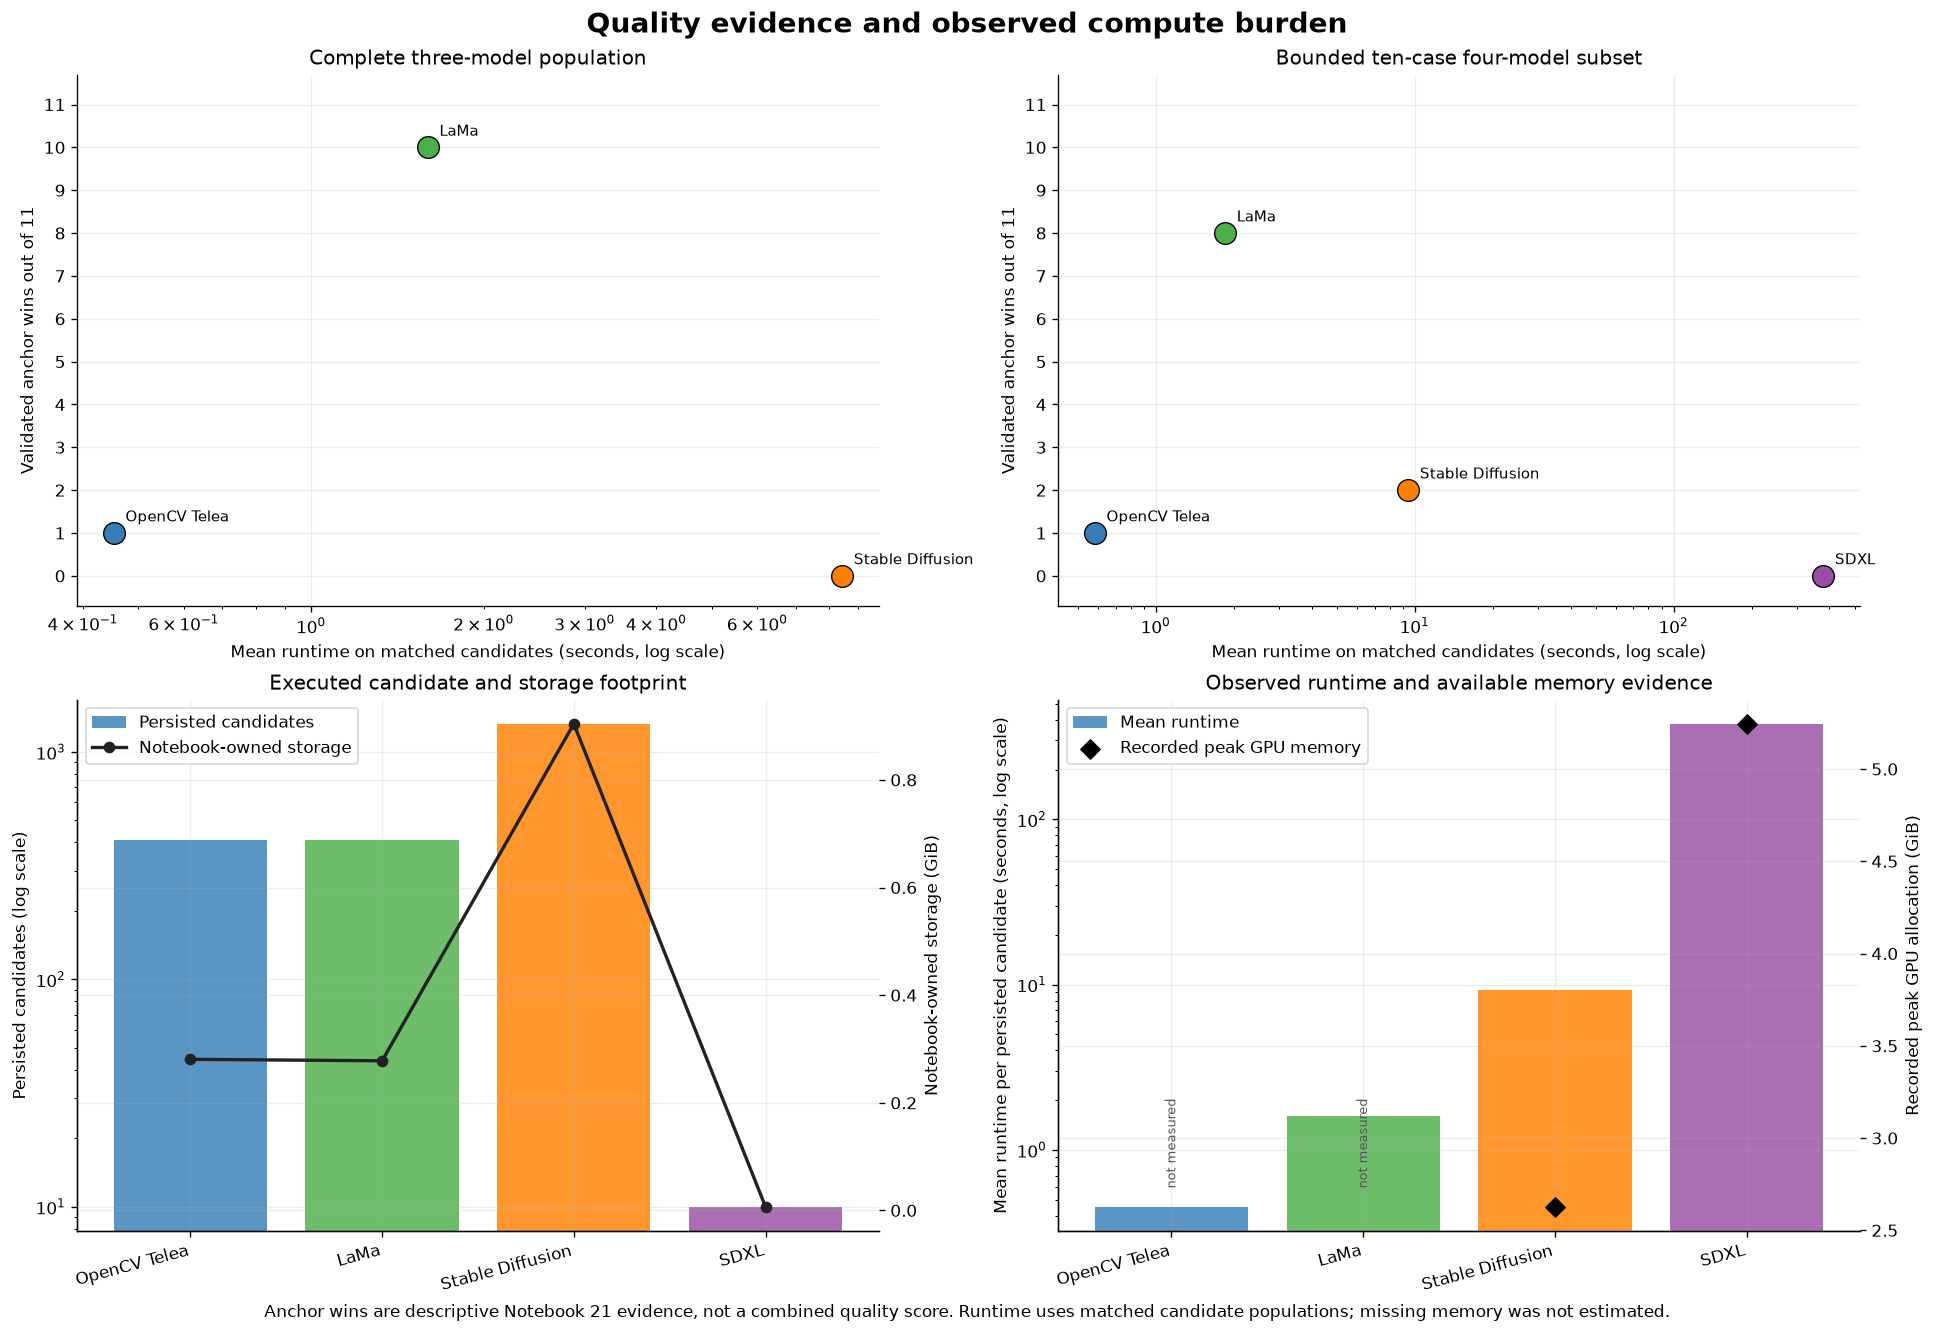

Quality-versus-compute figure generated.
Saved to: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\30_model_cards_compute_and_scalability\figures\quality_vs_compute.png


In [24]:
MODEL_LABELS = {
    "opencv_telea": "OpenCV Telea",
    "lama": "LaMa",
    "stable_diffusion_inpainting": (
        "Stable Diffusion"
    ),
    "sdxl_inpainting": "SDXL",
}

MODEL_COLORS = {
    "opencv_telea": "#377eb8",
    "lama": "#4daf4a",
    "stable_diffusion_inpainting": (
        "#ff7f00"
    ),
    "sdxl_inpainting": "#984ea3",
}

overall_figure_compute = (
    COMPUTE_SCALABILITY.loc[
        COMPUTE_SCALABILITY[
            "record_type"
        ].eq("observed")
        & COMPUTE_SCALABILITY[
            "summary_scope"
        ].eq("overall")
        & COMPUTE_SCALABILITY[
            "experiment_id"
        ].eq("all")
    ]
    .set_index("model_id")
    .loc[list(MODEL_LABELS)]
    .reset_index()
)

figure_1, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11),
    constrained_layout=True,
)

population_panels = (
    (
        "core_three_model",
        "Complete three-model population",
        axes[0, 0],
    ),
    (
        "sdxl_four_model_subset",
        "Bounded ten-case four-model subset",
        axes[0, 1],
    ),
)

for (
    population_id,
    panel_title,
    axis,
) in population_panels:
    subset = QUALITY_COMPUTE_VIEW.loc[
        QUALITY_COMPUTE_VIEW[
            "population_id"
        ].eq(population_id)
    ].copy()

    for row in subset.to_dict("records"):
        model_id = row["model_id"]

        axis.scatter(
            row["mean_runtime_seconds"],
            row["anchor_win_count"],
            s=170,
            color=MODEL_COLORS[model_id],
            edgecolor="black",
            linewidth=0.8,
            zorder=3,
        )

        axis.annotate(
            MODEL_LABELS[model_id],
            (
                row[
                    "mean_runtime_seconds"
                ],
                row["anchor_win_count"],
            ),
            xytext=(7, 7),
            textcoords="offset points",
            fontsize=9,
        )

    axis.set_xscale("log")
    axis.set_ylim(-0.7, 11.7)
    axis.set_yticks(
        np.arange(0, 12, 1)
    )
    axis.set_xlabel(
        "Mean runtime on matched candidates "
        "(seconds, log scale)"
    )
    axis.set_ylabel(
        "Validated anchor wins out of 11"
    )
    axis.set_title(panel_title)

model_order = list(MODEL_LABELS)
x_positions = np.arange(
    len(model_order)
)

candidate_counts = (
    overall_figure_compute
    .set_index("model_id")
    .loc[model_order][
        "candidate_count"
    ]
    .to_numpy(dtype=float)
)

storage_gib = (
    overall_figure_compute
    .set_index("model_id")
    .loc[model_order][
        "output_storage_bytes"
    ]
    .to_numpy(dtype=float)
    / (1024.0 ** 3)
)

candidate_axis = axes[1, 0]
storage_axis = candidate_axis.twinx()

candidate_axis.bar(
    x_positions,
    candidate_counts,
    color=[
        MODEL_COLORS[model_id]
        for model_id in model_order
    ],
    alpha=0.82,
    label="Persisted candidates",
)

storage_axis.plot(
    x_positions,
    storage_gib,
    color="#222222",
    marker="o",
    linewidth=2,
    label="Notebook-owned storage",
)

candidate_axis.set_yscale("log")
candidate_axis.set_xticks(
    x_positions,
    [
        MODEL_LABELS[model_id]
        for model_id in model_order
    ],
    rotation=15,
    ha="right",
)
candidate_axis.set_ylabel(
    "Persisted candidates (log scale)"
)
storage_axis.set_ylabel(
    "Notebook-owned storage (GiB)"
)
candidate_axis.set_title(
    "Executed candidate and storage footprint"
)

candidate_handles, candidate_labels = (
    candidate_axis.get_legend_handles_labels()
)
storage_handles, storage_labels = (
    storage_axis.get_legend_handles_labels()
)

candidate_axis.legend(
    candidate_handles + storage_handles,
    candidate_labels + storage_labels,
    loc="upper left",
)

runtime_values = (
    overall_figure_compute
    .set_index("model_id")
    .loc[model_order][
        "mean_runtime_seconds"
    ]
    .to_numpy(dtype=float)
)

gpu_peak_gib = (
    overall_figure_compute
    .set_index("model_id")
    .loc[model_order][
        "gpu_peak_memory_bytes"
    ]
    .to_numpy(dtype=float)
    / (1024.0 ** 3)
)

runtime_axis = axes[1, 1]
memory_axis = runtime_axis.twinx()

runtime_axis.bar(
    x_positions,
    runtime_values,
    color=[
        MODEL_COLORS[model_id]
        for model_id in model_order
    ],
    alpha=0.82,
    label="Mean runtime",
)

finite_memory = np.isfinite(
    gpu_peak_gib
)

memory_axis.scatter(
    x_positions[finite_memory],
    gpu_peak_gib[finite_memory],
    color="black",
    marker="D",
    s=65,
    zorder=4,
    label="Recorded peak GPU memory",
)

runtime_axis.set_yscale("log")
runtime_axis.set_xticks(
    x_positions,
    [
        MODEL_LABELS[model_id]
        for model_id in model_order
    ],
    rotation=15,
    ha="right",
)
runtime_axis.set_ylabel(
    "Mean runtime per persisted candidate "
    "(seconds, log scale)"
)
memory_axis.set_ylabel(
    "Recorded peak GPU allocation (GiB)"
)
runtime_axis.set_title(
    "Observed runtime and available memory evidence"
)

for position, model_id in enumerate(
    model_order
):
    if not finite_memory[position]:
        memory_axis.annotate(
            "not measured",
            (
                position,
                0.08,
            ),
            xycoords=(
                "data",
                "axes fraction",
            ),
            ha="center",
            va="bottom",
            fontsize=8,
            color="#555555",
            rotation=90,
        )

runtime_handles, runtime_labels = (
    runtime_axis.get_legend_handles_labels()
)
memory_handles, memory_labels = (
    memory_axis.get_legend_handles_labels()
)

runtime_axis.legend(
    runtime_handles + memory_handles,
    runtime_labels + memory_labels,
    loc="upper left",
)

figure_1.suptitle(
    "Quality evidence and observed compute burden",
    fontsize=17,
    fontweight="bold",
)

figure_1.supxlabel(
    (
        "Anchor wins are descriptive Notebook 21 evidence, "
        "not a combined quality score. Runtime uses matched "
        "candidate populations; missing memory was not estimated."
    ),
    fontsize=10,
)

figure_1.savefig(
    OUTPUT_PATHS[
        "quality_vs_compute_figure"
    ],
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Quality-versus-compute figure generated.")
print(
    "Saved to: "
    f"{OUTPUT_PATHS['quality_vs_compute_figure']}"
)

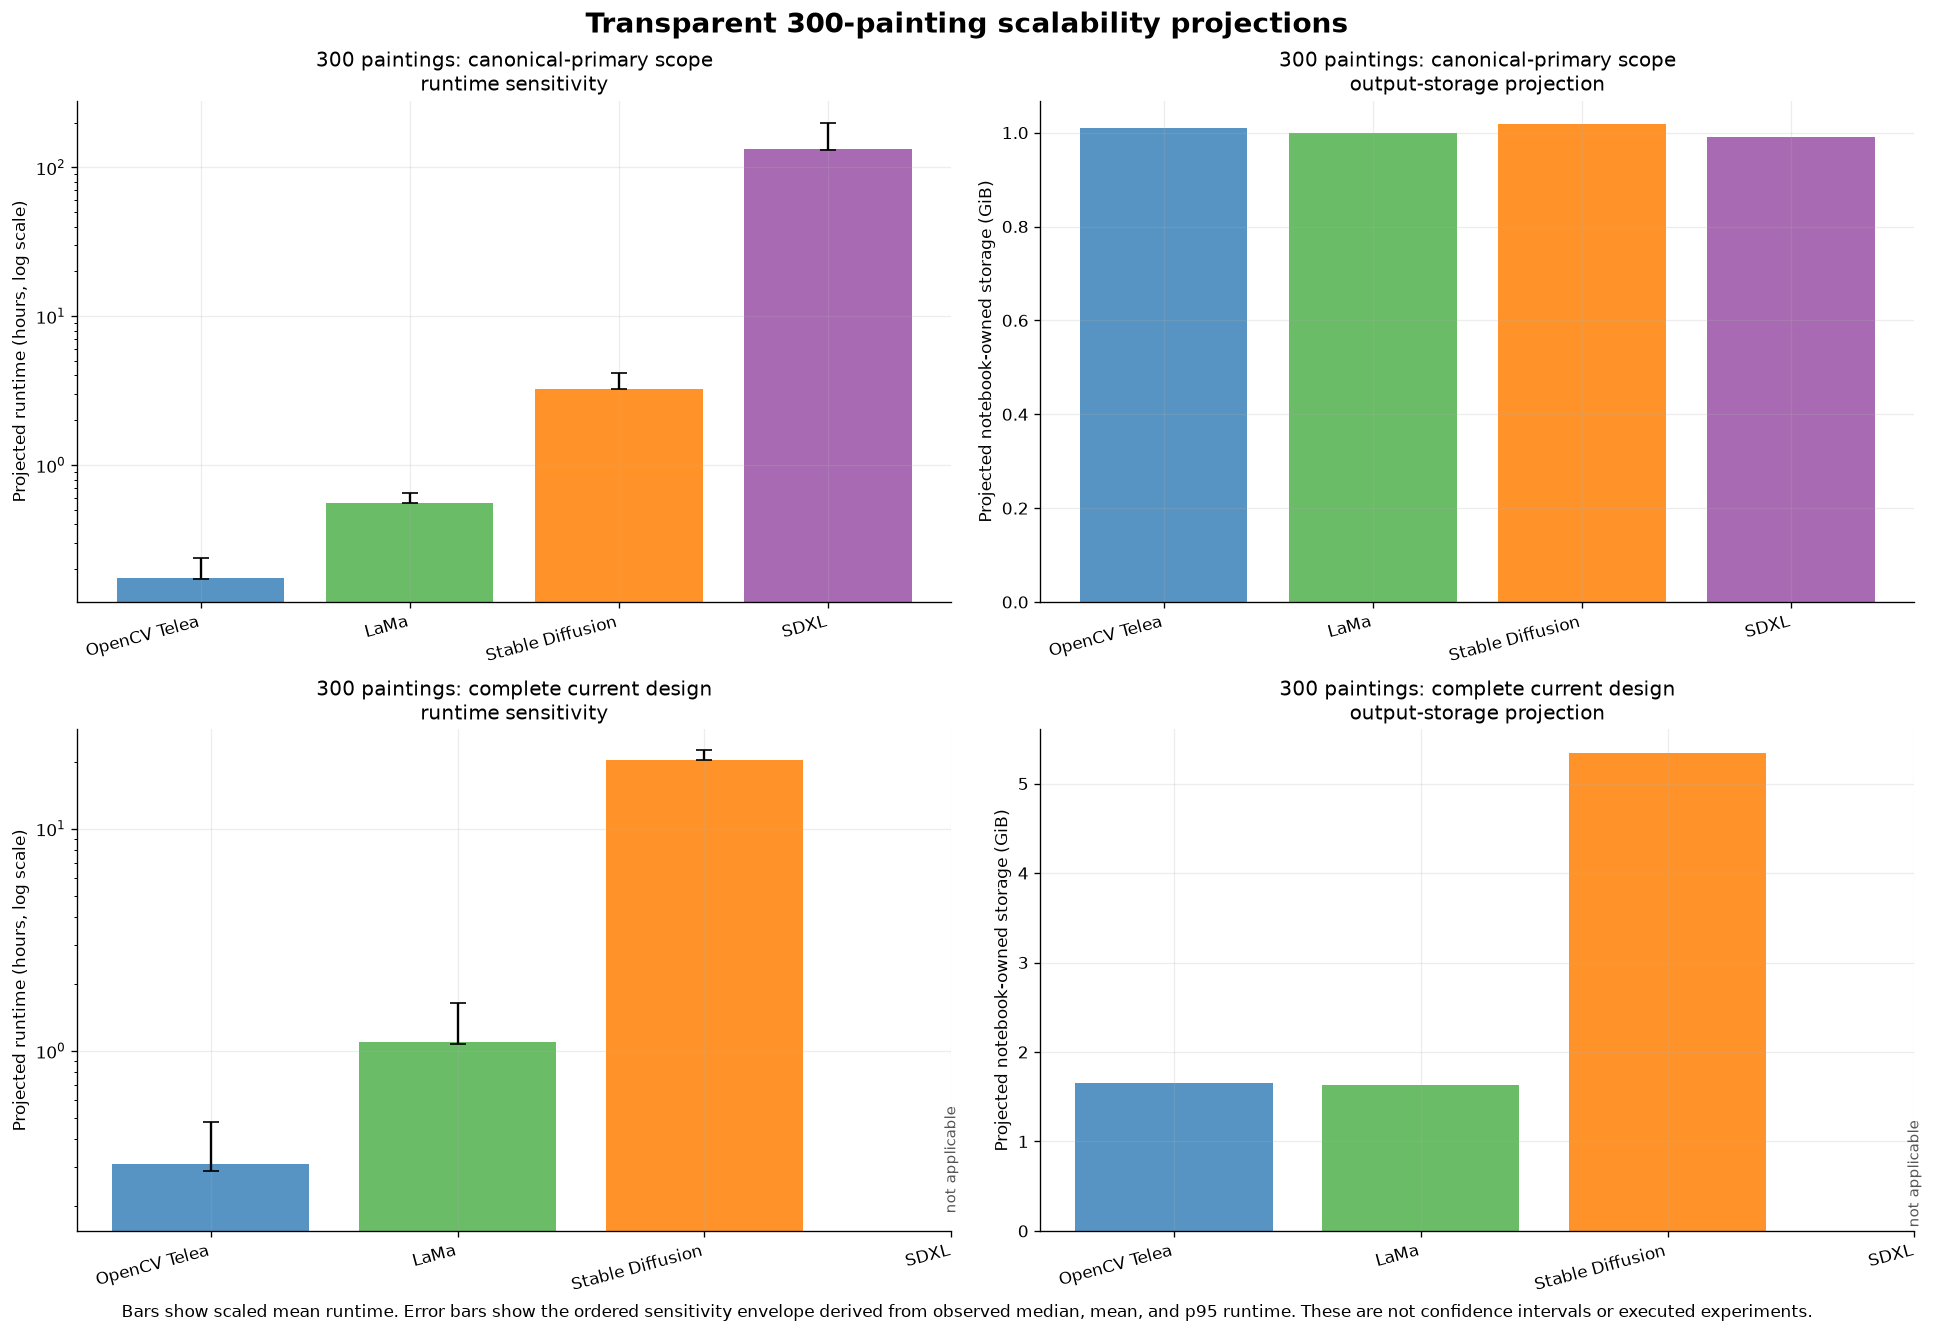

,figure_name,relative_path,exists,format,mode,width,height,size_bytes,sha256,verified
0,quality_vs_compute_figure,outputs/30_model_cards_compute_and_scalability/figures/quality_vs_compute.png,True,PNG,RGBA,2900,2000,336168,e524aa63094659129cc99cdfc8249e87b9852c655741bd5e2c22ef065964485b,True
1,scaling_projection_figure,outputs/30_model_cards_compute_and_scalability/figures/scaling_projection.png,True,PNG,RGBA,2900,2000,258923,0542eb1dee9e3751a92f5d42c7332d8ae7ad3a01d6172317f53598287ae14b3a,True


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_analysis_figures,quality_compute_population,Runtime evidence uses the same primary candidate populations as each quality view.,blocking,"{""core_three_model|lama"": 410, ""core_three_model|opencv_telea"": 410, ""core_three_model|stable_diffusion_inpainting"": 410, ""sdxl_four_model_subset|lama"": 10, ""sdxl_four_model_su...","{""core_three_model|lama"": 410, ""core_three_model|opencv_telea"": 410, ""core_three_model|stable_diffusion_inpainting"": 410, ""sdxl_four_model_subset|lama"": 10, ""sdxl_four_model_su...",True,
1,batch_6_analysis_figures,quality_compute_runtime_values,Population-matched runtime values are finite and non-negative.,blocking,True,True,True,
2,batch_6_analysis_figures,quality_compute_interpretation,Anchor wins remain descriptive and runtime is not included in a quality score.,blocking,True,"{""combined_quality_score"": false, ""runtime_in_quality_vote"": false}",True,
3,batch_6_analysis_figures,canonical_figures,"Both canonical Notebook 30 PNG figures exist, decode successfully, and have report-ready dimensions.",blocking,"{""figures"": 2, ""format"": ""PNG"", ""minimum_height"": 900, ""minimum_width"": 1600}","[{""exists"": true, ""figure_name"": ""quality_vs_compute_figure"", ""format"": ""PNG"", ""height"": 2000, ""mode"": ""RGBA"", ""relative_path"": ""outputs/30_model_cards_compute_and_scalability/...",True,


Batch 6 analysis and figures complete.
Validation checks: 4
Blocking failures: 0
Canonical figures generated: 2
Combined quality/compute score created: False
Projected rows presented as executed: False


In [25]:
scenario_order = [
    "projected_300_canonical_primary",
    "projected_300_current_design_mix",
]

scenario_titles = {
    "projected_300_canonical_primary": (
        "300 paintings: canonical-primary scope"
    ),
    "projected_300_current_design_mix": (
        "300 paintings: complete current design"
    ),
}

figure_2, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11),
    constrained_layout=True,
)

for row_index, scenario_id in enumerate(
    scenario_order
):
    subset = (
        PROJECTION_COMPUTE.loc[
            PROJECTION_COMPUTE[
                "scenario_id"
            ].eq(scenario_id)
        ]
        .set_index("model_id")
        .loc[model_order]
        .reset_index()
    )

    runtime_axis = axes[
        row_index,
        0,
    ]
    storage_axis = axes[
        row_index,
        1,
    ]

    central_hours = (
        subset[
            "runtime_central_seconds"
        ].to_numpy(dtype=float)
        / 3600.0
    )

    lower_hours = (
        subset[
            "runtime_lower_seconds"
        ].to_numpy(dtype=float)
        / 3600.0
    )

    upper_hours = (
        subset[
            "runtime_upper_seconds"
        ].to_numpy(dtype=float)
        / 3600.0
    )

    runtime_applicable = np.isfinite(
        central_hours
    )

    runtime_positions = (
        x_positions[
            runtime_applicable
        ]
    )

    runtime_values = (
        central_hours[
            runtime_applicable
        ]
    )

    lower_error = (
        runtime_values
        - lower_hours[
            runtime_applicable
        ]
    )

    upper_error = (
        upper_hours[
            runtime_applicable
        ]
        - runtime_values
    )

    runtime_axis.bar(
        runtime_positions,
        runtime_values,
        color=[
            MODEL_COLORS[
                model_order[position]
            ]
            for position
            in runtime_positions
        ],
        alpha=0.84,
    )

    runtime_axis.errorbar(
        runtime_positions,
        runtime_values,
        yerr=np.vstack(
            [
                lower_error,
                upper_error,
            ]
        ),
        fmt="none",
        ecolor="black",
        elinewidth=1.4,
        capsize=5,
        zorder=4,
    )

    runtime_axis.set_yscale("log")
    runtime_axis.set_xticks(
        x_positions,
        [
            MODEL_LABELS[model_id]
            for model_id in model_order
        ],
        rotation=15,
        ha="right",
    )
    runtime_axis.set_ylabel(
        "Projected runtime (hours, log scale)"
    )
    runtime_axis.set_title(
        f"{scenario_titles[scenario_id]}\n"
        "runtime sensitivity"
    )

    if not runtime_applicable.all():
        runtime_floor = float(
            np.nanmin(
                runtime_values
            )
            / 2.0
        )

        runtime_axis.set_ylim(
            bottom=runtime_floor
        )

        for position in x_positions[
            ~runtime_applicable
        ]:
            runtime_axis.text(
                position,
                runtime_floor * 1.2,
                "not applicable",
                ha="center",
                va="bottom",
                rotation=90,
                fontsize=9,
                color="#555555",
            )

    storage_values = (
        subset[
            "projected_output_storage_bytes"
        ].to_numpy(dtype=float)
        / (1024.0 ** 3)
    )

    storage_applicable = np.isfinite(
        storage_values
    )

    storage_axis.bar(
        x_positions[
            storage_applicable
        ],
        storage_values[
            storage_applicable
        ],
        color=[
            MODEL_COLORS[
                model_order[position]
            ]
            for position
            in x_positions[
                storage_applicable
            ]
        ],
        alpha=0.84,
    )

    storage_axis.set_xticks(
        x_positions,
        [
            MODEL_LABELS[model_id]
            for model_id in model_order
        ],
        rotation=15,
        ha="right",
    )
    storage_axis.set_ylabel(
        "Projected notebook-owned storage (GiB)"
    )
    storage_axis.set_title(
        f"{scenario_titles[scenario_id]}\n"
        "output-storage projection"
    )

    for position in x_positions[
        ~storage_applicable
    ]:
        storage_axis.text(
            position,
            0.04,
            "not applicable",
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=9,
            color="#555555",
        )

figure_2.suptitle(
    "Transparent 300-painting scalability projections",
    fontsize=17,
    fontweight="bold",
)

figure_2.supxlabel(
    (
        "Bars show scaled mean runtime. Error bars show "
        "the ordered sensitivity envelope derived from "
        "observed median, mean, and p95 runtime. These are "
        "not confidence intervals or executed experiments."
    ),
    fontsize=10,
)

figure_2.savefig(
    OUTPUT_PATHS[
        "scaling_projection_figure"
    ],
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

from PIL import Image

FIGURE_VALIDATION_ROWS = []

for figure_name in (
    "quality_vs_compute_figure",
    "scaling_projection_figure",
):
    figure_path = OUTPUT_PATHS[
        figure_name
    ]

    with Image.open(
        figure_path
    ) as image:
        image_format = image.format
        image_mode = image.mode
        image_width = int(image.width)
        image_height = int(image.height)
        image_verified = True

        image.verify()

    FIGURE_VALIDATION_ROWS.append(
        {
            "figure_name": figure_name,
            "relative_path": (
                figure_path
                .relative_to(PROJECT_ROOT)
                .as_posix()
            ),
            "exists": figure_path.exists(),
            "format": image_format,
            "mode": image_mode,
            "width": image_width,
            "height": image_height,
            "size_bytes": (
                figure_path.stat().st_size
            ),
            "sha256": sha256_file(
                figure_path
            ),
            "verified": image_verified,
        }
    )

FIGURE_VALIDATION = pd.DataFrame(
    FIGURE_VALIDATION_ROWS
)

figures_valid = (
    len(FIGURE_VALIDATION) == 2
    and FIGURE_VALIDATION[
        "exists"
    ].all()
    and FIGURE_VALIDATION[
        "format"
    ].eq("PNG").all()
    and FIGURE_VALIDATION[
        "width"
    ].ge(1600).all()
    and FIGURE_VALIDATION[
        "height"
    ].ge(900).all()
    and FIGURE_VALIDATION[
        "size_bytes"
    ].gt(0).all()
    and FIGURE_VALIDATION[
        "verified"
    ].all()
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="canonical_figures",
    description=(
        "Both canonical Notebook 30 PNG figures "
        "exist, decode successfully, and have "
        "report-ready dimensions."
    ),
    expected={
        "figures": 2,
        "format": "PNG",
        "minimum_width": 1600,
        "minimum_height": 900,
    },
    observed=FIGURE_VALIDATION.to_dict(
        "records"
    ),
    passed=figures_valid,
)

display(FIGURE_VALIDATION)

BATCH_6_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_6_ROWS = (
    BATCH_6_VALIDATION.loc[
        BATCH_6_VALIDATION[
            "validation_stage"
        ].eq(BATCH_6_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_6_ROWS)

blocking_failures = int(
    (
        BATCH_6_ROWS["severity"].eq("blocking")
        & ~BATCH_6_ROWS["passed"]
    ).sum()
)

print("Batch 6 analysis and figures complete.")
print(
    "Validation checks: "
    f"{len(BATCH_6_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Canonical figures generated: "
    f"{len(FIGURE_VALIDATION):,}"
)
print(
    "Combined quality/compute score created: "
    "False"
)
print(
    "Projected rows presented as executed: "
    "False"
)

VALIDATION.raise_for_blocking()

## Batch 7 — Canonical persistence and standalone model cards

This batch:

- refreshes the tested report renderer without requiring a kernel restart;
- renders four standalone Markdown model cards;
- includes all eleven applicable Notebook 21 anchors in every card;
- validates the approved thirteen-section structure;
- verifies that the cards contain no image, base64, or external-file dependency;
- writes `model_cards.csv` and `compute_scalability.csv` atomically;
- writes the four Markdown cards atomically;
- reloads both canonical CSVs from disk;
- repeats schema, row-count, scope, projection, and interpretation validation after reload;
- verifies exact report text, checksums, byte counts, and absence of temporary files;
- renders the completed Markdown cards in the notebook for human inspection.

This batch does not write the final manifest, artifact registry, or consolidated validation table.

In [26]:
BATCH_7_STAGE = "batch_7_persistence_reports"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_7_STAGE,
)

# Refresh the renderer after the final disclosure expansion.
model_cards_compute_module = importlib.reload(
    model_cards_compute_module
)

ANALYSIS_CONFIG = (
    model_cards_compute_module
    .load_model_cards_compute_config(
        CONFIG_PATH
    )
)

SETTINGS = ANALYSIS_CONFIG[
    "model_cards_compute"
]
REPORT_POLICY = SETTINGS["report"]
EXPECTED = SETTINGS["expected_counts"]

RENDERED_MODEL_CARDS = {}
report_validation_parts = []

for model_row in MODEL_CARDS.to_dict(
    "records"
):
    model_id = model_row["model_id"]

    rendered_card = (
        model_cards_compute_module
        .render_model_card_markdown(
            model_row,
            COMPUTE_SCALABILITY,
            QUALITY_VALUES,
            QUALITY_WIN_SUMMARY,
            config=ANALYSIS_CONFIG,
        )
    )

    RENDERED_MODEL_CARDS[
        model_id
    ] = rendered_card

    card_checks = (
        model_cards_compute_module
        .validate_model_card_markdown(
            rendered_card,
            model_id=model_id,
            config=ANALYSIS_CONFIG,
        )
    )

    card_checks.insert(
        0,
        "model_id",
        model_id,
    )

    report_validation_parts.append(
        card_checks
    )

    for check in card_checks.itertuples(
        index=False
    ):
        add_check(
            stage=BATCH_7_STAGE,
            check_id=(
                f"report_{model_id}_"
                f"{check.check_id}"
            ),
            description=(
                f"{model_id} Markdown-card validation: "
                f"{check.check_id}."
            ),
            expected=True,
            observed=check.details,
            passed=bool(check.passed),
        )

MODEL_CARD_REPORT_CHECKS = pd.concat(
    report_validation_parts,
    ignore_index=True,
)

all_anchor_tables_complete = all(
    all(
        rendered_card.count(
            f"| {anchor_id} |"
        )
        == 1
        for anchor_id
        in QUALITY_POLICY["anchors"]
    )
    for rendered_card
    in RENDERED_MODEL_CARDS.values()
)

report_count_valid = (
    len(RENDERED_MODEL_CARDS)
    == EXPECTED[
        "model_card_report_count"
    ]
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="all_report_anchor_tables",
    description=(
        "Every standalone card contains each of the "
        "eleven validated anchors exactly once."
    ),
    expected={
        "reports": 4,
        "anchors_per_report": 11,
    },
    observed={
        "reports": len(
            RENDERED_MODEL_CARDS
        ),
        "anchors_per_report": {
            model_id: sum(
                card.count(
                    f"| {anchor_id} |"
                )
                for anchor_id
                in QUALITY_POLICY["anchors"]
            )
            for model_id, card
            in RENDERED_MODEL_CARDS.items()
        },
    },
    passed=(
        report_count_valid
        and all_anchor_tables_complete
    ),
)

print("Standalone model cards rendered in memory.")
print(
    "Rendered cards: "
    f"{len(RENDERED_MODEL_CARDS):,}"
)
print(
    "Report validation checks: "
    f"{len(MODEL_CARD_REPORT_CHECKS):,}"
)
print(
    "Report validation failures: "
    f"{int((~MODEL_CARD_REPORT_CHECKS['passed']).sum()):,}"
)
print(
    "All eleven anchors retained per card: "
    f"{all_anchor_tables_complete}"
)

Standalone model cards rendered in memory.
Rendered cards: 4
Report validation checks: 40
Report validation failures: 0
All eleven anchors retained per card: True


In [27]:
import warnings

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=(
            "invalid value encountered in cast"
        ),
        category=RuntimeWarning,
    )

    model_cards_compute_module.atomic_write_csv(
        MODEL_CARDS,
        OUTPUT_PATHS["model_cards"],
    )

    model_cards_compute_module.atomic_write_csv(
        COMPUTE_SCALABILITY,
        OUTPUT_PATHS[
            "compute_scalability"
        ],
    )

for (
    model_id,
    rendered_card,
) in RENDERED_MODEL_CARDS.items():
    model_cards_compute_module.atomic_write_text(
        rendered_card,
        MODEL_CARD_REPORT_PATHS[
            model_id
        ],
    )

RELOADED_MODEL_CARDS = pd.read_csv(
    OUTPUT_PATHS["model_cards"],
    low_memory=False,
)

RELOADED_COMPUTE_SCALABILITY = (
    pd.read_csv(
        OUTPUT_PATHS[
            "compute_scalability"
        ],
        low_memory=False,
    )
)

RELOADED_MODEL_CARD_CHECKS = (
    model_cards_compute_module
    .validate_model_cards(
        RELOADED_MODEL_CARDS,
        config=ANALYSIS_CONFIG,
    )
)

RELOADED_COMPUTE_CHECKS = (
    model_cards_compute_module
    .validate_compute_scalability(
        RELOADED_COMPUTE_SCALABILITY,
        config=ANALYSIS_CONFIG,
    )
)

for check in (
    RELOADED_MODEL_CARD_CHECKS.itertuples(
        index=False
    )
):
    add_check(
        stage=BATCH_7_STAGE,
        check_id=(
            f"reloaded_model_cards_"
            f"{check.check_id}"
        ),
        description=(
            "Reloaded model-card table validation: "
            f"{check.check_id}."
        ),
        expected=True,
        observed=check.details,
        passed=bool(check.passed),
    )

for check in (
    RELOADED_COMPUTE_CHECKS.itertuples(
        index=False
    )
):
    add_check(
        stage=BATCH_7_STAGE,
        check_id=(
            f"reloaded_compute_"
            f"{check.check_id}"
        ),
        description=(
            "Reloaded compute table validation: "
            f"{check.check_id}."
        ),
        expected=True,
        observed=check.details,
        passed=bool(check.passed),
    )

report_file_rows = []

for (
    model_id,
    report_path,
) in MODEL_CARD_REPORT_PATHS.items():
    persisted_text = report_path.read_text(
        encoding="utf-8-sig"
    )

    expected_text = (
        RENDERED_MODEL_CARDS[
            model_id
        ]
    )

    report_file_rows.append(
        {
            "model_id": model_id,
            "relative_path": (
                report_path
                .relative_to(PROJECT_ROOT)
                .as_posix()
            ),
            "exists": report_path.exists(),
            "size_bytes": (
                report_path.stat().st_size
            ),
            "line_count": len(
                persisted_text.splitlines()
            ),
            "required_sections": sum(
                persisted_text.count(
                    f'<a id="{section_id}"></a>'
                )
                for section_id
                in REPORT_POLICY[
                    "required_section_ids"
                ]
            ),
            "anchor_rows": sum(
                persisted_text.count(
                    f"| {anchor_id} |"
                )
                for anchor_id
                in QUALITY_POLICY["anchors"]
            ),
            "text_matches_memory": (
                persisted_text
                == expected_text
            ),
            "sha256": sha256_file(
                report_path
            ),
        }
    )

PERSISTED_REPORT_INDEX = pd.DataFrame(
    report_file_rows
)

persisted_reports_valid = (
    len(PERSISTED_REPORT_INDEX) == 4
    and PERSISTED_REPORT_INDEX[
        "exists"
    ].all()
    and PERSISTED_REPORT_INDEX[
        "size_bytes"
    ].gt(4000).all()
    and PERSISTED_REPORT_INDEX[
        "required_sections"
    ].eq(13).all()
    and PERSISTED_REPORT_INDEX[
        "anchor_rows"
    ].eq(11).all()
    and PERSISTED_REPORT_INDEX[
        "text_matches_memory"
    ].all()
)

temporary_files = sorted(
    path.relative_to(PROJECT_ROOT).as_posix()
    for path in OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and (
            path.suffix.casefold()
            == ".tmp"
            or ".tmp." in path.name.casefold()
            or path.name.startswith(".")
        )
    )
)

persisted_scientific_files = (
    [
        OUTPUT_PATHS["model_cards"],
        OUTPUT_PATHS[
            "compute_scalability"
        ],
        OUTPUT_PATHS[
            "quality_vs_compute_figure"
        ],
        OUTPUT_PATHS[
            "scaling_projection_figure"
        ],
    ]
    + list(
        MODEL_CARD_REPORT_PATHS.values()
    )
)

persisted_scientific_files_valid = (
    len(persisted_scientific_files) == 8
    and all(
        path.exists()
        and path.is_file()
        and path.stat().st_size > 0
        for path
        in persisted_scientific_files
    )
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="canonical_tables_reloaded",
    description=(
        "Both canonical CSVs reload with their exact "
        "schemas, row counts, and scientific contracts."
    ),
    expected={
        "model_cards": 4,
        "compute_rows": 35,
    },
    observed={
        "model_cards": len(
            RELOADED_MODEL_CARDS
        ),
        "compute_rows": len(
            RELOADED_COMPUTE_SCALABILITY
        ),
        "model_card_failures": int(
            (
                ~RELOADED_MODEL_CARD_CHECKS[
                    "passed"
                ]
            ).sum()
        ),
        "compute_failures": int(
            (
                ~RELOADED_COMPUTE_CHECKS[
                    "passed"
                ]
            ).sum()
        ),
    },
    passed=(
        len(RELOADED_MODEL_CARDS) == 4
        and len(
            RELOADED_COMPUTE_SCALABILITY
        )
        == 35
        and RELOADED_MODEL_CARD_CHECKS[
            "passed"
        ].all()
        and RELOADED_COMPUTE_CHECKS[
            "passed"
        ].all()
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="standalone_reports_persisted",
    description=(
        "All four Markdown cards match their validated "
        "in-memory text and retain all required sections."
    ),
    expected=True,
    observed=PERSISTED_REPORT_INDEX.to_dict(
        "records"
    ),
    passed=persisted_reports_valid,
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="scientific_files_persisted",
    description=(
        "The two CSVs, four cards, and two figures "
        "exist as the eight scientific output files."
    ),
    expected=8,
    observed=sum(
        path.exists()
        for path
        in persisted_scientific_files
    ),
    passed=(
        persisted_scientific_files_valid
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="no_temporary_files",
    description=(
        "Atomic persistence left no temporary or "
        "hidden checkpoint files in the output root."
    ),
    expected=[],
    observed=temporary_files,
    passed=not temporary_files,
)

display(PERSISTED_REPORT_INDEX)

print("Canonical tables and cards persisted.")
print(
    "Reloaded model-card rows: "
    f"{len(RELOADED_MODEL_CARDS):,}"
)
print(
    "Reloaded compute rows: "
    f"{len(RELOADED_COMPUTE_SCALABILITY):,}"
)
print(
    "Persisted scientific files: "
    f"{sum(path.exists() for path in persisted_scientific_files):,}/8"
)
print(
    "Temporary files: "
    f"{len(temporary_files):,}"
)

,model_id,relative_path,exists,size_bytes,line_count,required_sections,anchor_rows,text_matches_memory,sha256
0,opencv_telea,outputs/30_model_cards_compute_and_scalability/reports/model_cards/opencv_telea.md,True,9131,213,13,11,True,992f5a33196dbc4fa2bf3f3082e45c03cb5248b6eff7b7cb1b9342e050ed3b22
1,lama,outputs/30_model_cards_compute_and_scalability/reports/model_cards/lama.md,True,10073,217,13,11,True,3ff95d1656fb130a774dbe88c896a8577044c9a6a80c3de7a3824315acdc89b8
2,stable_diffusion_inpainting,outputs/30_model_cards_compute_and_scalability/reports/model_cards/stable_diffusion_inpainting.md,True,10834,220,13,11,True,e2e999f7ac3299e3deb2c4678a5676e05f869dd8c08426938be2cdbf55f0eb12
3,sdxl_inpainting,outputs/30_model_cards_compute_and_scalability/reports/model_cards/sdxl_inpainting.md,True,10104,215,13,11,True,eb8d40481f2228a47fc0b0b05942a092f79a6763ef1894d41b46646262a2de95


Canonical tables and cards persisted.
Reloaded model-card rows: 4
Reloaded compute rows: 35
Persisted scientific files: 8/8
Temporary files: 0


In [28]:
BATCH_7_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_7_ROWS = (
    BATCH_7_VALIDATION.loc[
        BATCH_7_VALIDATION[
            "validation_stage"
        ].eq(BATCH_7_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_7_ROWS)

blocking_failures = int(
    (
        BATCH_7_ROWS["severity"].eq("blocking")
        & ~BATCH_7_ROWS["passed"]
    ).sum()
)

print("Batch 7 persistence and report validation complete.")
print(
    "Validation checks: "
    f"{len(BATCH_7_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Standalone Markdown cards: "
    f"{len(PERSISTED_REPORT_INDEX):,}"
)
print(
    "Required sections per card: "
    f"{PERSISTED_REPORT_INDEX['required_sections'].tolist()}"
)
print(
    "Quality anchors per card: "
    f"{PERSISTED_REPORT_INDEX['anchor_rows'].tolist()}"
)

VALIDATION.raise_for_blocking()

for model_id in (
    "opencv_telea",
    "lama",
    "stable_diffusion_inpainting",
    "sdxl_inpainting",
):
    display(
        Markdown(
            RENDERED_MODEL_CARDS[
                model_id
            ]
        )
    )

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_persistence_reports,report_opencv_telea_report_nonempty,opencv_telea Markdown-card validation: report_nonempty.,blocking,True,bytes=9131,True,
1,batch_7_persistence_reports,report_opencv_telea_model_id_present,opencv_telea Markdown-card validation: model_id_present.,blocking,True,opencv_telea,True,
2,batch_7_persistence_reports,report_opencv_telea_required_sections,opencv_telea Markdown-card validation: required_sections.,blocking,True,required=13,True,
3,batch_7_persistence_reports,report_opencv_telea_section_order,opencv_telea Markdown-card validation: section_order.,blocking,True,approved mock order,True,
4,batch_7_persistence_reports,report_opencv_telea_no_image_dependencies,opencv_telea Markdown-card validation: no_image_dependencies.,blocking,True,image_tokens=0,True,
...,...,...,...,...,...,...,...,...
65,batch_7_persistence_reports,reloaded_compute_no_executed_300,Reloaded compute table validation: no_executed_300.,blocking,True,300-painting scope is projected only,True,
66,batch_7_persistence_reports,canonical_tables_reloaded,"Both canonical CSVs reload with their exact schemas, row counts, and scientific contracts.",blocking,"{""compute_rows"": 35, ""model_cards"": 4}","{""compute_failures"": 0, ""compute_rows"": 35, ""model_card_failures"": 0, ""model_cards"": 4}",True,
67,batch_7_persistence_reports,standalone_reports_persisted,All four Markdown cards match their validated in-memory text and retain all required sections.,blocking,True,"[{""anchor_rows"": 11, ""exists"": true, ""line_count"": 213, ""model_id"": ""opencv_telea"", ""relative_path"": ""outputs/30_model_cards_compute_and_scalability/reports/model_cards/opencv_...",True,
68,batch_7_persistence_reports,scientific_files_persisted,"The two CSVs, four cards, and two figures exist as the eight scientific output files.",blocking,8,8,True,


Batch 7 persistence and report validation complete.
Validation checks: 70
Blocking failures: 0
Standalone Markdown cards: 4
Required sections per card: [13, 13, 13, 13]
Quality anchors per card: [11, 11, 11, 11]


# OpenCV Telea - Model Card and Compute Audit

**Evaluation status:** Fully Evaluated  
**Method role:** classical deterministic baseline  
**Dataset scope:** controlled_50  
**Decision boundary:** Digital restoration candidate method, not a conservation authority

<a id="at-a-glance"></a>
## 1. At a glance

OpenCV Telea was the fastest and most reproducible baseline, while its local interpolation remained limited for semantically demanding missing regions.

- Completed candidates: **410 of 410**.
- Mean runtime: **0.45 seconds per candidate**.
- Observed notebook-owned storage: **287.49 MiB**.
- Validated anchor wins in the applicable population: **1 of 11**.

**Conclusion:** The compute and quality evidence support this method only within its declared evaluation scope. Anchor wins are descriptive Notebook 21 outcomes, not a combined quality score or conservation verdict.

<a id="identity-and-provenance"></a>
## 2. Identity and provenance

| Field | Recorded value |
|---|---|
| Model ID | `opencv_telea` |
| Family | classical fast marching inpainting |
| Original purpose | Local image inpainting from the boundary of a masked region. |
| Project implementation | OpenCV cv2.INPAINT_TELEA |
| Implementation version | 4.11.0 |
| Model identifier | `cv2.INPAINT_TELEA` |
| Model revision | `opencv-4.11.0` |
| Software licence | Apache-2.0 |
| Weight licence | not_applicable_no_model_weights |

OpenCV software licence; the Telea method has no learned weights.

<a id="intended-and-unsupported-use"></a>
## 3. Intended and unsupported use

Appropriate project uses:

- classical deterministic restoration baseline
- small local damage and thin-scratch comparison
- reproducible candidate generation for controlled evaluation

Unsupported uses:

- historically verified reconstruction
- semantic reconstruction of large missing structures
- conservation approval

<a id="training-data-and-domain-gap"></a>
## 4. Training data and painting-domain gap

Not applicable; this is a classical non-learning algorithm.

**Training-data transparency status:** not applicable

**Domain gap:** No painting-specific knowledge, semantic model, or brushwork model.

**Bias and risk:** No learned training-data bias; locality and interpolation assumptions remain algorithmic biases.

**Conclusion:** Source transparency and general-image performance do not establish painting-specific historical or conservation competence.

<a id="project-implementation"></a>
## 5. Project implementation

| Setting | Recorded value |
|---|---|
| Configuration | `opencv_telea_r3_threshold_policy_v1` |
| Device | cpu |
| Backend | opencv_cpu |
| Recorded accelerator | not applicable (CPU execution) |
| Precision | uint8 |
| Inference resolution | 768 x 768 |
| Output resolution | 768 x 768 |
| Input constraints | Normalized 768 x 768 RGB uint8 painting input; identity zero controls bypass inference. |
| Mask constraints | Single-channel binary missing-region mask using threshold 128; fixed Telea radius 3; no per-case tuning. |
| Deterministic | True |
| Prompt dependent | False |
| Hardware statement | CPU execution; no GPU required under the evaluated contract. |

The project used a fixed predeclared configuration and exact outside-mask compositing policy where applicable. Per-case metric-guided tuning was not used.

<a id="evaluated-evidence-coverage"></a>
## 6. Evaluated evidence coverage

| Coverage field | Recorded count |
|---|---:|
| Paintings | 50 |
| Unique cases | 410 |
| Candidates | 410 |
| Model-inference candidates | 360 |
| Identity zero controls | 50 |

Cases and repeated candidates remain nested within paintings. Candidate rows are not treated as independent artworks.

<a id="compute-and-storage"></a>
## 7. Compute and storage

| Measure | Observed result |
|---|---:|
| Total runtime | 3.1 minutes |
| Mean runtime | 0.453 s |
| Median runtime | 0.424 s |
| p95 runtime | 0.698 s |
| Failed candidates | 0 |
| Failure rate | 0.00% |
| Retries | 0 |
| Throughput | 2.2089 candidates/second |
| Candidate multiplier | 1.0000 candidates per evaluated case |
| Recorded peak GPU allocation | not applicable |
| Recorded total GPU memory | not applicable |
| Output files | 416 |
| Output storage | 287.49 MiB |

**Conclusion:** These measurements describe the recorded workstation and software environment. They are project evidence, not universal hardware benchmarks.

<a id="quality-evidence"></a>
## 8. Quality evidence

Applicable population: `core_three_model` (410 cases nested within 50 paintings).

| Validated anchor | Restored mean | Rank | Winner |
|---|---:|---:|---|
| classical_masked_mae | 17.258 | 2 | lama |
| colour_masked_delta_e | 7.858 | 2 | lama |
| feature_clip_crop | 0.88628 | 3 | lama |
| feature_dino_crop | 0.69663 | 3 | lama |
| perceptual_crop_lpips | 0.18639 | 3 | lama |
| seam_boundary_gradient | 0.0075863 | 2 | lama |
| semantic_local_dino | 0.60301 | 3 | lama |
| spatial_masked_error | 17.258 | 2 | lama |
| structural_affinity_correlation | 0.85369 | 3 | lama |
| structural_crop_ssim | 0.87224 | 1 | opencv_telea |
| texture_crop_p95 | 0.63161 | 2 | lama |

The method won 1 of 11 validated anchors in this population. Its strongest displayed anchor was `structural_crop_ssim`.

**Conclusion:** Better or worse language applies only to the named anchor and population. Runtime is not included in the quality vote, and the anchor count is not a universal quality score.

<a id="determinism-robustness-and-uncertainty"></a>
## 9. Determinism, robustness, and uncertainty

OpenCV Telea is deterministic. Its appropriate reliability evidence is input robustness and sensitivity, not generative uncertainty.

Low variability or deterministic repetition does not prove that a reconstructed region is correct.

<a id="scalability"></a>
## 10. Scalability

| Scenario | Candidate outputs | Central runtime projection | Output-storage projection |
|---|---:|---:|---:|
| projected_300_canonical_primary | 1,500 | 10.4 minutes | 1.01 GiB |
| projected_300_current_design_mix | 2,460 | 18.6 minutes | 1.65 GiB |

Raw observed median, mean, and p95 runtimes are retained in the compute table. The displayed sensitivity envelope uses the smaller of scaled median and mean as its lower value, scaled mean as its central value, and the larger of scaled p95 and mean as its upper value. These are not confidence intervals. No 300-painting experiment was executed.

<a id="strengths-and-weaknesses"></a>
## 11. Strengths and weaknesses

Strengths:

- fast and deterministic
- transparent classical baseline
- low compute burden

Weaknesses:

- no semantic understanding
- limited large-mask reconstruction
- local interpolation may lose meaningful structure

Known project limitations:

- Runtime and memory observations describe one recorded local workstation and software environment.
- The 300-painting values are transparent linear projections, not executed experiments.
- Projected storage covers notebook-owned output artifacts and excludes model caches, environments, Git history, and downstream metric outputs.
- SDXL has ten completed candidates nested within five paintings and cannot support a full-scope ranking.
- LaMa per-case runtime includes transparent allocation from IOPaint batch wall-clock measurements.
- Quality-anchor wins are descriptive validated Notebook 21 evidence, not a universal quality or conservation score.
- OpenCV Telea is a local interpolation baseline and does not reconstruct historically verified content.
- A fixed radius of 3 is used without per-case tuning.
- Eligible synthetic-degradation cases are supplementary masked-removal diagnostics and must remain separate from missing-content claims.
- Runtime measurements describe the recorded CPU environment and are not universal benchmarks.

<a id="human-decision-support-interpretation"></a>
## 12. Human decision-support interpretation

The method can generate and prioritize digital candidates for structured inspection. Reviewers should examine repaired structure, local texture, colour continuity, seams, uncertainty where applicable, and disagreements between evidence families.

**Decision statement:** This card supports transparent method selection and review planning. It does not approve physical treatment, establish historical truth, or replace expert conservation judgement.

<a id="reproducibility-and-provenance"></a>
## 13. Reproducibility and provenance

| Field | Recorded value |
|---|---|
| Producer notebook | `30_model_cards_compute_and_scalability.ipynb` |
| Candidate producer | Notebook 09 |
| Quality producer | Notebook 21 |
| Compute schema | `compute_scalability.v1` |
| Model-card schema | `model_cards.v1` |
| Source review date | 2026-09-02T00:00:00Z |

Primary and runtime sources:

- https://docs.opencv.org/4.x/d7/d8b/group__photo__inpaint.html
- https://github.com/opencv/opencv

### Final scoped verdict

OpenCV Telea was the fastest and most reproducible baseline, while its local interpolation remained limited for semantically demanding missing regions. This conclusion remains limited to the controlled evidence and the recorded compute environment.


# LaMa - Model Card and Compute Audit

**Evaluation status:** Fully Evaluated  
**Method role:** learned deterministic inpainting baseline  
**Dataset scope:** controlled_50  
**Decision boundary:** Digital restoration candidate method, not a conservation authority

<a id="at-a-glance"></a>
## 1. At a glance

LaMa provided the strongest broad reference-based baseline under the validated full-scope anchor policy.

- Completed candidates: **410 of 410**.
- Mean runtime: **1.60 seconds per candidate**.
- Observed notebook-owned storage: **284.69 MiB**.
- Validated anchor wins in the applicable population: **10 of 11**.

**Conclusion:** The compute and quality evidence support this method only within its declared evaluation scope. Anchor wins are descriptive Notebook 21 outcomes, not a combined quality score or conservation verdict.

<a id="identity-and-provenance"></a>
## 2. Identity and provenance

| Field | Recorded value |
|---|---|
| Model ID | `lama` |
| Family | learned fourier convolution inpainting |
| Original purpose | Resolution-robust large-mask image inpainting using Fourier convolutions. |
| Project implementation | IOPaint CLI model=lama |
| Implementation version | 1.6.0 |
| Model identifier | `big-lama.pt` |
| Model revision | `iopaint_lama_default` |
| Software licence | Apache-2.0_method_and_runtime_code |
| Weight licence | not_separately_verified_in_project_sources |

The LaMa and IOPaint code are Apache-2.0; the downloaded Big-LaMa weight artifact is not assigned a separate project-verified licence claim.

<a id="intended-and-unsupported-use"></a>
## 3. Intended and unsupported use

Appropriate project uses:

- learned large-mask inpainting baseline
- controlled digital restoration candidate generation
- quality and robustness comparison against classical and diffusion methods

Unsupported uses:

- historically verified reconstruction
- artist authentication or semantic brushstroke recognition
- conservation approval

<a id="training-data-and-domain-gap"></a>
## 4. Training data and painting-domain gap

Official LaMa documentation describes Places365/Places-based training; the exact IOPaint-converted checkpoint-to-training-run mapping is not independently verified here.

**Training-data transparency status:** partial

**Domain gap:** General-scene inpainting training does not establish painting-specific or conservation-specific competence.

**Bias and risk:** Learned priors may smooth texture or synthesize plausible but unsupported structures.

**Conclusion:** Source transparency and general-image performance do not establish painting-specific historical or conservation competence.

<a id="project-implementation"></a>
## 5. Project implementation

| Setting | Recorded value |
|---|---|
| Configuration | `lama_iopaint_masked_composite_v1` |
| Device | cuda |
| Backend | iopaint |
| Recorded accelerator | NVIDIA GeForce RTX 3060 Laptop GPU |
| Precision | float32 |
| Inference resolution | 768 x 768 |
| Output resolution | 768 x 768 |
| Input constraints | Normalized 768 x 768 RGB painting input passed through the pinned IOPaint LaMa runtime; identity zero controls bypass inference. |
| Mask constraints | Single-channel binary missing-region mask using threshold 128; exact outside-mask compositing; no per-case tuning. |
| Deterministic | True |
| Prompt dependent | False |
| Hardware statement | Executed with CUDA on the recorded RTX 3060 Laptop GPU; no experimentally validated minimum VRAM threshold is claimed. |

The project used a fixed predeclared configuration and exact outside-mask compositing policy where applicable. Per-case metric-guided tuning was not used.

<a id="evaluated-evidence-coverage"></a>
## 6. Evaluated evidence coverage

| Coverage field | Recorded count |
|---|---:|
| Paintings | 50 |
| Unique cases | 410 |
| Candidates | 410 |
| Model-inference candidates | 360 |
| Identity zero controls | 50 |

Cases and repeated candidates remain nested within paintings. Candidate rows are not treated as independent artworks.

<a id="compute-and-storage"></a>
## 7. Compute and storage

| Measure | Observed result |
|---|---:|
| Total runtime | 10.9 minutes |
| Mean runtime | 1.598 s |
| Median runtime | 1.567 s |
| p95 runtime | 2.395 s |
| Failed candidates | 0 |
| Failure rate | 0.00% |
| Retries | 0 |
| Throughput | 0.6259 candidates/second |
| Candidate multiplier | 1.0000 candidates per evaluated case |
| Recorded peak GPU allocation | not applicable |
| Recorded total GPU memory | not applicable |
| Output files | 416 |
| Output storage | 284.69 MiB |

**Conclusion:** These measurements describe the recorded workstation and software environment. They are project evidence, not universal hardware benchmarks.

<a id="quality-evidence"></a>
## 8. Quality evidence

Applicable population: `core_three_model` (410 cases nested within 50 paintings).

| Validated anchor | Restored mean | Rank | Winner |
|---|---:|---:|---|
| classical_masked_mae | 14.537 | 1 | lama |
| colour_masked_delta_e | 6.931 | 1 | lama |
| feature_clip_crop | 0.95654 | 1 | lama |
| feature_dino_crop | 0.87159 | 1 | lama |
| perceptual_crop_lpips | 0.1251 | 1 | lama |
| seam_boundary_gradient | 0.0064142 | 1 | lama |
| semantic_local_dino | 0.79993 | 1 | lama |
| spatial_masked_error | 14.537 | 1 | lama |
| structural_affinity_correlation | 0.95578 | 1 | lama |
| structural_crop_ssim | 0.8704 | 2 | opencv_telea |
| texture_crop_p95 | 0.43333 | 1 | lama |

The method won 10 of 11 validated anchors in this population. Its strongest displayed anchor was `classical_masked_mae`.

**Conclusion:** Better or worse language applies only to the named anchor and population. Runtime is not included in the quality vote, and the anchor count is not a universal quality score.

<a id="determinism-robustness-and-uncertainty"></a>
## 9. Determinism, robustness, and uncertainty

LaMa is deterministic under the evaluated contract. Mask robustness and damage sensitivity are the relevant reliability constructs; repeated-seed generative uncertainty is not applicable.

Low variability or deterministic repetition does not prove that a reconstructed region is correct.

<a id="scalability"></a>
## 10. Scalability

| Scenario | Candidate outputs | Central runtime projection | Output-storage projection |
|---|---:|---:|---:|
| projected_300_canonical_primary | 1,500 | 33.2 minutes | 1,023.50 MiB |
| projected_300_current_design_mix | 2,460 | 65.5 minutes | 1.63 GiB |

Raw observed median, mean, and p95 runtimes are retained in the compute table. The displayed sensitivity envelope uses the smaller of scaled median and mean as its lower value, scaled mean as its central value, and the larger of scaled p95 and mean as its upper value. These are not confidence intervals. No 300-painting experiment was executed.

<a id="strengths-and-weaknesses"></a>
## 11. Strengths and weaknesses

Strengths:

- broad learned context
- practical large-mask baseline
- deterministic under the evaluated contract

Weaknesses:

- general-scene rather than painting-specific training
- possible texture smoothing
- plausible content may remain historically incorrect

Known project limitations:

- Runtime and memory observations describe one recorded local workstation and software environment.
- The 300-painting values are transparent linear projections, not executed experiments.
- Projected storage covers notebook-owned output artifacts and excludes model caches, environments, Git history, and downstream metric outputs.
- SDXL has ten completed candidates nested within five paintings and cannot support a full-scope ranking.
- LaMa per-case runtime includes transparent allocation from IOPaint batch wall-clock measurements.
- Quality-anchor wins are descriptive validated Notebook 21 evidence, not a universal quality or conservation score.
- LaMa produces plausible learned inpainting, not historically verified reconstruction.
- IOPaint batch execution exposes group wall-clock runtime; per-case inference runtimes are transparently allocated estimates.
- The fixed model and mask policies are not tuned per painting or per damage case.
- Eligible synthetic-degradation cases are supplementary masked-removal diagnostics and remain separate from missing-content claims.
- Exact model-weight provenance depends on the locally resolved IOPaint cache artifact and is recorded when discoverable.
- CUDA inference is evaluated for tightly bounded numerical repeatability rather than byte-identical output; the configured smoke tolerance permits at most one 8-bit channel level of deviation while outside-mask invariance remains exact.
- Runtime measurements describe the recorded hardware and software environment and are not universal benchmarks.

<a id="human-decision-support-interpretation"></a>
## 12. Human decision-support interpretation

The method can generate and prioritize digital candidates for structured inspection. Reviewers should examine repaired structure, local texture, colour continuity, seams, uncertainty where applicable, and disagreements between evidence families.

**Decision statement:** This card supports transparent method selection and review planning. It does not approve physical treatment, establish historical truth, or replace expert conservation judgement.

<a id="reproducibility-and-provenance"></a>
## 13. Reproducibility and provenance

| Field | Recorded value |
|---|---|
| Producer notebook | `30_model_cards_compute_and_scalability.ipynb` |
| Candidate producer | Notebook 10 |
| Quality producer | Notebook 21 |
| Compute schema | `compute_scalability.v1` |
| Model-card schema | `model_cards.v1` |
| Source review date | 2026-09-02T00:00:00Z |

Primary and runtime sources:

- https://github.com/advimman/lama
- https://github.com/Sanster/IOPaint/blob/main/iopaint/model/lama.py
- https://github.com/Sanster/IOPaint

### Final scoped verdict

LaMa provided the strongest broad reference-based baseline under the validated full-scope anchor policy. This conclusion remains limited to the controlled evidence and the recorded compute environment.


# Stable Diffusion Inpainting - Model Card and Compute Audit

**Evaluation status:** Fully Evaluated  
**Method role:** prompt conditioned stochastic inpainting baseline  
**Dataset scope:** controlled_50  
**Decision boundary:** Digital restoration candidate method, not a conservation authority

<a id="at-a-glance"></a>
## 1. At a glance

Stable Diffusion added prompt-conditioned and repeated-seed evidence, but required far more candidates and did not lead the full-scope reference-based anchor comparison.

- Completed candidates: **1,330 of 1,330**.
- Mean runtime: **9.23 seconds per candidate**.
- Observed notebook-owned storage: **925.95 MiB**.
- Validated anchor wins in the applicable population: **0 of 11**.

**Conclusion:** The compute and quality evidence support this method only within its declared evaluation scope. Anchor wins are descriptive Notebook 21 outcomes, not a combined quality score or conservation verdict.

<a id="identity-and-provenance"></a>
## 2. Identity and provenance

| Field | Recorded value |
|---|---|
| Model ID | `stable_diffusion_inpainting` |
| Family | prompt conditioned latent diffusion inpainting |
| Original purpose | Text-conditioned image generation and masked image modification. |
| Project implementation | Diffusers StableDiffusionInpaintPipeline |
| Implementation version | 1.0.0 |
| Model identifier | `stable-diffusion-v1-5/stable-diffusion-inpainting` |
| Model revision | `8a4288a76071f7280aedbdb3253bdb9e9d5d84bb` |
| Software licence | CreativeML-OpenRAIL-M |
| Weight licence | CreativeML-OpenRAIL-M |

The pinned Hugging Face model card declares CreativeML OpenRAIL-M.

<a id="intended-and-unsupported-use"></a>
## 3. Intended and unsupported use

Appropriate project uses:

- prompt-conditioned generative inpainting baseline
- repeated-seed variability analysis
- controlled prompt-sensitivity analysis for thin scratches

Unsupported uses:

- historically verified reconstruction
- calibrated confidence estimation
- unreviewed conservation decisions

<a id="training-data-and-domain-gap"></a>
## 4. Training data and painting-domain gap

Stable Diffusion v1 lineage uses LAION-derived data; the inpainting checkpoint was further trained at 512x512 on LAION Aesthetics v2 5+ with synthetic masks.

**Training-data transparency status:** documented but not fully auditable

**Domain gap:** Web-scale and natural-image priors are not painting-conservation training.

**Bias and risk:** Prompt, language, web-data, cultural, memorization, hallucination, and lossy-autoencoder risks apply.

**Conclusion:** Source transparency and general-image performance do not establish painting-specific historical or conservation competence.

<a id="project-implementation"></a>
## 5. Project implementation

| Setting | Recorded value |
|---|---|
| Configuration | `sd15_inpaint_fixed_policy_v1` |
| Device | cuda |
| Backend | diffusers_stable_diffusion_inpaint |
| Recorded accelerator | NVIDIA GeForce RTX 3060 Laptop GPU |
| Precision | float16 |
| Inference resolution | 512 x 512 |
| Output resolution | 768 x 768 |
| Input constraints | Normalized 768 x 768 RGB painting input resized to 512 x 512 for inference and returned to 768 x 768 for persistence. |
| Mask constraints | Single-channel missing-region mask using threshold 128; exact outside-mask compositing; empty masks copied; fixed generic or approved scratch-aware prompt policy. |
| Deterministic | False |
| Prompt dependent | True |
| Hardware statement | Executed in float16 on the recorded RTX 3060 Laptop GPU; observed peak allocation is reported without claiming a universal minimum. |

The project used a fixed predeclared configuration and exact outside-mask compositing policy where applicable. Per-case metric-guided tuning was not used.

<a id="evaluated-evidence-coverage"></a>
## 6. Evaluated evidence coverage

| Coverage field | Recorded count |
|---|---:|
| Paintings | 50 |
| Unique cases | 410 |
| Candidates | 1,330 |
| Model-inference candidates | 1,280 |
| Identity zero controls | 50 |

Cases and repeated candidates remain nested within paintings. Candidate rows are not treated as independent artworks.

<a id="compute-and-storage"></a>
## 7. Compute and storage

| Measure | Observed result |
|---|---:|
| Total runtime | 3.4 hours |
| Mean runtime | 9.225 s |
| Median runtime | 9.535 s |
| p95 runtime | 10.149 s |
| Failed candidates | 0 |
| Failure rate | 0.00% |
| Retries | 0 |
| Throughput | 0.1084 candidates/second |
| Candidate multiplier | 3.2439 candidates per evaluated case |
| Recorded peak GPU allocation | 2.63 GiB |
| Recorded total GPU memory | not applicable |
| Output files | 1,340 |
| Output storage | 925.95 MiB |

**Conclusion:** These measurements describe the recorded workstation and software environment. They are project evidence, not universal hardware benchmarks.

<a id="quality-evidence"></a>
## 8. Quality evidence

Applicable population: `core_three_model` (410 cases nested within 50 paintings).

| Validated anchor | Restored mean | Rank | Winner |
|---|---:|---:|---|
| classical_masked_mae | 28.989 | 3 | lama |
| colour_masked_delta_e | 12.957 | 3 | lama |
| feature_clip_crop | 0.94305 | 2 | lama |
| feature_dino_crop | 0.8478 | 2 | lama |
| perceptual_crop_lpips | 0.18243 | 2 | lama |
| seam_boundary_gradient | 0.019966 | 3 | lama |
| semantic_local_dino | 0.67094 | 2 | lama |
| spatial_masked_error | 28.989 | 3 | lama |
| structural_affinity_correlation | 0.87509 | 2 | lama |
| structural_crop_ssim | 0.82528 | 3 | opencv_telea |
| texture_crop_p95 | 2.1929 | 3 | lama |

The method won 0 of 11 validated anchors in this population. Its strongest displayed anchor was `feature_clip_crop`.

**Conclusion:** Better or worse language applies only to the named anchor and population. Runtime is not included in the quality vote, and the anchor count is not a universal quality score.

<a id="determinism-robustness-and-uncertainty"></a>
## 9. Determinism, robustness, and uncertainty

Stable Diffusion is stochastic. Repeated seeds measure empirical candidate variability, and the scratch-aware arm measures damage-specific prompt sensitivity; neither is calibrated confidence.

Low variability or deterministic repetition does not prove that a reconstructed region is correct.

<a id="scalability"></a>
## 10. Scalability

| Scenario | Candidate outputs | Central runtime projection | Output-storage projection |
|---|---:|---:|---:|
| projected_300_canonical_primary | 1,500 | 3.2 hours | 1.02 GiB |
| projected_300_current_design_mix | 7,980 | 20.4 hours | 5.34 GiB |

Raw observed median, mean, and p95 runtimes are retained in the compute table. The displayed sensitivity envelope uses the smaller of scaled median and mean as its lower value, scaled mean as its central value, and the larger of scaled p95 and mean as its upper value. These are not confidence intervals. No 300-painting experiment was executed.

<a id="strengths-and-weaknesses"></a>
## 11. Strengths and weaknesses

Strengths:

- prompt-conditioned generative completion
- seed-controllable stochastic candidates
- supports empirical variability analysis

Weaknesses:

- high hallucination and prompt-sensitivity risk
- higher compute and candidate multiplier
- thin-mask geometry can remain visible after compositing

Known project limitations:

- Runtime and memory observations describe one recorded local workstation and software environment.
- The 300-painting values are transparent linear projections, not executed experiments.
- Projected storage covers notebook-owned output artifacts and excludes model caches, environments, Git history, and downstream metric outputs.
- SDXL has ten completed candidates nested within five paintings and cannot support a full-scope ranking.
- LaMa per-case runtime includes transparent allocation from IOPaint batch wall-clock measurements.
- Quality-anchor wins are descriptive validated Notebook 21 evidence, not a universal quality or conservation score.
- Stable Diffusion produces plausible prompt-conditioned inpainting, not historically verified reconstruction.
- The generic primary prompt and fixed inference settings are intentionally not tuned per painting or damage case.
- Contextual prompts form a controlled ablation and are not used to select primary candidates.
- Repeated seeds characterize stochastic sensitivity for a fixed predeclared subset and are not metric-selected.
- Eligible synthetic-degradation cases are supplementary masked-removal diagnostics and remain separate from missing-content claims.
- CUDA inference may not be byte-identical across hardware or software stacks; the complete environment is recorded.
- The safety checker is disabled for this fixed research dataset and that policy is explicitly recorded.
- The scratch-aware prompt is a controlled semantic-conditioning treatment and does not change the model, mask, seed, scheduler, inference resolution, compositing policy, or any other generation setting.
- Thin scratch masks can lose or fragment spatial support during 512-pixel and latent-grid downsampling; prompting cannot be assumed to resolve that geometric limitation.
- Literal scratch terminology is concentrated in the negative prompt because text encoders may not reliably interpret negation in positive prompts.
- The 200 painting-seed pairs are repeated observations nested within 50 paintings; downstream inference must not treat all seed-level pairs as independent paintings.

<a id="human-decision-support-interpretation"></a>
## 12. Human decision-support interpretation

The method can generate and prioritize digital candidates for structured inspection. Reviewers should examine repaired structure, local texture, colour continuity, seams, uncertainty where applicable, and disagreements between evidence families.

**Decision statement:** This card supports transparent method selection and review planning. It does not approve physical treatment, establish historical truth, or replace expert conservation judgement.

<a id="reproducibility-and-provenance"></a>
## 13. Reproducibility and provenance

| Field | Recorded value |
|---|---|
| Producer notebook | `30_model_cards_compute_and_scalability.ipynb` |
| Candidate producer | Notebook 11 |
| Quality producer | Notebook 21 |
| Compute schema | `compute_scalability.v1` |
| Model-card schema | `model_cards.v1` |
| Source review date | 2026-09-02T00:00:00Z |

Primary and runtime sources:

- https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-inpainting
- https://arxiv.org/abs/2112.10752

### Final scoped verdict

Stable Diffusion added prompt-conditioned and repeated-seed evidence, but required far more candidates and did not lead the full-scope reference-based anchor comparison. This conclusion remains limited to the controlled evidence and the recorded compute environment.


# SDXL Inpainting - Model Card and Compute Audit

**Evaluation status:** Partial Evaluation  
**Method role:** bounded higher capacity diffusion candidate  
**Dataset scope:** controlled_50  
**Decision boundary:** Digital restoration candidate method, not a conservation authority

<a id="at-a-glance"></a>
## 1. At a glance

SDXL completed a bounded ten-case partial evaluation, providing direct local feasibility evidence without supporting a full-dataset ranking.

- Completed candidates: **10 of 10**.
- Mean runtime: **378.47 seconds per candidate**.
- Observed notebook-owned storage: **6.86 MiB**.
- Validated anchor wins in the applicable population: **0 of 11**.

**Conclusion:** The compute and quality evidence support this method only within its declared evaluation scope. Anchor wins are descriptive Notebook 21 outcomes, not a combined quality score or conservation verdict.

<a id="identity-and-provenance"></a>
## 2. Identity and provenance

| Field | Recorded value |
|---|---|
| Model ID | `sdxl_inpainting` |
| Family | prompt conditioned sdxl latent diffusion inpainting |
| Original purpose | Higher-capacity text-conditioned image generation and masked image modification. |
| Project implementation | Diffusers StableDiffusionXLInpaintPipeline |
| Implementation version | 3.0.0 |
| Model identifier | `diffusers/stable-diffusion-xl-1.0-inpainting-0.1` |
| Model revision | `115134f363124c53c7d878647567d04daf26e41e` |
| Software licence | CreativeML-OpenRAIL++-M |
| Weight licence | CreativeML-OpenRAIL++-M |

The pinned Hugging Face model card declares CreativeML Open RAIL++-M.

<a id="intended-and-unsupported-use"></a>
## 3. Intended and unsupported use

Appropriate project uses:

- bounded partial comparison
- local compute and memory feasibility evidence
- transparent SDXL scaling projection

Unsupported uses:

- full controlled-dataset ranking
- universal comparison against the three full-scope methods
- historically verified reconstruction or conservation approval

<a id="training-data-and-domain-gap"></a>
## 4. Training data and painting-domain gap

The inpainting checkpoint was initialized from SDXL base and trained for 40k steps at 1024x1024 with synthetic masks; the pinned inpainting card does not provide a complete independently auditable training corpus inventory.

**Training-data transparency status:** partial

**Domain gap:** The higher-capacity generative model remains non-conservation-specific and only partially evaluated here.

**Bias and risk:** Generative, prompt, cultural, hallucination, compositional, face, and lossy-autoencoder limitations remain.

**Conclusion:** Source transparency and general-image performance do not establish painting-specific historical or conservation competence.

<a id="project-implementation"></a>
## 5. Project implementation

| Setting | Recorded value |
|---|---|
| Configuration | `sdxl_quality_preserving_partial_evaluation_v1` |
| Device | cuda |
| Backend | recorded in upstream manifest |
| Recorded accelerator | NVIDIA GeForce RTX 3060 Laptop GPU |
| Precision | float16 |
| Inference resolution | 768 x 768 |
| Output resolution | 768 x 768 |
| Input constraints | Normalized 768 x 768 RGB painting input in the predeclared ten-case bounded scope. |
| Mask constraints | Single-channel case-semantic missing-region mask using threshold 128; exact outside-mask compositing; no empty-mask controls in the partial evaluation. |
| Deterministic | False |
| Prompt dependent | True |
| Hardware statement | Ten cases completed with model CPU offload on the recorded 6 GB RTX 3060 Laptop GPU; this does not establish a universal minimum-VRAM requirement. |

The project used a fixed predeclared configuration and exact outside-mask compositing policy where applicable. Per-case metric-guided tuning was not used.

<a id="evaluated-evidence-coverage"></a>
## 6. Evaluated evidence coverage

| Coverage field | Recorded count |
|---|---:|
| Paintings | 5 |
| Unique cases | 10 |
| Candidates | 10 |
| Model-inference candidates | 10 |
| Identity zero controls | 0 |

Cases and repeated candidates remain nested within paintings. Candidate rows are not treated as independent artworks.

<a id="compute-and-storage"></a>
## 7. Compute and storage

| Measure | Observed result |
|---|---:|
| Total runtime | 63.1 minutes |
| Mean runtime | 378.469 s |
| Median runtime | 294.916 s |
| p95 runtime | 595.271 s |
| Failed candidates | 0 |
| Failure rate | 0.00% |
| Retries | 0 |
| Throughput | 0.0026 candidates/second |
| Candidate multiplier | 1.0000 candidates per evaluated case |
| Recorded peak GPU allocation | 5.25 GiB |
| Recorded total GPU memory | 6.00 GiB |
| Output files | 16 |
| Output storage | 6.86 MiB |

**Conclusion:** These measurements describe the recorded workstation and software environment. They are project evidence, not universal hardware benchmarks.

<a id="quality-evidence"></a>
## 8. Quality evidence

Applicable population: `sdxl_four_model_subset` (10 cases nested within 5 paintings).

| Validated anchor | Restored mean | Rank | Winner |
|---|---:|---:|---|
| classical_masked_mae | 79.803 | 4 | lama |
| colour_masked_delta_e | 32.597 | 4 | lama |
| feature_clip_crop | 0.82359 | 3 | stable_diffusion_inpainting |
| feature_dino_crop | 0.74495 | 2 | stable_diffusion_inpainting |
| perceptual_crop_lpips | 0.40265 | 4 | lama |
| seam_boundary_gradient | 0.050275 | 4 | lama |
| semantic_local_dino | 0.49961 | 3 | lama |
| spatial_masked_error | 79.803 | 4 | lama |
| structural_affinity_correlation | 0.63095 | 4 | lama |
| structural_crop_ssim | 0.67774 | 4 | opencv_telea |
| texture_crop_p95 | 5.0656 | 4 | lama |

The method won 0 of 11 validated anchors in this population. Its strongest displayed anchor was `feature_dino_crop`.

**Conclusion:** Better or worse language applies only to the named anchor and population. Runtime is not included in the quality vote, and the anchor count is not a universal quality score.

<a id="determinism-robustness-and-uncertainty"></a>
## 9. Determinism, robustness, and uncertainty

SDXL has one seed per completed case. Generative uncertainty is therefore not estimable from this scope, and no artificial uncertainty value is assigned.

Low variability or deterministic repetition does not prove that a reconstructed region is correct.

<a id="scalability"></a>
## 10. Scalability

| Scenario | Candidate outputs | Central runtime projection | Output-storage projection |
|---|---:|---:|---:|
| projected_300_canonical_primary | 1,500 | 133.3 hours | 1,014.51 MiB |
| projected_300_current_design_mix | not applicable | not applicable | not applicable: bounded SDXL scope has no full current-design equivalent |

Raw observed median, mean, and p95 runtimes are retained in the compute table. The displayed sensitivity envelope uses the smaller of scaled median and mean as its lower value, scaled mean as its central value, and the larger of scaled p95 and mean as its upper value. These are not confidence intervals. No 300-painting experiment was executed.

<a id="strengths-and-weaknesses"></a>
## 11. Strengths and weaknesses

Strengths:

- higher-capacity diffusion lineage
- technically valid 768px partial outputs
- direct local feasibility evidence

Weaknesses:

- only ten purposively selected cases
- very high runtime on recorded hardware
- no repeated-seed uncertainty coverage

Known project limitations:

- Runtime and memory observations describe one recorded local workstation and software environment.
- The 300-painting values are transparent linear projections, not executed experiments.
- Projected storage covers notebook-owned output artifacts and excludes model caches, environments, Git history, and downstream metric outputs.
- SDXL has ten completed candidates nested within five paintings and cannot support a full-scope ranking.
- LaMa per-case runtime includes transparent allocation from IOPaint batch wall-clock measurements.
- Quality-anchor wins are descriptive validated Notebook 21 evidence, not a universal quality or conservation score.
- The ten cases are a predeclared purposive partial scope and do not represent a full SDXL evaluation.
- The ten case observations are nested within five paintings; downstream inference must treat painting as the independent unit.
- A timeout or CUDA out-of-memory failure is hardware/runtime evidence and must not be interpreted as poor restoration quality.
- Only technically validated completed candidates may enter downstream metric computation.
- The global two-hour budget can leave later scheduled cases explicitly unexecuted.
- SDXL outputs are plausible prompt-conditioned inpaintings, not historically verified reconstructions or conservation recommendations.

<a id="human-decision-support-interpretation"></a>
## 12. Human decision-support interpretation

The method can generate and prioritize digital candidates for structured inspection. Reviewers should examine repaired structure, local texture, colour continuity, seams, uncertainty where applicable, and disagreements between evidence families.

**Decision statement:** This card supports transparent method selection and review planning. It does not approve physical treatment, establish historical truth, or replace expert conservation judgement.

<a id="reproducibility-and-provenance"></a>
## 13. Reproducibility and provenance

| Field | Recorded value |
|---|---|
| Producer notebook | `30_model_cards_compute_and_scalability.ipynb` |
| Candidate producer | Notebook 12 |
| Quality producer | Notebook 21 |
| Compute schema | `compute_scalability.v1` |
| Model-card schema | `model_cards.v1` |
| Source review date | 2026-09-02T00:00:00Z |

Primary and runtime sources:

- https://huggingface.co/diffusers/stable-diffusion-xl-1.0-inpainting-0.1
- https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0

### Final scoped verdict

SDXL completed a bounded ten-case partial evaluation, providing direct local feasibility evidence without supporting a full-dataset ranking. This conclusion remains limited to the controlled evidence and the recorded compute environment.


## Batch 8 — Final manifests, roadmap traceability, and completion gate

Consolidate all notebook validation evidence, verify every Notebook 30 roadmap responsibility, register the six canonical artifact groups, write the run and artifact manifests, update the global project-path registry, and enforce the final eleven-file completion contract.

The completion gate distinguishes observed execution evidence from transparent 300-painting projections. It does not treat runtime as a universal benchmark, anchor wins as a combined quality score, SDXL as fully evaluated, or any method card as conservation approval.

In [31]:
BATCH_8_STAGE = "batch_8_final_traceability"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_8_STAGE,
)


def boolean_series(series: pd.Series) -> pd.Series:
    """Normalize boolean-like values."""
    return (
        series.astype(str)
        .str.strip()
        .str.casefold()
        .eq("true")
    )


def nonempty_columns(
    frame: pd.DataFrame,
    columns: list[str],
) -> bool:
    """Check required textual disclosures."""
    return bool(
        frame[columns]
        .fillna("")
        .astype(str)
        .apply(
            lambda column: (
                column.str.strip().ne("")
            )
        )
        .all()
        .all()
    )


def numeric_columns_valid(
    frame: pd.DataFrame,
    columns: list[str],
    *,
    strictly_positive: bool = False,
) -> bool:
    """Validate finite numeric fields."""
    values = frame[columns].apply(
        pd.to_numeric,
        errors="coerce",
    )

    if not values.notna().all().all():
        return False

    if not np.isfinite(
        values.to_numpy(
            dtype=float
        )
    ).all():
        return False

    if strictly_positive:
        return bool(
            values.gt(0).all().all()
        )

    return bool(
        values.ge(0).all().all()
    )


final_model_card_checks = (
    model_cards_compute_module
    .validate_model_cards(
        RELOADED_MODEL_CARDS,
        config=ANALYSIS_CONFIG,
    )
)

final_compute_checks = (
    model_cards_compute_module
    .validate_compute_scalability(
        RELOADED_COMPUTE_SCALABILITY,
        config=ANALYSIS_CONFIG,
    )
)

final_report_check_parts = []

for model_id, report_path in (
    MODEL_CARD_REPORT_PATHS.items()
):
    report_text = report_path.read_text(
        encoding="utf-8-sig"
    )

    report_checks = (
        model_cards_compute_module
        .validate_model_card_markdown(
            report_text,
            model_id=model_id,
            config=ANALYSIS_CONFIG,
        )
    )

    report_checks.insert(
        0,
        "model_id",
        model_id,
    )

    final_report_check_parts.append(
        report_checks
    )

FINAL_REPORT_CHECKS = pd.concat(
    final_report_check_parts,
    ignore_index=True,
)

identity_columns = [
    "display_name",
    "evaluation_status",
    "model_family",
    "methodological_role",
    "original_purpose",
    "implementation",
    "implementation_version",
    "model_identifier",
    "model_revision",
    "configuration_id",
    "software_license",
    "weight_license",
    "license_scope_note",
    "training_data_description",
    "training_data_transparency",
    "source_ids_json",
    "source_urls_json",
]

scope_columns = [
    "intended_uses_json",
    "excluded_uses_json",
    "input_constraints",
    "mask_constraints",
    "domain_gap",
    "bias_notes",
    "known_limitations_json",
    "strengths_json",
    "weaknesses_json",
    "hardware_requirements",
]

hardware_columns = [
    "implementation",
    "model_identifier",
    "observed_hardware_json",
    "execution_device",
    "precision",
]

identity_valid = nonempty_columns(
    RELOADED_MODEL_CARDS,
    identity_columns,
)

scope_valid = nonempty_columns(
    RELOADED_MODEL_CARDS,
    scope_columns,
)

hardware_valid = nonempty_columns(
    RELOADED_MODEL_CARDS,
    hardware_columns,
)

expected_statuses = {
    "opencv_telea": "fully_evaluated",
    "lama": "fully_evaluated",
    "stable_diffusion_inpainting": (
        "fully_evaluated"
    ),
    "sdxl_inpainting": "partial_evaluation",
}

observed_statuses = dict(
    zip(
        RELOADED_MODEL_CARDS[
            "model_id"
        ],
        RELOADED_MODEL_CARDS[
            "evaluation_status"
        ],
    )
)

expected_candidates = {
    "opencv_telea": 410,
    "lama": 410,
    "stable_diffusion_inpainting": 1330,
    "sdxl_inpainting": 10,
}

observed_candidates = dict(
    zip(
        RELOADED_MODEL_CARDS[
            "model_id"
        ],
        RELOADED_MODEL_CARDS[
            "evaluated_candidate_count"
        ].astype(int),
    )
)

observed_compute_rows = (
    RELOADED_COMPUTE_SCALABILITY.loc[
        RELOADED_COMPUTE_SCALABILITY[
            "record_type"
        ].eq("observed")
    ].copy()
)

projection_rows = (
    RELOADED_COMPUTE_SCALABILITY.loc[
        RELOADED_COMPUTE_SCALABILITY[
            "record_type"
        ].eq("projection")
    ].copy()
)

applicable_projection_rows = (
    projection_rows.loc[
        projection_rows[
            "applicability_status"
        ].eq("applicable_projection")
    ].copy()
)

overall_compute_rows = (
    observed_compute_rows.loc[
        observed_compute_rows[
            "scenario_id"
        ].eq("observed_overall_all")
    ].copy()
)

observed_flags_valid = bool(
    len(observed_compute_rows) == 27
    and boolean_series(
        observed_compute_rows[
            "is_executed"
        ]
    ).all()
    and not boolean_series(
        observed_compute_rows[
            "is_projected"
        ]
    ).any()
)

projection_flags_valid = bool(
    len(projection_rows) == 8
    and not boolean_series(
        projection_rows[
            "is_executed"
        ]
    ).any()
    and boolean_series(
        projection_rows[
            "is_projected"
        ]
    ).all()
)

model_runtime_columns = [
    "total_runtime_seconds",
    "mean_runtime_seconds",
    "median_runtime_seconds",
    "p95_runtime_seconds",
    "throughput_candidates_per_second",
]

model_geometry_columns = [
    "inference_width",
    "inference_height",
    "output_width",
    "output_height",
]

model_population_columns = [
    "evaluated_painting_count",
    "evaluated_case_count",
    "evaluated_candidate_count",
    "model_inference_count",
    "zero_control_count",
    "completed_count",
]

model_output_columns = [
    "output_file_count",
    "output_storage_bytes",
    "restored_image_file_count",
    "restored_image_storage_bytes",
]

overall_compute_columns = [
    "output_file_count",
    "output_storage_bytes",
    "candidate_multiplier",
]

runtime_valid = numeric_columns_valid(
    RELOADED_MODEL_CARDS,
    model_runtime_columns,
    strictly_positive=True,
)

geometry_valid = numeric_columns_valid(
    RELOADED_MODEL_CARDS,
    model_geometry_columns,
    strictly_positive=True,
)

population_valid = numeric_columns_valid(
    RELOADED_MODEL_CARDS,
    model_population_columns,
)

output_summary_valid = numeric_columns_valid(
    RELOADED_MODEL_CARDS,
    model_output_columns,
    strictly_positive=True,
)

overall_compute_valid = bool(
    len(overall_compute_rows) == 4
    and numeric_columns_valid(
        overall_compute_rows,
        overall_compute_columns,
        strictly_positive=True,
    )
)

failure_values = (
    RELOADED_MODEL_CARDS[
        [
            "failed_count",
            "retry_count",
            "failure_rate",
        ]
    ].apply(
        pd.to_numeric,
        errors="coerce",
    )
)

failure_evidence_valid = bool(
    failure_values.notna().all().all()
    and failure_values.ge(0).all().all()
    and failure_values[
        "failed_count"
    ].eq(0).all()
    and RELOADED_MODEL_CARDS[
        "status"
    ].eq("ok").all()
)

operational_metrics_valid = bool(
    runtime_valid
    and geometry_valid
    and population_valid
    and output_summary_valid
    and overall_compute_valid
    and failure_evidence_valid
    and hardware_valid
)

projection_lower = pd.to_numeric(
    applicable_projection_rows[
        "runtime_lower_seconds"
    ],
    errors="coerce",
)

projection_central = pd.to_numeric(
    applicable_projection_rows[
        "runtime_central_seconds"
    ],
    errors="coerce",
)

projection_upper = pd.to_numeric(
    applicable_projection_rows[
        "runtime_upper_seconds"
    ],
    errors="coerce",
)

projection_bounds_valid = bool(
    len(applicable_projection_rows) == 7
    and projection_lower.notna().all()
    and projection_central.notna().all()
    and projection_upper.notna().all()
    and projection_lower.le(
        projection_central
    ).all()
    and projection_central.le(
        projection_upper
    ).all()
    and not boolean_series(
        applicable_projection_rows[
            "sensitivity_is_confidence_interval"
        ]
    ).any()
)

canonical_projection_rows = (
    projection_rows.loc[
        projection_rows[
            "scenario_id"
        ].eq(
            "projected_300_canonical_primary"
        )
    ].copy()
)

canonical_projection_targets = {
    row.model_id: {
        "cases": int(row.case_count),
        "candidates": int(
            row.candidate_count
        ),
        "inference": int(
            row.inference_count
        ),
        "zero_controls": int(
            row.zero_control_count
        ),
    }
    for row in (
        canonical_projection_rows
        .itertuples(index=False)
    )
}

expected_canonical_targets = {
    model_id: {
        "cases": 1500,
        "candidates": 1500,
        "inference": 1200,
        "zero_controls": 300,
    }
    for model_id in expected_statuses
}

current_design_rows = (
    projection_rows.loc[
        projection_rows[
            "scenario_id"
        ].eq(
            "projected_300_current_design_mix"
        )
    ].copy()
)

current_design_targets = {}

for row in current_design_rows.itertuples(
    index=False
):
    current_design_targets[
        row.model_id
    ] = {
        "cases": (
            None
            if pd.isna(row.case_count)
            else int(row.case_count)
        ),
        "candidates": (
            None
            if pd.isna(row.candidate_count)
            else int(row.candidate_count)
        ),
        "applicability": str(
            row.applicability_status
        ),
    }

expected_current_design_targets = {
    "opencv_telea": {
        "cases": 2460,
        "candidates": 2460,
        "applicability": (
            "applicable_projection"
        ),
    },
    "lama": {
        "cases": 2460,
        "candidates": 2460,
        "applicability": (
            "applicable_projection"
        ),
    },
    "stable_diffusion_inpainting": {
        "cases": 2460,
        "candidates": 7980,
        "applicability": (
            "applicable_projection"
        ),
    },
    "sdxl_inpainting": {
        "cases": None,
        "candidates": None,
        "applicability": (
            "not_applicable_no_full_design_basis"
        ),
    },
}

quality_evidence_valid = bool(
    QUALITY_VALUES[
        "anchor_id"
    ].nunique()
    == len(
        QUALITY_POLICY["anchors"]
    )
    and QUALITY_VALUES[
        "population_id"
    ].nunique()
    == len(
        QUALITY_POLICY["populations"]
    )
    and len(QUALITY_WIN_SUMMARY) == 7
    and not QUALITY_POLICY[
        "combined_quality_score_retained"
    ]
    and not QUALITY_POLICY[
        "runtime_in_quality_vote"
    ]
)

report_contract_valid = bool(
    len(FINAL_REPORT_CHECKS) == 40
    and FINAL_REPORT_CHECKS[
        "passed"
    ].astype(bool).all()
    and PERSISTED_REPORT_INDEX[
        "required_sections"
    ].eq(13).all()
    and PERSISTED_REPORT_INDEX[
        "anchor_rows"
    ].eq(11).all()
)

figure_rows = []

for figure_name in (
    "quality_vs_compute_figure",
    "scaling_projection_figure",
):
    figure_path = OUTPUT_PATHS[
        figure_name
    ]

    figure_array = plt.imread(
        figure_path
    )

    figure_rows.append(
        {
            "figure_name": figure_name,
            "relative_path": (
                figure_path
                .relative_to(PROJECT_ROOT)
                .as_posix()
            ),
            "height": int(
                figure_array.shape[0]
            ),
            "width": int(
                figure_array.shape[1]
            ),
            "channels": (
                int(figure_array.shape[2])
                if figure_array.ndim == 3
                else 1
            ),
            "size_bytes": int(
                figure_path.stat().st_size
            ),
            "sha256": sha256_file(
                figure_path
            ),
        }
    )

FINAL_FIGURE_INDEX = pd.DataFrame(
    figure_rows
)

figures_valid = bool(
    len(FINAL_FIGURE_INDEX) == 2
    and FINAL_FIGURE_INDEX[
        "width"
    ].ge(1600).all()
    and FINAL_FIGURE_INDEX[
        "height"
    ].ge(900).all()
    and FINAL_FIGURE_INDEX[
        "size_bytes"
    ].gt(50_000).all()
)

scientific_paths = [
    OUTPUT_PATHS["model_cards"],
    OUTPUT_PATHS[
        "compute_scalability"
    ],
    *MODEL_CARD_REPORT_PATHS.values(),
    OUTPUT_PATHS[
        "quality_vs_compute_figure"
    ],
    OUTPUT_PATHS[
        "scaling_projection_figure"
    ],
]

temporary_files_before_manifests = sorted(
    path.relative_to(
        PROJECT_ROOT
    ).as_posix()
    for path in OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and (
            ".tmp" in path.name.casefold()
            or ".building"
            in path.name.casefold()
            or path.suffix.casefold()
            in {
                ".temp",
                ".part",
                ".partial",
            }
            or path.name.startswith(".")
        )
    )
)

claim_restrictions_observed = {
    "projections_are_executed_results": (
        EVIDENCE_POLICY[
            "projections_are_executed_results"
        ]
    ),
    "sdxl_is_full_evaluation": (
        EVIDENCE_POLICY[
            "sdxl_is_full_evaluation"
        ]
    ),
    "runtime_is_universal_benchmark": (
        EVIDENCE_POLICY[
            "runtime_is_universal_benchmark"
        ]
    ),
    "anchor_wins_are_combined_quality_score": (
        EVIDENCE_POLICY[
            "anchor_wins_are_combined_quality_score"
        ]
    ),
    "deterministic_models_receive_artificial_uncertainty": (
        EVIDENCE_POLICY[
            "deterministic_models_receive_artificial_uncertainty"
        ]
    ),
    "uncertainty_is_calibrated_confidence": (
        EVIDENCE_POLICY[
            "uncertainty_is_calibrated_confidence"
        ]
    ),
    "model_card_is_conservation_approval": (
        EVIDENCE_POLICY[
            "model_card_is_conservation_approval"
        ]
    ),
    "historical_authenticity_claim_allowed": (
        EVIDENCE_POLICY[
            "historical_authenticity_claim_allowed"
        ]
    ),
    "energy_or_carbon_measured": (
        EVIDENCE_POLICY[
            "energy_or_carbon_measured"
        ]
    ),
}

traceability_rows = []


def add_traceability_row(
    responsibility_id: str,
    responsibility: str,
    expected,
    observed,
    passed: bool,
    evidence: str,
) -> None:
    traceability_rows.append(
        {
            "responsibility_id": (
                responsibility_id
            ),
            "responsibility": (
                responsibility
            ),
            "expected": expected,
            "observed": observed,
            "passed": bool(passed),
            "evidence": evidence,
        }
    )


add_traceability_row(
    "model_identity_and_provenance",
    (
        "Exact method identity, versions, "
        "licences, training disclosure, "
        "and provenance"
    ),
    "four complete records",
    {
        "rows": len(
            RELOADED_MODEL_CARDS
        ),
        "identity_valid": identity_valid,
    },
    (
        len(RELOADED_MODEL_CARDS) == 4
        and identity_valid
    ),
    (
        "data/model_cards.csv and "
        "four Markdown cards"
    ),
)

add_traceability_row(
    "method_scope_and_constraints",
    (
        "Intended use, unsupported use, "
        "constraints, domain gap, strengths, "
        "and limitations"
    ),
    True,
    scope_valid,
    scope_valid,
    "model-card scope fields",
)

add_traceability_row(
    "evaluation_status_and_population",
    (
        "Evaluation statuses remain tied "
        "to actual populations"
    ),
    {
        "statuses": expected_statuses,
        "candidates": expected_candidates,
    },
    {
        "statuses": observed_statuses,
        "candidates": observed_candidates,
    },
    (
        observed_statuses
        == expected_statuses
        and observed_candidates
        == expected_candidates
    ),
    (
        "three full evaluations and "
        "one bounded SDXL evaluation"
    ),
)

add_traceability_row(
    "observed_compute",
    (
        "Observed runtime evidence remains "
        "separate from projections"
    ),
    {
        "rows": 27,
        "executed": True,
        "projected": False,
    },
    {
        "rows": len(
            observed_compute_rows
        ),
        "valid": observed_flags_valid,
    },
    observed_flags_valid,
    "observed compute rows",
)

add_traceability_row(
    "operational_metrics",
    (
        "Runtime, throughput, failures, retries, "
        "geometry, hardware, storage, files, "
        "and candidate multipliers"
    ),
    {
        "model_rows": 4,
        "overall_compute_rows": 4,
        "failed_candidates": 0,
    },
    {
        "runtime_valid": runtime_valid,
        "geometry_valid": geometry_valid,
        "population_valid": population_valid,
        "output_summary_valid": (
            output_summary_valid
        ),
        "overall_compute_valid": (
            overall_compute_valid
        ),
        "failure_evidence_valid": (
            failure_evidence_valid
        ),
        "hardware_valid": hardware_valid,
    },
    operational_metrics_valid,
    (
        "model-level cards and the four "
        "observed_overall_all compute rows"
    ),
)

add_traceability_row(
    "projection_transparency",
    (
        "Projections are labelled, bounded, "
        "and not presented as execution "
        "or confidence intervals"
    ),
    {
        "rows": 8,
        "applicable": 7,
    },
    {
        "rows": len(projection_rows),
        "applicable": len(
            applicable_projection_rows
        ),
        "flags_valid": (
            projection_flags_valid
        ),
        "bounds_valid": (
            projection_bounds_valid
        ),
    },
    (
        projection_flags_valid
        and projection_bounds_valid
    ),
    "transparent sensitivity envelope",
)

add_traceability_row(
    "canonical_300_projection",
    "Canonical 300-painting projection",
    expected_canonical_targets,
    canonical_projection_targets,
    (
        canonical_projection_targets
        == expected_canonical_targets
    ),
    "1,500 outputs per method",
)

add_traceability_row(
    "current_design_projection",
    (
        "Current-design projection preserves "
        "the diffusion multiplier without "
        "fabricating SDXL coverage"
    ),
    expected_current_design_targets,
    current_design_targets,
    (
        current_design_targets
        == expected_current_design_targets
    ),
    "SDXL remains not applicable",
)

add_traceability_row(
    "quality_compute_context",
    (
        "Quality-versus-compute retains "
        "eleven separate anchors and "
        "population-matched runtime"
    ),
    {
        "anchors": 11,
        "populations": 2,
        "combined_score": False,
    },
    {
        "anchors": (
            QUALITY_VALUES[
                "anchor_id"
            ].nunique()
        ),
        "populations": (
            QUALITY_VALUES[
                "population_id"
            ].nunique()
        ),
        "summary_rows": len(
            QUALITY_WIN_SUMMARY
        ),
    },
    quality_evidence_valid,
    "anchor wins remain descriptive",
)

add_traceability_row(
    "standalone_model_cards",
    (
        "Four Markdown cards retain the "
        "approved structure and anchors"
    ),
    {
        "cards": 4,
        "sections": 13,
        "anchors": 11,
    },
    {
        "cards": len(
            PERSISTED_REPORT_INDEX
        ),
        "checks": len(
            FINAL_REPORT_CHECKS
        ),
    },
    report_contract_valid,
    "reports/model_cards/",
)

add_traceability_row(
    "canonical_figures",
    (
        "Both analytical figures are "
        "readable canonical PNG files"
    ),
    2,
    FINAL_FIGURE_INDEX[
        [
            "figure_name",
            "width",
            "height",
            "size_bytes",
        ]
    ].to_dict("records"),
    figures_valid,
    (
        "quality-versus-compute and "
        "scaling-projection figures"
    ),
)

claim_boundaries_valid = bool(
    not any(
        bool(value)
        for value in (
            claim_restrictions_observed
            .values()
        )
    )
)

add_traceability_row(
    "claim_boundaries",
    (
        "Interpretation restrictions "
        "remain enforced"
    ),
    {
        key: False
        for key in (
            claim_restrictions_observed
        )
    },
    claim_restrictions_observed,
    claim_boundaries_valid,
    "configuration evidence policy",
)

scientific_files_valid = bool(
    len(scientific_paths) == 8
    and all(
        path.exists()
        and path.is_file()
        and path.stat().st_size > 0
        for path in scientific_paths
    )
    and not temporary_files_before_manifests
)

add_traceability_row(
    "canonical_scientific_files",
    (
        "All eight scientific outputs exist "
        "before control files are written"
    ),
    8,
    sum(
        path.exists()
        and path.is_file()
        and path.stat().st_size > 0
        for path in scientific_paths
    ),
    scientific_files_valid,
    (
        "two CSVs, four cards, "
        "and two figures"
    ),
)

ROADMAP_TRACEABILITY = pd.DataFrame(
    traceability_rows
)

for roadmap_row in (
    ROADMAP_TRACEABILITY.itertuples(
        index=False
    )
):
    add_check(
        stage=BATCH_8_STAGE,
        check_id=(
            "roadmap_"
            f"{roadmap_row.responsibility_id}"
        ),
        description=(
            roadmap_row.responsibility
        ),
        expected=roadmap_row.expected,
        observed=roadmap_row.observed,
        passed=bool(
            roadmap_row.passed
        ),
    )

all_scientific_contracts_passed = bool(
    final_model_card_checks[
        "passed"
    ].astype(bool).all()
    and final_compute_checks[
        "passed"
    ].astype(bool).all()
    and FINAL_REPORT_CHECKS[
        "passed"
    ].astype(bool).all()
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="all_scientific_contracts",
    description=(
        "Reloaded tables and reports pass "
        "their helper-level contracts."
    ),
    expected=True,
    observed={
        "model_card_failures": int(
            (
                ~final_model_card_checks[
                    "passed"
                ].astype(bool)
            ).sum()
        ),
        "compute_failures": int(
            (
                ~final_compute_checks[
                    "passed"
                ].astype(bool)
            ).sum()
        ),
        "report_failures": int(
            (
                ~FINAL_REPORT_CHECKS[
                    "passed"
                ].astype(bool)
            ).sum()
        ),
    },
    passed=(
        all_scientific_contracts_passed
    ),
)

validation_rows_before_count_check = len(
    VALIDATION.to_dataframe()
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="minimum_validation_density",
    description=(
        "Notebook 30 retains at least the "
        "configured validation count."
    ),
    expected=EXPECTED[
        "minimum_validation_rows"
    ],
    observed=(
        validation_rows_before_count_check
        + 1
    ),
    passed=(
        validation_rows_before_count_check
        + 1
        >= EXPECTED[
            "minimum_validation_rows"
        ]
    ),
)

BATCH_8_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_8_ROWS = (
    BATCH_8_VALIDATION.loc[
        BATCH_8_VALIDATION[
            "validation_stage"
        ].eq(BATCH_8_STAGE)
    ]
    .reset_index(drop=True)
)

display(ROADMAP_TRACEABILITY)
display(FINAL_FIGURE_INDEX)
display(BATCH_8_ROWS)

print("Final scientific traceability assembled.")
print(
    "Roadmap responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].sum()):,}/"
    f"{len(ROADMAP_TRACEABILITY):,}"
)
print(
    "Batch 8 validation checks: "
    f"{len(BATCH_8_ROWS):,}"
)
print(
    "Total validation checks: "
    f"{len(BATCH_8_VALIDATION):,}"
)
print(
    "Blocking failures: "
    f"{len(VALIDATION.blocking_failures):,}"
)

VALIDATION.raise_for_blocking()

,responsibility_id,responsibility,expected,observed,passed,evidence
0,model_identity_and_provenance,"Exact method identity, versions, licences, training disclosure, and provenance",four complete records,"{'rows': 4, 'identity_valid': True}",True,data/model_cards.csv and four Markdown cards
1,method_scope_and_constraints,"Intended use, unsupported use, constraints, domain gap, strengths, and limitations",True,True,True,model-card scope fields
2,evaluation_status_and_population,Evaluation statuses remain tied to actual populations,"{'statuses': {'opencv_telea': 'fully_evaluated', 'lama': 'fully_evaluated', 'stable_diffusion_inpainting': 'fully_evaluated', 'sdxl_inpainting': 'partial_evaluation'}, 'candida...","{'statuses': {'opencv_telea': 'fully_evaluated', 'lama': 'fully_evaluated', 'stable_diffusion_inpainting': 'fully_evaluated', 'sdxl_inpainting': 'partial_evaluation'}, 'candida...",True,three full evaluations and one bounded SDXL evaluation
3,observed_compute,Observed runtime evidence remains separate from projections,"{'rows': 27, 'executed': True, 'projected': False}","{'rows': 27, 'valid': True}",True,observed compute rows
4,operational_metrics,"Runtime, throughput, failures, retries, geometry, hardware, storage, files, and candidate multipliers","{'model_rows': 4, 'overall_compute_rows': 4, 'failed_candidates': 0}","{'runtime_valid': True, 'geometry_valid': True, 'population_valid': True, 'output_summary_valid': True, 'overall_compute_valid': True, 'failure_evidence_valid': True, 'hardware...",True,model-level cards and the four observed_overall_all compute rows
5,projection_transparency,"Projections are labelled, bounded, and not presented as execution or confidence intervals","{'rows': 8, 'applicable': 7}","{'rows': 8, 'applicable': 7, 'flags_valid': True, 'bounds_valid': True}",True,transparent sensitivity envelope
6,canonical_300_projection,Canonical 300-painting projection,"{'opencv_telea': {'cases': 1500, 'candidates': 1500, 'inference': 1200, 'zero_controls': 300}, 'lama': {'cases': 1500, 'candidates': 1500, 'inference': 1200, 'zero_controls': 3...","{'opencv_telea': {'cases': 1500, 'candidates': 1500, 'inference': 1200, 'zero_controls': 300}, 'lama': {'cases': 1500, 'candidates': 1500, 'inference': 1200, 'zero_controls': 3...",True,"1,500 outputs per method"
7,current_design_projection,Current-design projection preserves the diffusion multiplier without fabricating SDXL coverage,"{'opencv_telea': {'cases': 2460, 'candidates': 2460, 'applicability': 'applicable_projection'}, 'lama': {'cases': 2460, 'candidates': 2460, 'applicability': 'applicable_project...","{'opencv_telea': {'cases': 2460, 'candidates': 2460, 'applicability': 'applicable_projection'}, 'lama': {'cases': 2460, 'candidates': 2460, 'applicability': 'applicable_project...",True,SDXL remains not applicable
8,quality_compute_context,Quality-versus-compute retains eleven separate anchors and population-matched runtime,"{'anchors': 11, 'populations': 2, 'combined_score': False}","{'anchors': 11, 'populations': 2, 'summary_rows': 7}",True,anchor wins remain descriptive
9,standalone_model_cards,Four Markdown cards retain the approved structure and anchors,"{'cards': 4, 'sections': 13, 'anchors': 11}","{'cards': 4, 'checks': 40}",True,reports/model_cards/


,figure_name,relative_path,height,width,channels,size_bytes,sha256
0,quality_vs_compute_figure,outputs/30_model_cards_compute_and_scalability/figures/quality_vs_compute.png,2000,2900,4,336168,e524aa63094659129cc99cdfc8249e87b9852c655741bd5e2c22ef065964485b
1,scaling_projection_figure,outputs/30_model_cards_compute_and_scalability/figures/scaling_projection.png,2000,2900,4,258923,0542eb1dee9e3751a92f5d42c7332d8ae7ad3a01d6172317f53598287ae14b3a


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_final_traceability,roadmap_model_identity_and_provenance,"Exact method identity, versions, licences, training disclosure, and provenance",blocking,four complete records,"{""identity_valid"": true, ""rows"": 4}",True,
1,batch_8_final_traceability,roadmap_method_scope_and_constraints,"Intended use, unsupported use, constraints, domain gap, strengths, and limitations",blocking,True,True,True,
2,batch_8_final_traceability,roadmap_evaluation_status_and_population,Evaluation statuses remain tied to actual populations,blocking,"{""candidates"": {""lama"": 410, ""opencv_telea"": 410, ""sdxl_inpainting"": 10, ""stable_diffusion_inpainting"": 1330}, ""statuses"": {""lama"": ""fully_evaluated"", ""opencv_telea"": ""fully_ev...","{""candidates"": {""lama"": 410, ""opencv_telea"": 410, ""sdxl_inpainting"": 10, ""stable_diffusion_inpainting"": 1330}, ""statuses"": {""lama"": ""fully_evaluated"", ""opencv_telea"": ""fully_ev...",True,
3,batch_8_final_traceability,roadmap_observed_compute,Observed runtime evidence remains separate from projections,blocking,"{""executed"": true, ""projected"": false, ""rows"": 27}","{""rows"": 27, ""valid"": true}",True,
4,batch_8_final_traceability,roadmap_operational_metrics,"Runtime, throughput, failures, retries, geometry, hardware, storage, files, and candidate multipliers",blocking,"{""failed_candidates"": 0, ""model_rows"": 4, ""overall_compute_rows"": 4}","{""failure_evidence_valid"": true, ""geometry_valid"": true, ""hardware_valid"": true, ""output_summary_valid"": true, ""overall_compute_valid"": true, ""population_valid"": true, ""runtime...",True,
5,batch_8_final_traceability,roadmap_projection_transparency,"Projections are labelled, bounded, and not presented as execution or confidence intervals",blocking,"{""applicable"": 7, ""rows"": 8}","{""applicable"": 7, ""bounds_valid"": true, ""flags_valid"": true, ""rows"": 8}",True,
6,batch_8_final_traceability,roadmap_canonical_300_projection,Canonical 300-painting projection,blocking,"{""lama"": {""candidates"": 1500, ""cases"": 1500, ""inference"": 1200, ""zero_controls"": 300}, ""opencv_telea"": {""candidates"": 1500, ""cases"": 1500, ""inference"": 1200, ""zero_controls"": 3...","{""lama"": {""candidates"": 1500, ""cases"": 1500, ""inference"": 1200, ""zero_controls"": 300}, ""opencv_telea"": {""candidates"": 1500, ""cases"": 1500, ""inference"": 1200, ""zero_controls"": 3...",True,
7,batch_8_final_traceability,roadmap_current_design_projection,Current-design projection preserves the diffusion multiplier without fabricating SDXL coverage,blocking,"{""lama"": {""applicability"": ""applicable_projection"", ""candidates"": 2460, ""cases"": 2460}, ""opencv_telea"": {""applicability"": ""applicable_projection"", ""candidates"": 2460, ""cases"": ...","{""lama"": {""applicability"": ""applicable_projection"", ""candidates"": 2460, ""cases"": 2460}, ""opencv_telea"": {""applicability"": ""applicable_projection"", ""candidates"": 2460, ""cases"": ...",True,
8,batch_8_final_traceability,roadmap_quality_compute_context,Quality-versus-compute retains eleven separate anchors and population-matched runtime,blocking,"{""anchors"": 11, ""combined_score"": false, ""populations"": 2}","{""anchors"": 11, ""populations"": 2, ""summary_rows"": 7}",True,
9,batch_8_final_traceability,roadmap_standalone_model_cards,Four Markdown cards retain the approved structure and anchors,blocking,"{""anchors"": 11, ""cards"": 4, ""sections"": 13}","{""cards"": 4, ""checks"": 40}",True,


Final scientific traceability assembled.
Roadmap responsibilities passed: 13/13
Batch 8 validation checks: 15
Total validation checks: 165
Blocking failures: 0


In [32]:
import time

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_path,
)
from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    load_project_paths_registry,
    to_repo_relative,
    upsert_project_path_artifacts,
    write_project_paths_registry,
)
from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    VALIDATION_SCHEMA_VERSION,
)


def write_with_permission_retry(
    operation,
    *args,
    maximum_attempts: int = 5,
    **kwargs,
):
    """Retry short Windows file-replacement locks."""
    for attempt in range(
        1,
        maximum_attempts + 1,
    ):
        try:
            result = operation(
                *args,
                **kwargs,
            )
            return {
                "result": result,
                "attempts": attempt,
            }
        except PermissionError:
            if attempt >= maximum_attempts:
                raise

            time.sleep(
                0.4 * attempt
            )

    raise RuntimeError(
        "Permission-retry loop ended unexpectedly."
    )


FINAL_VALIDATION_TABLE = (
    VALIDATION.to_dataframe()
)

validation_write_result = (
    write_with_permission_retry(
        VALIDATION.write_csv,
        OUTPUT_PATHS[
            "validation"
        ],
    )
)

PERSISTED_VALIDATION = pd.read_csv(
    OUTPUT_PATHS["validation"],
    keep_default_na=False,
)

FINAL_ARTIFACT_RECORDS = [
    build_artifact_record(
        artifact_key=(
            "model_cards_compute.model_cards"
        ),
        producer_notebook=(
            SETTINGS["notebook_stem"]
        ),
        path=OUTPUT_PATHS[
            "model_cards"
        ],
        artifact_type=(
            "normalized_model_card_table"
        ),
        artifact_role=(
            "complete_machine_readable_method_disclosures"
        ),
        schema_version=(
            MODEL_CARD_SCHEMA_VERSION
        ),
        dataset_scope=(
            SETTINGS["dataset_scope"]
        ),
        experiment_id=(
            "notebook_30_consolidated"
        ),
        row_count=len(
            RELOADED_MODEL_CARDS
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "model_cards_compute.compute_scalability"
        ),
        producer_notebook=(
            SETTINGS["notebook_stem"]
        ),
        path=OUTPUT_PATHS[
            "compute_scalability"
        ],
        artifact_type=(
            "normalized_compute_scalability_table"
        ),
        artifact_role=(
            "observed_compute_and_transparent_scaling_projections"
        ),
        schema_version=(
            COMPUTE_SCHEMA_VERSION
        ),
        dataset_scope=(
            SETTINGS["dataset_scope"]
        ),
        experiment_id=(
            "notebook_30_consolidated"
        ),
        row_count=len(
            RELOADED_COMPUTE_SCALABILITY
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "model_cards_compute.model_card_reports"
        ),
        producer_notebook=(
            SETTINGS["notebook_stem"]
        ),
        path=REPORT_ROOT,
        artifact_type=(
            "standalone_markdown_model_card_collection"
        ),
        artifact_role=(
            "portable_human_readable_method_disclosures"
        ),
        schema_version=(
            "model_card_markdown.v1"
        ),
        dataset_scope=(
            SETTINGS["dataset_scope"]
        ),
        experiment_id=(
            "notebook_30_consolidated"
        ),
        row_count=len(
            MODEL_CARD_REPORT_PATHS
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "model_cards_compute.quality_vs_compute_figure"
        ),
        producer_notebook=(
            SETTINGS["notebook_stem"]
        ),
        path=OUTPUT_PATHS[
            "quality_vs_compute_figure"
        ],
        artifact_type=(
            "analytical_figure"
        ),
        artifact_role=(
            "population_matched_quality_and_compute_context"
        ),
        schema_version="png.v1",
        dataset_scope=(
            SETTINGS["dataset_scope"]
        ),
        experiment_id=(
            "notebook_30_consolidated"
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "model_cards_compute.scaling_projection_figure"
        ),
        producer_notebook=(
            SETTINGS["notebook_stem"]
        ),
        path=OUTPUT_PATHS[
            "scaling_projection_figure"
        ],
        artifact_type=(
            "analytical_figure"
        ),
        artifact_role=(
            "transparent_300_painting_scalability_projection"
        ),
        schema_version="png.v1",
        dataset_scope=(
            SETTINGS["dataset_scope"]
        ),
        experiment_id=(
            "notebook_30_consolidated"
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "validation."
            "30_model_cards_compute_and_scalability"
        ),
        producer_notebook=(
            SETTINGS["notebook_stem"]
        ),
        path=OUTPUT_PATHS[
            "validation"
        ],
        artifact_type=(
            "validation_table"
        ),
        artifact_role=(
            "validation_evidence"
        ),
        schema_version=(
            VALIDATION_SCHEMA_VERSION
        ),
        dataset_scope=(
            SETTINGS["dataset_scope"]
        ),
        experiment_id=(
            "notebook_30_consolidated"
        ),
        row_count=len(
            PERSISTED_VALIDATION
        ),
        project_root=PROJECT_ROOT,
    ),
]

FINAL_ARTIFACTS = (
    artifact_records_dataframe(
        FINAL_ARTIFACT_RECORDS
    )
)

artifact_write_result = (
    write_with_permission_retry(
        write_artifact_manifest,
        OUTPUT_PATHS[
            "artifacts"
        ],
        FINAL_ARTIFACT_RECORDS,
    )
)

PERSISTED_ARTIFACTS = pd.read_csv(
    OUTPUT_PATHS["artifacts"],
    keep_default_na=False,
)

current_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

updated_registry = (
    upsert_project_path_artifacts(
        current_registry,
        FINAL_ARTIFACT_RECORDS,
    )
)

registry_write_result = (
    write_with_permission_retry(
        write_project_paths_registry,
        updated_registry,
        PROJECT_ROOT,
    )
)

registry_json_path, registry_markdown_path = (
    registry_write_result["result"]
)

configuration_paths = [
    CONFIG_PATH,
    INPUT_PATHS[
        "evidence_coverage_path"
    ],
    INPUT_PATHS[
        "telea_config_path"
    ],
    INPUT_PATHS[
        "lama_config_path"
    ],
    INPUT_PATHS[
        "stable_diffusion_config_path"
    ],
    INPUT_PATHS[
        "scratch_prompt_config_path"
    ],
    INPUT_PATHS[
        "sdxl_config_path"
    ],
]

configuration_checksums_by_path = (
    configuration_checksums(
        configuration_paths,
        project_root=PROJECT_ROOT,
    )
)

manifest_input_records = []

for input_key, input_path in (
    INPUT_PATHS.items()
):
    if input_key.startswith(
        "manifest_"
    ):
        producer = (
            "upstream_notebook_"
            + input_key.split("_")[1]
        )
    elif input_key.startswith(
        "inventory"
    ):
        producer = "global_inventory"
    elif input_key == (
        "project_paths_path"
    ):
        producer = (
            "global_project_path_registry"
        )
    else:
        producer = "repository_source"

    manifest_input_records.append(
        {
            "input_key": input_key,
            "producer": producer,
            "relative_path": (
                to_repo_relative(
                    input_path,
                    PROJECT_ROOT,
                )
            ),
            "required": True,
            "size_bytes": int(
                input_path.stat().st_size
            ),
        }
    )

manifest_output_records = [
    {
        "artifact_key": "model_cards",
        "relative_path": (
            to_repo_relative(
                OUTPUT_PATHS[
                    "model_cards"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_type": "csv",
    },
    {
        "artifact_key": (
            "compute_scalability"
        ),
        "relative_path": (
            to_repo_relative(
                OUTPUT_PATHS[
                    "compute_scalability"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_type": "csv",
    },
    {
        "artifact_key": (
            "model_card_reports"
        ),
        "relative_path": (
            to_repo_relative(
                REPORT_ROOT,
                PROJECT_ROOT,
            )
        ),
        "artifact_type": (
            "markdown_directory"
        ),
    },
    {
        "artifact_key": (
            "quality_vs_compute_figure"
        ),
        "relative_path": (
            to_repo_relative(
                OUTPUT_PATHS[
                    "quality_vs_compute_figure"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_type": "png",
    },
    {
        "artifact_key": (
            "scaling_projection_figure"
        ),
        "relative_path": (
            to_repo_relative(
                OUTPUT_PATHS[
                    "scaling_projection_figure"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_type": "png",
    },
    {
        "artifact_key": "run_manifest",
        "relative_path": (
            to_repo_relative(
                OUTPUT_PATHS[
                    "run_manifest"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_type": "json",
    },
    {
        "artifact_key": "artifacts",
        "relative_path": (
            to_repo_relative(
                OUTPUT_PATHS[
                    "artifacts"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_type": "csv",
    },
    {
        "artifact_key": "validation",
        "relative_path": (
            to_repo_relative(
                OUTPUT_PATHS[
                    "validation"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_type": "csv",
    },
]

upstream_run_ids = {
    notebook_id: str(
        manifest.get(
            "run_id",
            "",
        )
    )
    for notebook_id, manifest in (
        MANIFESTS.items()
    )
}

observed_counts = {
    "model_card_rows": len(
        RELOADED_MODEL_CARDS
    ),
    "compute_rows": len(
        RELOADED_COMPUTE_SCALABILITY
    ),
    "observed_compute_rows": len(
        observed_compute_rows
    ),
    "projection_rows": len(
        projection_rows
    ),
    "applicable_projection_rows": len(
        applicable_projection_rows
    ),
    "quality_anchor_count": (
        QUALITY_VALUES[
            "anchor_id"
        ].nunique()
    ),
    "quality_population_count": (
        QUALITY_VALUES[
            "population_id"
        ].nunique()
    ),
    "model_card_report_count": len(
        PERSISTED_REPORT_INDEX
    ),
    "canonical_figure_count": len(
        FINAL_FIGURE_INDEX
    ),
    "roadmap_responsibility_count": len(
        ROADMAP_TRACEABILITY
    ),
    "artifact_record_count": len(
        PERSISTED_ARTIFACTS
    ),
    "validation_row_count": len(
        PERSISTED_VALIDATION
    ),
    "canonical_file_count": (
        EXPECTED[
            "canonical_file_count"
        ]
    ),
}

RUN_COMPLETED_AT_UTC = (
    utc_now_iso()
)

FINAL_RUN_MANIFEST = build_run_manifest(
    notebook_id=SETTINGS[
        "notebook_id"
    ],
    notebook_name=SETTINGS[
        "notebook_stem"
    ],
    origin=(
        "New Notebook; incorporates existing "
        "model-audit documentation"
    ),
    run_status="completed",
    started_at_utc=(
        RUN_STARTED_AT_UTC
    ),
    completed_at_utc=(
        RUN_COMPLETED_AT_UTC
    ),
    inventory_run_id=str(
        INVENTORY_RUN[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "dataset_id": (
            SETTINGS["dataset_id"]
        ),
        "dataset_version": (
            SETTINGS["dataset_version"]
        ),
        "dataset_scope": (
            SETTINGS["dataset_scope"]
        ),
        "configuration_version": (
            ANALYSIS_CONFIG[
                "config_version"
            ]
        ),
        "configuration_schema_version": (
            CONFIG_SCHEMA_VERSION
        ),
        "model_card_schema_version": (
            MODEL_CARD_SCHEMA_VERSION
        ),
        "compute_schema_version": (
            COMPUTE_SCHEMA_VERSION
        ),
        "upstream_run_ids": (
            upstream_run_ids
        ),
    },
    configuration_paths=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in configuration_paths
    ],
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions={
        "model_cards_compute": (
            MODULE_VERSION
        ),
        "manifests": (
            MANIFESTS_MODULE_VERSION
        ),
        "paths": (
            PATHS_MODULE_VERSION
        ),
        "validation": (
            VALIDATION_MODULE_VERSION
        ),
    },
    inputs=manifest_input_records,
    outputs=manifest_output_records,
    expected_counts=dict(
        EXPECTED
    ),
    observed_counts=observed_counts,
    validation_summary=(
        VALIDATION.summary()
    ),
    known_limitations=list(
        SETTINGS[
            "known_limitations"
        ]
    ),
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "matplotlib",
        "Pillow",
        "PyYAML",
    ),
    hardware={
        "analysis_mode": (
            "tabular_model_documentation_"
            "and_compute_projection"
        ),
        "restoration_inference_performed": (
            False
        ),
        "projection_execution_performed": (
            False
        ),
        "observed_hardware_source": (
            "upstream_run_manifests"
        ),
    },
)

FINAL_RUN_MANIFEST.update(
    {
        "validation_status": "passed",
        "refactor_status": "refactored",
        "completion_gate_passed": True,
        "output_checksums": {
            str(
                record[
                    "artifact_key"
                ]
            ): str(
                record[
                    "checksum"
                ]
            )
            for record in (
                FINAL_ARTIFACT_RECORDS
            )
        },
        "artifact_manifest_checksum": (
            sha256_file(
                OUTPUT_PATHS[
                    "artifacts"
                ]
            )
        ),
        "roadmap_requirement_count": len(
            ROADMAP_TRACEABILITY
        ),
        "roadmap_traceability_failures": int(
            (
                ~ROADMAP_TRACEABILITY[
                    "passed"
                ].astype(bool)
            ).sum()
        ),
        "projections_are_executed_results": (
            False
        ),
        "sdxl_is_full_evaluation": (
            False
        ),
        "runtime_is_universal_benchmark": (
            False
        ),
        "anchor_wins_are_combined_quality_score": (
            False
        ),
        "uncertainty_is_calibrated_confidence": (
            False
        ),
        "model_card_is_conservation_approval": (
            False
        ),
        "historical_authenticity_claimed": (
            False
        ),
        "energy_or_carbon_measured": (
            False
        ),
        "report_contract": {
            "format": (
                REPORT_POLICY["format"]
            ),
            "model_cards": len(
                PERSISTED_REPORT_INDEX
            ),
            "sections_per_card": len(
                REPORT_POLICY[
                    "required_section_ids"
                ]
            ),
            "anchors_per_card": len(
                QUALITY_POLICY["anchors"]
            ),
            "external_image_dependencies": (
                REPORT_POLICY[
                    "required_external_image_dependencies"
                ]
            ),
        },
    }
)

run_manifest_write_result = (
    write_with_permission_retry(
        write_run_manifest,
        OUTPUT_PATHS[
            "run_manifest"
        ],
        FINAL_RUN_MANIFEST,
    )
)

display(PERSISTED_ARTIFACTS)

print("Final manifests and registry persisted.")
print(
    "Validation rows: "
    f"{len(PERSISTED_VALIDATION):,}"
)
print(
    "Artifact records: "
    f"{len(PERSISTED_ARTIFACTS):,}"
)
print(
    "Validation write attempts: "
    f"{validation_write_result['attempts']:,}"
)
print(
    "Artifact-manifest write attempts: "
    f"{artifact_write_result['attempts']:,}"
)
print(
    "Registry write attempts: "
    f"{registry_write_result['attempts']:,}"
)
print(
    "Run-manifest write attempts: "
    f"{run_manifest_write_result['attempts']:,}"
)
print(
    "Registry JSON: "
    f"{to_repo_relative(registry_json_path, PROJECT_ROOT)}"
)
print(
    "Registry Markdown: "
    f"{to_repo_relative(registry_markdown_path, PROJECT_ROOT)}"
)

,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_7d7fe5d3f9d8044af369,model_cards_compute.model_cards,30_model_cards_compute_and_scalability,normalized_model_card_table,complete_machine_readable_method_disclosures,outputs/30_model_cards_compute_and_scalability/data/model_cards.csv,csv,controlled_50,notebook_30_consolidated,model_cards.v1,4,1,17465,34900309628ea968c8b82931bfd3f37af2862201f8a969d36108ddb5c36b3b35,passed
1,artifact_289e256934eb3b1939d2,model_cards_compute.compute_scalability,30_model_cards_compute_and_scalability,normalized_compute_scalability_table,observed_compute_and_transparent_scaling_projections,outputs/30_model_cards_compute_and_scalability/metrics/compute_scalability.csv,csv,controlled_50,notebook_30_consolidated,compute_scalability.v1,35,1,16220,16e87f3d73c57e5624e9c31b22c0215e1feb558f4f3179b2669fe2a0bd108caf,passed
2,artifact_18f84c532edca35fecac,model_cards_compute.model_card_reports,30_model_cards_compute_and_scalability,standalone_markdown_model_card_collection,portable_human_readable_method_disclosures,outputs/30_model_cards_compute_and_scalability/reports/model_cards,directory,controlled_50,notebook_30_consolidated,model_card_markdown.v1,4,4,40142,c9ed2a2ec5aef4267f012524fab16bab72f649c8814a4e124dd2a87e815b8dda,passed
3,artifact_67d3d892caebf316f4d2,model_cards_compute.quality_vs_compute_figure,30_model_cards_compute_and_scalability,analytical_figure,population_matched_quality_and_compute_context,outputs/30_model_cards_compute_and_scalability/figures/quality_vs_compute.png,png,controlled_50,notebook_30_consolidated,png.v1,,1,336168,e524aa63094659129cc99cdfc8249e87b9852c655741bd5e2c22ef065964485b,passed
4,artifact_0980643c7ad72392ee3f,model_cards_compute.scaling_projection_figure,30_model_cards_compute_and_scalability,analytical_figure,transparent_300_painting_scalability_projection,outputs/30_model_cards_compute_and_scalability/figures/scaling_projection.png,png,controlled_50,notebook_30_consolidated,png.v1,,1,258923,0542eb1dee9e3751a92f5d42c7332d8ae7ad3a01d6172317f53598287ae14b3a,passed
5,artifact_3a5422dda1cc0a01df71,validation.30_model_cards_compute_and_scalability,30_model_cards_compute_and_scalability,validation_table,validation_evidence,outputs/30_model_cards_compute_and_scalability/validation/checks.csv,csv,controlled_50,notebook_30_consolidated,validation_checks.v1,165,1,45519,944624bbe73efca2d24d042e59e1f687b3e63a090432902f8d99fa939d322b95,passed


Final manifests and registry persisted.
Validation rows: 165
Artifact records: 6
Validation write attempts: 1
Artifact-manifest write attempts: 1
Registry write attempts: 1
Run-manifest write attempts: 1
Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md


In [34]:
FINAL_MODEL_CARDS = pd.read_csv(
    OUTPUT_PATHS["model_cards"],
    low_memory=False,
)

# Preserve intentional non-applicable values as NaN.
# The compute-schema validator distinguishes NaN from invalid text.
FINAL_COMPUTE_SCALABILITY = pd.read_csv(
    OUTPUT_PATHS[
        "compute_scalability"
    ],
    low_memory=False,
)

FINAL_VALIDATION = pd.read_csv(
    OUTPUT_PATHS["validation"],
    keep_default_na=False,
)

FINAL_ARTIFACT_MANIFEST = pd.read_csv(
    OUTPUT_PATHS["artifacts"],
    keep_default_na=False,
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    FINAL_RELOADED_RUN_MANIFEST = (
        json.load(handle)
    )

FINAL_PROJECT_PATHS = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

final_model_card_contract = (
    model_cards_compute_module
    .validate_model_cards(
        FINAL_MODEL_CARDS,
        config=ANALYSIS_CONFIG,
    )
)

final_compute_contract = (
    model_cards_compute_module
    .validate_compute_scalability(
        FINAL_COMPUTE_SCALABILITY,
        config=ANALYSIS_CONFIG,
    )
)

final_card_contract_parts = []

for model_id, report_path in (
    MODEL_CARD_REPORT_PATHS.items()
):
    card_text = report_path.read_text(
        encoding="utf-8-sig"
    )

    card_contract = (
        model_cards_compute_module
        .validate_model_card_markdown(
            card_text,
            model_id=model_id,
            config=ANALYSIS_CONFIG,
        )
    )

    card_contract.insert(
        0,
        "model_id",
        model_id,
    )

    final_card_contract_parts.append(
        card_contract
    )

FINAL_CARD_CONTRACT = pd.concat(
    final_card_contract_parts,
    ignore_index=True,
)

final_passed_values = (
    FINAL_VALIDATION[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("true")
)

final_blocking_failures = int(
    (
        ~final_passed_values
        & FINAL_VALIDATION[
            "severity"
        ]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq("blocking")
    ).sum()
)

final_warning_failures = int(
    (
        ~final_passed_values
        & FINAL_VALIDATION[
            "severity"
        ]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq("warning")
    ).sum()
)

expected_final_files = {
    path.resolve()
    for path in CANONICAL_FILE_PATHS
}

observed_final_files = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

final_temporary_files = sorted(
    path.relative_to(
        PROJECT_ROOT
    ).as_posix()
    for path in observed_final_files
    if (
        ".tmp" in path.name.casefold()
        or ".building"
        in path.name.casefold()
        or path.suffix.casefold()
        in {
            ".temp",
            ".part",
            ".partial",
        }
        or path.name.startswith(".")
    )
)

registry_records = {
    str(
        record[
            "artifact_key"
        ]
    ): record
    for record in (
        FINAL_PROJECT_PATHS[
            "artifacts"
        ]
    )
}

artifact_checksum_failures = []
registry_failures = []
manifest_checksum_failures = []

for record in (
    FINAL_ARTIFACT_MANIFEST
    .to_dict(orient="records")
):
    artifact_key = str(
        record["artifact_key"]
    )

    artifact_path = (
        PROJECT_ROOT
        / str(
            record["relative_path"]
        )
    )

    observed_checksum = (
        sha256_path(
            artifact_path
        )
    )

    expected_checksum = str(
        record["checksum"]
    )

    if (
        observed_checksum
        != expected_checksum
    ):
        artifact_checksum_failures.append(
            artifact_key
        )

    registry_record = (
        registry_records.get(
            artifact_key
        )
    )

    if (
        registry_record is None
        or str(
            registry_record[
                "relative_path"
            ]
        )
        != str(
            record["relative_path"]
        )
        or str(
            registry_record[
                "checksum"
            ]
        )
        != expected_checksum
        or str(
            registry_record[
                "validation_status"
            ]
        )
        != "passed"
    ):
        registry_failures.append(
            artifact_key
        )

    manifest_checksum = (
        FINAL_RELOADED_RUN_MANIFEST[
            "output_checksums"
        ].get(artifact_key)
    )

    if (
        manifest_checksum
        != expected_checksum
    ):
        manifest_checksum_failures.append(
            artifact_key
        )

model_card_contract_failures = int(
    (
        ~final_model_card_contract[
            "passed"
        ].astype(bool)
    ).sum()
)

compute_contract_failures = int(
    (
        ~final_compute_contract[
            "passed"
        ].astype(bool)
    ).sum()
)

card_contract_failures = int(
    (
        ~FINAL_CARD_CONTRACT[
            "passed"
        ].astype(bool)
    ).sum()
)

final_failures = []

if model_card_contract_failures:
    final_failures.append(
        "model-card schema contract"
    )

if compute_contract_failures:
    final_failures.append(
        "compute schema contract"
    )

if card_contract_failures:
    final_failures.append(
        "standalone model-card contract"
    )

if len(FINAL_MODEL_CARDS) != int(
    EXPECTED["model_card_rows"]
):
    final_failures.append(
        "model-card row count"
    )

if len(
    FINAL_COMPUTE_SCALABILITY
) != int(
    EXPECTED["compute_rows"]
):
    final_failures.append(
        "compute row count"
    )

if len(
    FINAL_ARTIFACT_MANIFEST
) != int(
    EXPECTED[
        "artifact_record_count"
    ]
):
    final_failures.append(
        "artifact record count"
    )

if (
    observed_final_files
    != expected_final_files
):
    final_failures.append(
        "physical output file set"
    )

if len(
    observed_final_files
) != int(
    EXPECTED[
        "canonical_file_count"
    ]
):
    final_failures.append(
        "physical output file count"
    )

if final_temporary_files:
    final_failures.append(
        "temporary files"
    )

if final_blocking_failures:
    final_failures.append(
        "blocking validation failures"
    )

if final_warning_failures:
    final_failures.append(
        "warning validation failures"
    )

if len(
    FINAL_VALIDATION
) < int(
    EXPECTED[
        "minimum_validation_rows"
    ]
):
    final_failures.append(
        "validation row density"
    )

if artifact_checksum_failures:
    final_failures.append(
        "artifact checksums"
    )

if registry_failures:
    final_failures.append(
        "project-path registry records"
    )

if manifest_checksum_failures:
    final_failures.append(
        "run-manifest output checksums"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "artifact_manifest_checksum"
    ]
    != sha256_file(
        OUTPUT_PATHS[
            "artifacts"
        ]
    )
):
    final_failures.append(
        "artifact-manifest checksum"
    )

manifest_completion_valid = bool(
    FINAL_RELOADED_RUN_MANIFEST[
        "run_status"
    ]
    == "completed"
    and FINAL_RELOADED_RUN_MANIFEST[
        "validation_status"
    ]
    == "passed"
    and FINAL_RELOADED_RUN_MANIFEST[
        "refactor_status"
    ]
    == "refactored"
    and bool(
        FINAL_RELOADED_RUN_MANIFEST[
            "completion_gate_passed"
        ]
    )
)

if not manifest_completion_valid:
    final_failures.append(
        "run-manifest completion status"
    )

manifest_validation_count = int(
    FINAL_RELOADED_RUN_MANIFEST[
        "validation_summary"
    ][
        "check_count"
    ]
)

if (
    manifest_validation_count
    != len(FINAL_VALIDATION)
):
    final_failures.append(
        "run-manifest validation count"
    )

if len(
    FINAL_RELOADED_RUN_MANIFEST[
        "inputs"
    ]
) != len(INPUT_PATHS):
    final_failures.append(
        "run-manifest input count"
    )

if len(
    FINAL_RELOADED_RUN_MANIFEST[
        "outputs"
    ]
) != 8:
    final_failures.append(
        "run-manifest output count"
    )

if not ROADMAP_TRACEABILITY[
    "passed"
].astype(bool).all():
    final_failures.append(
        "roadmap traceability"
    )

completion_diagnostics = pd.DataFrame(
    [
        {
            "contract": (
                "model_card_schema"
            ),
            "failures": (
                model_card_contract_failures
            ),
        },
        {
            "contract": (
                "compute_schema"
            ),
            "failures": (
                compute_contract_failures
            ),
        },
        {
            "contract": (
                "standalone_cards"
            ),
            "failures": (
                card_contract_failures
            ),
        },
        {
            "contract": (
                "artifact_checksums"
            ),
            "failures": len(
                artifact_checksum_failures
            ),
        },
        {
            "contract": (
                "registry_records"
            ),
            "failures": len(
                registry_failures
            ),
        },
        {
            "contract": (
                "manifest_checksums"
            ),
            "failures": len(
                manifest_checksum_failures
            ),
        },
        {
            "contract": (
                "blocking_validation"
            ),
            "failures": (
                final_blocking_failures
            ),
        },
        {
            "contract": (
                "warning_validation"
            ),
            "failures": (
                final_warning_failures
            ),
        },
    ]
)

if final_failures:
    display(
        completion_diagnostics
    )

    display(
        final_compute_contract
    )

    raise RuntimeError(
        "Notebook 30 completion gate failed: "
        + ", ".join(
            final_failures
        )
    )

final_stage_summary = (
    FINAL_VALIDATION.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=(
            "check_id",
            "size",
        ),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.casefold()
                .eq("true")
                .sum()
            ),
        ),
    )
)

final_output_summary_rows = []

for output_path in sorted(
    expected_final_files,
    key=lambda path: path.as_posix(),
):
    final_output_summary_rows.append(
        {
            "relative_path": (
                output_path
                .relative_to(PROJECT_ROOT)
                .as_posix()
            ),
            "size_bytes": int(
                output_path.stat().st_size
            ),
            "sha256": sha256_file(
                output_path
            ),
        }
    )

FINAL_OUTPUT_SUMMARY = pd.DataFrame(
    final_output_summary_rows
)

display(final_stage_summary)
display(completion_diagnostics)
display(FINAL_ARTIFACT_MANIFEST)
display(ROADMAP_TRACEABILITY)
display(FINAL_OUTPUT_SUMMARY)

print("Notebook 30 completion gate passed.")
print(
    "Model cards: "
    f"{len(FINAL_MODEL_CARDS):,}"
)
print(
    "Compute rows: "
    f"{len(FINAL_COMPUTE_SCALABILITY):,}"
)
print(
    "Observed compute rows: "
    f"{int(FINAL_COMPUTE_SCALABILITY['record_type'].eq('observed').sum()):,}"
)
print(
    "Projection rows: "
    f"{int(FINAL_COMPUTE_SCALABILITY['record_type'].eq('projection').sum()):,}"
)
print(
    "Standalone Markdown cards: "
    f"{len(MODEL_CARD_REPORT_PATHS):,}"
)
print(
    "Validation rows: "
    f"{len(FINAL_VALIDATION):,}"
)
print(
    "Blocking failures: "
    f"{final_blocking_failures:,}"
)
print(
    "Warning failures: "
    f"{final_warning_failures:,}"
)
print(
    "Physical files: "
    f"{len(observed_final_files):,}/"
    f"{EXPECTED['canonical_file_count']}"
)
print(
    "Artifact records: "
    f"{len(FINAL_ARTIFACT_MANIFEST):,}/"
    f"{EXPECTED['artifact_record_count']}"
)
print(
    "Roadmap responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].astype(bool).sum()):,}/"
    f"{len(ROADMAP_TRACEABILITY):,}"
)
print(
    "Run status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['run_status']}"
)
print(
    "Completion gate: "
    f"{FINAL_RELOADED_RUN_MANIFEST['completion_gate_passed']}"
)
print("Notebook 30 is complete.")

,validation_stage,checks,passed
0,batch_1_preflight,21,21
1,batch_2_input_loading,7,7
2,batch_3_model_cards,19,19
3,batch_4_observed_compute,8,8
4,batch_5_scalability,21,21
5,batch_6_analysis_figures,4,4
6,batch_7_persistence_reports,70,70
7,batch_8_final_traceability,15,15


,contract,failures
0,model_card_schema,0
1,compute_schema,0
2,standalone_cards,0
3,artifact_checksums,0
4,registry_records,0
5,manifest_checksums,0
6,blocking_validation,0
7,warning_validation,0


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_7d7fe5d3f9d8044af369,model_cards_compute.model_cards,30_model_cards_compute_and_scalability,normalized_model_card_table,complete_machine_readable_method_disclosures,outputs/30_model_cards_compute_and_scalability/data/model_cards.csv,csv,controlled_50,notebook_30_consolidated,model_cards.v1,4,1,17465,34900309628ea968c8b82931bfd3f37af2862201f8a969d36108ddb5c36b3b35,passed
1,artifact_289e256934eb3b1939d2,model_cards_compute.compute_scalability,30_model_cards_compute_and_scalability,normalized_compute_scalability_table,observed_compute_and_transparent_scaling_projections,outputs/30_model_cards_compute_and_scalability/metrics/compute_scalability.csv,csv,controlled_50,notebook_30_consolidated,compute_scalability.v1,35,1,16220,16e87f3d73c57e5624e9c31b22c0215e1feb558f4f3179b2669fe2a0bd108caf,passed
2,artifact_18f84c532edca35fecac,model_cards_compute.model_card_reports,30_model_cards_compute_and_scalability,standalone_markdown_model_card_collection,portable_human_readable_method_disclosures,outputs/30_model_cards_compute_and_scalability/reports/model_cards,directory,controlled_50,notebook_30_consolidated,model_card_markdown.v1,4,4,40142,c9ed2a2ec5aef4267f012524fab16bab72f649c8814a4e124dd2a87e815b8dda,passed
3,artifact_67d3d892caebf316f4d2,model_cards_compute.quality_vs_compute_figure,30_model_cards_compute_and_scalability,analytical_figure,population_matched_quality_and_compute_context,outputs/30_model_cards_compute_and_scalability/figures/quality_vs_compute.png,png,controlled_50,notebook_30_consolidated,png.v1,,1,336168,e524aa63094659129cc99cdfc8249e87b9852c655741bd5e2c22ef065964485b,passed
4,artifact_0980643c7ad72392ee3f,model_cards_compute.scaling_projection_figure,30_model_cards_compute_and_scalability,analytical_figure,transparent_300_painting_scalability_projection,outputs/30_model_cards_compute_and_scalability/figures/scaling_projection.png,png,controlled_50,notebook_30_consolidated,png.v1,,1,258923,0542eb1dee9e3751a92f5d42c7332d8ae7ad3a01d6172317f53598287ae14b3a,passed
5,artifact_3a5422dda1cc0a01df71,validation.30_model_cards_compute_and_scalability,30_model_cards_compute_and_scalability,validation_table,validation_evidence,outputs/30_model_cards_compute_and_scalability/validation/checks.csv,csv,controlled_50,notebook_30_consolidated,validation_checks.v1,165,1,45519,944624bbe73efca2d24d042e59e1f687b3e63a090432902f8d99fa939d322b95,passed


,responsibility_id,responsibility,expected,observed,passed,evidence
0,model_identity_and_provenance,"Exact method identity, versions, licences, training disclosure, and provenance",four complete records,"{'rows': 4, 'identity_valid': True}",True,data/model_cards.csv and four Markdown cards
1,method_scope_and_constraints,"Intended use, unsupported use, constraints, domain gap, strengths, and limitations",True,True,True,model-card scope fields
2,evaluation_status_and_population,Evaluation statuses remain tied to actual populations,"{'statuses': {'opencv_telea': 'fully_evaluated', 'lama': 'fully_evaluated', 'stable_diffusion_inpainting': 'fully_evaluated', 'sdxl_inpainting': 'partial_evaluation'}, 'candida...","{'statuses': {'opencv_telea': 'fully_evaluated', 'lama': 'fully_evaluated', 'stable_diffusion_inpainting': 'fully_evaluated', 'sdxl_inpainting': 'partial_evaluation'}, 'candida...",True,three full evaluations and one bounded SDXL evaluation
3,observed_compute,Observed runtime evidence remains separate from projections,"{'rows': 27, 'executed': True, 'projected': False}","{'rows': 27, 'valid': True}",True,observed compute rows
4,operational_metrics,"Runtime, throughput, failures, retries, geometry, hardware, storage, files, and candidate multipliers","{'model_rows': 4, 'overall_compute_rows': 4, 'failed_candidates': 0}","{'runtime_valid': True, 'geometry_valid': True, 'population_valid': True, 'output_summary_valid': True, 'overall_compute_valid': True, 'failure_evidence_valid': True, 'hardware...",True,model-level cards and the four observed_overall_all compute rows
5,projection_transparency,"Projections are labelled, bounded, and not presented as execution or confidence intervals","{'rows': 8, 'applicable': 7}","{'rows': 8, 'applicable': 7, 'flags_valid': True, 'bounds_valid': True}",True,transparent sensitivity envelope
6,canonical_300_projection,Canonical 300-painting projection,"{'opencv_telea': {'cases': 1500, 'candidates': 1500, 'inference': 1200, 'zero_controls': 300}, 'lama': {'cases': 1500, 'candidates': 1500, 'inference': 1200, 'zero_controls': 3...","{'opencv_telea': {'cases': 1500, 'candidates': 1500, 'inference': 1200, 'zero_controls': 300}, 'lama': {'cases': 1500, 'candidates': 1500, 'inference': 1200, 'zero_controls': 3...",True,"1,500 outputs per method"
7,current_design_projection,Current-design projection preserves the diffusion multiplier without fabricating SDXL coverage,"{'opencv_telea': {'cases': 2460, 'candidates': 2460, 'applicability': 'applicable_projection'}, 'lama': {'cases': 2460, 'candidates': 2460, 'applicability': 'applicable_project...","{'opencv_telea': {'cases': 2460, 'candidates': 2460, 'applicability': 'applicable_projection'}, 'lama': {'cases': 2460, 'candidates': 2460, 'applicability': 'applicable_project...",True,SDXL remains not applicable
8,quality_compute_context,Quality-versus-compute retains eleven separate anchors and population-matched runtime,"{'anchors': 11, 'populations': 2, 'combined_score': False}","{'anchors': 11, 'populations': 2, 'summary_rows': 7}",True,anchor wins remain descriptive
9,standalone_model_cards,Four Markdown cards retain the approved structure and anchors,"{'cards': 4, 'sections': 13, 'anchors': 11}","{'cards': 4, 'checks': 40}",True,reports/model_cards/


,relative_path,size_bytes,sha256
0,outputs/30_model_cards_compute_and_scalability/data/model_cards.csv,17465,34900309628ea968c8b82931bfd3f37af2862201f8a969d36108ddb5c36b3b35
1,outputs/30_model_cards_compute_and_scalability/figures/quality_vs_compute.png,336168,e524aa63094659129cc99cdfc8249e87b9852c655741bd5e2c22ef065964485b
2,outputs/30_model_cards_compute_and_scalability/figures/scaling_projection.png,258923,0542eb1dee9e3751a92f5d42c7332d8ae7ad3a01d6172317f53598287ae14b3a
3,outputs/30_model_cards_compute_and_scalability/manifests/artifacts.csv,2578,d094a51eb3692c4d505bd5a39f7b5f136d5c7dc261fbb20b18e486db37c9652d
4,outputs/30_model_cards_compute_and_scalability/manifests/run_manifest.json,19301,6095f48bfae48eca853c6492b403c280b9d67786d0c4e57e27c4c4efdafffc41
5,outputs/30_model_cards_compute_and_scalability/metrics/compute_scalability.csv,16220,16e87f3d73c57e5624e9c31b22c0215e1feb558f4f3179b2669fe2a0bd108caf
6,outputs/30_model_cards_compute_and_scalability/reports/model_cards/lama.md,10073,3ff95d1656fb130a774dbe88c896a8577044c9a6a80c3de7a3824315acdc89b8
7,outputs/30_model_cards_compute_and_scalability/reports/model_cards/opencv_telea.md,9131,992f5a33196dbc4fa2bf3f3082e45c03cb5248b6eff7b7cb1b9342e050ed3b22
8,outputs/30_model_cards_compute_and_scalability/reports/model_cards/sdxl_inpainting.md,10104,eb8d40481f2228a47fc0b0b05942a092f79a6763ef1894d41b46646262a2de95
9,outputs/30_model_cards_compute_and_scalability/reports/model_cards/stable_diffusion_inpainting.md,10834,e2e999f7ac3299e3deb2c4678a5676e05f869dd8c08426938be2cdbf55f0eb12


Notebook 30 completion gate passed.
Model cards: 4
Compute rows: 35
Observed compute rows: 27
Projection rows: 8
Standalone Markdown cards: 4
Validation rows: 165
Blocking failures: 0
Warning failures: 0
Physical files: 11/11
Artifact records: 6/6
Roadmap responsibilities passed: 13/13
Run status: completed
Completion gate: True
Notebook 30 is complete.
